# FCC-ee Impedance/Wake Model

In [1]:
import sys
import os
sys.path.append('/home/kim/pywit/pywit/IW2D/IW2D/cpp')
sys.path.append('/home/kim/pywit/pywit/fcc_ee_booster_pywit_model')

cpp_folder = "/home/kim/pywit/pywit/IW2D/IW2D/cpp"
os.environ["PATH"] = cpp_folder + os.pathsep + os.environ.get("PATH", "")

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import matplotlib as mpl
import json
import yaml
from scipy.constants import physical_constants

from fcc_ee_booster_pywit_model import HEBModel
from fcc_ee_booster_pywit_model.data.machine_layouts.fcc_ee_heb_layout_b1 import layout_dict
from fcc_ee_booster_pywit_model.package_paths import base_dir
from pywit.interface import create_iw2d_input_from_yaml
from lhc_pywit_model.lhc_model import LHCModel

optics_version = "v26_1"

optics_dir = Path(base_dir) / "data" / "optics" / optics_version
optics_file = optics_dir / "heb_ring_z.tfs"

print("Using optics file:")
print(optics_file.resolve())
print("File exists:", optics_file.exists())


/home/kim/miniforge3/envs/wakis_env/lib/python3.11/site-packages/cppyy/__init__.py:291: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pr


Using optics file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/optics/v26_1/heb_ring_z.tfs
File exists: True


## Beam Pipe retrival from PyWIT

- **Beam pipe:** Copper, circular cross-section, **30 mm radius**, coated with a **150 nm** non-evaporable getter (NEG) layer. Neg thickness to be confirmed

In [2]:
# Path
repo_root = Path.cwd().parent

yaml_file = Path.home() / "pywit" / "config" / "iw2d_inputs_neg150nm.yaml"
yaml_file.parent.mkdir(parents=True, exist_ok=True)

json_file = (
    repo_root / "fcc_ee_booster_pywit_model"
    / "data"
    / "elliptic_elements"
    / "base_30mm"
    / "FCC_ee_heb_elliptic_elements_settings_neg150nm.json"
)

json_file.parent.mkdir(parents=True, exist_ok=True)

print("YAML PATH:", yaml_file)
print("JSON PATH:", json_file)

# json geometry
default_components = ["x1000", "y0100", "z0000"]

if not json_file.exists():
    geom_data = {}

    for name in layout_dict['betas_lengths_names']:
        geom_data[name] = {
            "large_axis": float("inf"),
            "small_axis": 0.03,
            "orientation": "h",
            "components": default_components
        }

    with open(json_file, "w") as f:
        json.dump(geom_data, f, indent=2)

    print("JSON CREATED")


with open(json_file, "r") as f:
    geom_data = json.load(f)

# It's okay to use injection energy
gamma = 20e9 / (1e6 * physical_constants["electron mass energy equivalent in MeV"][0])

iw2d_data = {}

for name in layout_dict['betas_lengths_names']:

    if "pipe" not in name.lower():
        continue

    elem = geom_data[name]
    radius = float(elem["small_axis"])

    iw2d_data[name] = {

        "machine": "FCCee",
        "length": 1.0,
        "relativistic_gamma": float(gamma),
        "calculate_wake": "false", # Set true if you want to calculate wake
        "comment": "_neg150nm",

        # Grid
        "f_params": {
            "start": 1e7,
            "stop": 5e10,
            "scan_type": 1,
            "sampling_exponent": 1e7,
            "points_per_decade": 0,
            "min_refine": 0,
            "max_refine": 0,
            "n_refine": 0,
            "added": ""
        },

        # For wake config
        "z_params": {
            "scan_type": 1,
            "sampling_exponent": 0.5e-4,
            "start": -4,
            "stop": -3,
            "added": "-1e-8 1e-8"
        },

        # Geometry
        "is_round": "true",
        "inner_layer_radius": radius,
        "yokoya_factors": "1 1 1 0 0",

        # Material layers
        "layers": [
            {
                "thickness": 0.15e-6,
                "dc_resistivity": 1.0e-6,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf")
            },
            {
                "thickness": 2e-3,
                "dc_resistivity": 1.66e-8,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf")
            },
            {
                "thickness": 6e-3,
                "dc_resistivity": 1e15,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf")
            },
            {
                "thickness": float("inf"),
                "dc_resistivity": 6.89e-7,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 1.0,
                "permeability_relaxation_frequency": float("inf")
            }
        ]
    }

# Write yaml
with open(yaml_file, "w") as f:
    yaml.safe_dump(iw2d_data, f, sort_keys=False)

print("YAML CREATED")



YAML PATH: /home/kim/pywit/config/iw2d_inputs_neg150nm.yaml
JSON PATH: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/elliptic_elements/base_30mm/FCC_ee_heb_elliptic_elements_settings_neg150nm.json
YAML CREATED


In [3]:
# =========================================================
# NEW CELL: Create IW2D input YAML/JSON for high-frequency RW impedance
#
# Difference from the standard neg150nm input:
#   f_params["start"] = 1e9
#   f_params["stop"]  = 1e14
#
# Naming:
#   iw2d_inputs_neg150nm_high.yaml
#   FCC_ee_heb_elliptic_elements_settings_neg150nm_high.json
#   comment = "_neg150nm_high"
# =========================================================

from pathlib import Path
import json
import yaml
from scipy.constants import physical_constants


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
repo_root = Path.cwd().parent

yaml_file_high = Path.home() / "pywit" / "config" / "iw2d_inputs_neg150nm_high.yaml"
yaml_file_high.parent.mkdir(parents=True, exist_ok=True)

json_file_high = (
    repo_root / "fcc_ee_booster_pywit_model"
    / "data"
    / "elliptic_elements"
    / "base_30mm"
    / "FCC_ee_heb_elliptic_elements_settings_neg150nm_high.json"
)

json_file_high.parent.mkdir(parents=True, exist_ok=True)

print("HIGH-FREQUENCY YAML PATH:", yaml_file_high)
print("HIGH-FREQUENCY JSON PATH:", json_file_high)


# ---------------------------------------------------------
# JSON geometry
# ---------------------------------------------------------
default_components = ["x1000", "y0100", "z0000"]

if not json_file_high.exists():
    geom_data_high = {}

    for name in layout_dict["betas_lengths_names"]:
        geom_data_high[name] = {
            "large_axis": float("inf"),
            "small_axis": 0.03,
            "orientation": "h",
            "components": default_components,
        }

    with open(json_file_high, "w") as f:
        json.dump(geom_data_high, f, indent=2)

    print("HIGH-FREQUENCY JSON CREATED")
else:
    print("HIGH-FREQUENCY JSON ALREADY EXISTS")


with open(json_file_high, "r") as f:
    geom_data_high = json.load(f)


# ---------------------------------------------------------
# Machine gamma
# It is okay to use injection energy
# ---------------------------------------------------------
gamma = 20e9 / (
    1e6 * physical_constants["electron mass energy equivalent in MeV"][0]
)


# ---------------------------------------------------------
# Create high-frequency IW2D input data
# ---------------------------------------------------------
iw2d_data_high = {}

for name in layout_dict["betas_lengths_names"]:

    if "pipe" not in name.lower():
        continue

    elem = geom_data_high[name]
    radius = float(elem["small_axis"])

    iw2d_data_high[name] = {

        "machine": "FCCee",
        "length": 1.0,
        "relativistic_gamma": float(gamma),
        "calculate_wake": "false",
        "comment": "_neg150nm_high",

        # High-frequency impedance grid
        "f_params": {
            "start": 1e8,
            "stop": 1e14,
            "scan_type": 1,
            "sampling_exponent": 1e8,
            "points_per_decade": 0,
            "min_refine": 0,
            "max_refine": 0,
            "n_refine": 0,
            "added": "",
        },

        # For wake config
        # Kept identical to the original script
        "z_params": {
            "scan_type": 1,
            "sampling_exponent": 0.5e-4,
            "start": -4,
            "stop": -3,
            "added": "-1e-8 1e-8",
        },

        # Geometry
        "is_round": "true",
        "inner_layer_radius": radius,
        "yokoya_factors": "1 1 1 0 0",

        # Material layers
        "layers": [
            {
                "thickness": 0.15e-6,
                "dc_resistivity": 1.0e-6,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf"),
            },
            {
                "thickness": 2e-3,
                "dc_resistivity": 1.66e-8,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf"),
            },
            {
                "thickness": 6e-3,
                "dc_resistivity": 1e15,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 0.0,
                "permeability_relaxation_frequency": float("inf"),
            },
            {
                "thickness": float("inf"),
                "dc_resistivity": 6.89e-7,
                "resistivity_relaxation_time": 0.0,
                "re_dielectric_constant": 1.0,
                "magnetic_susceptibility": 1.0,
                "permeability_relaxation_frequency": float("inf"),
            },
        ],
    }


# ---------------------------------------------------------
# Write high-frequency YAML
# ---------------------------------------------------------
with open(yaml_file_high, "w") as f:
    yaml.safe_dump(iw2d_data_high, f, sort_keys=False)

print("HIGH-FREQUENCY YAML CREATED")
print(f"Number of elements written: {len(iw2d_data_high)}")


HIGH-FREQUENCY YAML PATH: /home/kim/pywit/config/iw2d_inputs_neg150nm_high.yaml
HIGH-FREQUENCY JSON PATH: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/elliptic_elements/base_30mm/FCC_ee_heb_elliptic_elements_settings_neg150nm_high.json
HIGH-FREQUENCY JSON ALREADY EXISTS
HIGH-FREQUENCY YAML CREATED
Number of elements written: 1


### Creation model with PYWIT

In [ ]:
model_iw2d = HEBModel(
    energy=45.6e9,
    optics_filename=optics_file,
    yaml_file=yaml_file_high, #yaml_file
    n_rf=112,
    rf_name_hint="ac800",
)

print("MODEL BUILT SUCCESSFULLY")


Reading optics file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/optics/v26_1/heb_ring_z.tfs

IW2D elements: ['pipe_section_1']

Average beta used for normalization:
  beta_x_avg = 5.821849821124e+01 m
  beta_y_avg = 6.809186383445e+01 m

RF beta weighting:
  RF name = ac800_5
  RF s    = 7.930423149994e+04 m
  RF betx = 1.399061274991e+02 m
  RF bety = 4.103288630797e+01 m
  n_rf    = 112
  RF x factor = 2.691496132903e+02
  RF y factor = 6.749239935136e+01

Recognized BPMs from TFS:
  total recognized = 2716
  a1: count=303, range=001-303, missing=[]
  a2: count=303, range=001-303, missing=[]
  a3: count=303, range=001-303, missing=[]
  a4: count=303, range=001-303, missing=[]
  a5: count=303, range=001-303, missing=[]
  a6: count=303, range=001-303, missing=[]
  a7: count=303, range=001-303, missing=[]
  a8: count=303, range=001-303, missing=[]
  s1: count=30, range=001-031, missing=[16]
  s2: count=43, range=001-043, missing=[]
  s3: count=30, r

### Plots and export of impedances

Smooth beta:
  beta_x_smooth = 39.178691601325404 m
  beta_y_smooth = 50.92510770590322 m

Lattice average beta:
  <beta_x> = 58.218498211240714 m
  <beta_y> = 68.09186383445173 m

Ratio (lattice / smooth):
  beta_x ratio = 1.4859735185559693
  beta_y ratio = 1.3370980819066298

Element beta statistics:
  beta_x min/max = 58.218498211240714 / 58.218498211240714
  beta_y min/max = 68.09186383445173 / 68.09186383445173

Element-by-element beta:
pipe_section_1  L=90644.83599994626 m   betax=58.218498211240714   betay=68.09186383445173

Length check:
  Total IW2D length = 90644.84 m
  Circumference     = 90644.84 m
Max ratio Zx_beta / Zx_C = 58.21849821124071
Max ratio Zy_beta / Zy_C = 68.09186383445171

Expected: ~ average beta

Lattice <beta_x> = 58.218498211240714
Lattice <beta_y> = 68.09186383445173


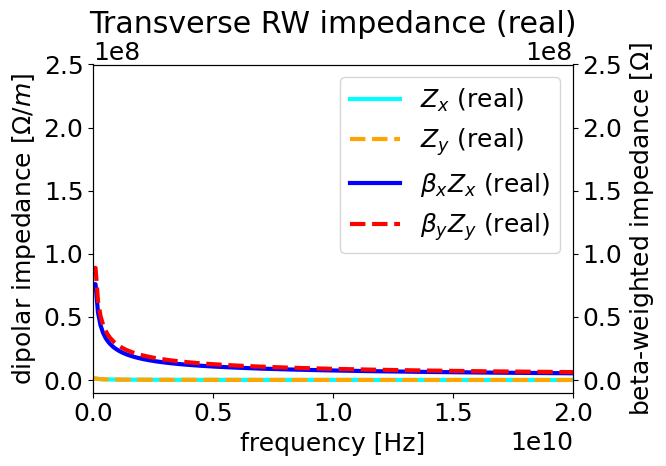

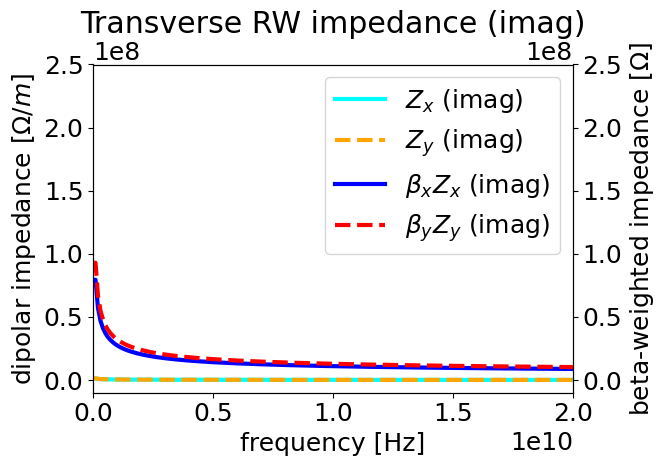

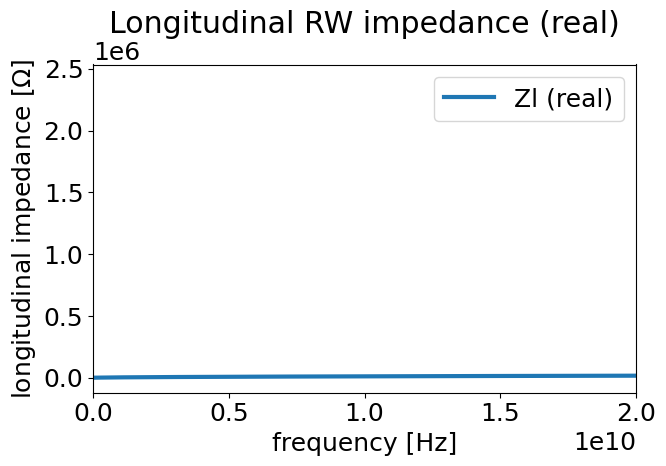

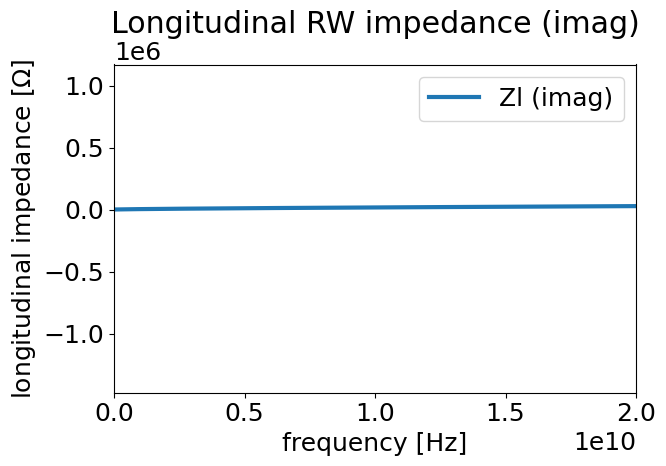

In [5]:
#%matplotlib ipympl

total_model = model_iw2d #model_iw2d.elements[0]

# Machine parameters
L = model_iw2d.circ # IW2D length already set L = 1.0

# Smooth beta (reference only)
print(f"Smooth beta:")
print(f"  beta_x_smooth = {model_iw2d.beta_x_smooth} m")
print(f"  beta_y_smooth = {model_iw2d.beta_y_smooth} m")

# Lattice average beta
print(f"\nLattice average beta:")
print(f"  <beta_x> = {model_iw2d.beta_x_avg} m")
print(f"  <beta_y> = {model_iw2d.beta_y_avg} m")

# Ratio (very important)
print(f"\nRatio (lattice / smooth):")
print(f"  beta_x ratio = {model_iw2d.beta_x_avg / model_iw2d.beta_x_smooth}")
print(f"  beta_y ratio = {model_iw2d.beta_y_avg / model_iw2d.beta_y_smooth}")

# Element statistics
bx = model_iw2d.beta_xs
by = model_iw2d.beta_ys

print(f"\nElement beta statistics:")
print(f"  beta_x min/max = {min(bx)} / {max(bx)}")
print(f"  beta_y min/max = {min(by)} / {max(by)}")

# Element-by-element list
print(f"\nElement-by-element beta:")
for name, bx_i, by_i, L in zip(
    model_iw2d.element_names,
    model_iw2d.beta_xs,
    model_iw2d.beta_ys,
    model_iw2d.lengths
):
    print(f"{name}  L={L} m   betax={bx_i}   betay={by_i}")

# Global length check
print("\nLength check:")
print(f"  Total IW2D length = {sum(model_iw2d.lengths):.2f} m")
print(f"  Circumference     = {model_iw2d.circ:.2f} m")

# Impedance computation
fmin, fmax = 1e-1, 1e13
n_points = 10**3

freq_x = None
freq_y = None
freq_z = None

Zx_C = None
Zy_C = None
Zz_C = None

Zx_beta = None
Zy_beta = None

for elem in total_model.elements:

    # Components
    comp_x = elem.get_component('x1000')
    freq, Zx_elem = comp_x.impedance_to_array(
        n_points, fmin, fmax, precision_factor=0.1
    )

    comp_y = elem.get_component('y0100')
    _, Zy_elem = comp_y.impedance_to_array(
        n_points, fmin, fmax, precision_factor=0.1
    )

    comp_z = elem.get_component('z0000')
    _, Zz_elem = comp_z.impedance_to_array(
        n_points, fmin, fmax, precision_factor=0.1
    )

    # Initialize arrays
    if Zx_C is None:
        Zx_C = np.zeros_like(Zx_elem)
        Zy_C = np.zeros_like(Zy_elem)
        Zz_C = np.zeros_like(Zz_elem)

        Zx_beta = np.zeros_like(Zx_elem)
        Zy_beta = np.zeros_like(Zy_elem)

        freq_x = freq
        freq_y = freq
        freq_z = freq


    L_elem = getattr(elem, "length", 1.0)

    # Length-weighted impedance
    Zx_C += L * Zx_elem
    Zy_C += L * Zy_elem
    Zz_C += L * Zz_elem

    # Beta-weighted impedance
    Zx_beta += elem.beta_x * L * Zx_elem
    Zy_beta += elem.beta_y * L * Zy_elem


# =========================================================
# 3. SANITY CHECKS
# Compare beta weighting scale
ratio_x = np.max(np.abs(Zx_beta)) / np.max(np.abs(Zx_C))
ratio_y = np.max(np.abs(Zy_beta)) / np.max(np.abs(Zy_C))

print(f"Max ratio Zx_beta / Zx_C = {ratio_x}")
print(f"Max ratio Zy_beta / Zy_C = {ratio_y}")

print("\nExpected: ~ average beta")

# Optional: compare with lattice average
print(f"\nLattice <beta_x> = {model_iw2d.beta_x_avg}")
print(f"Lattice <beta_y> = {model_iw2d.beta_y_avg}")


# beta_x_avg = model_iw2d.beta_x_smooth
# beta_y_avg = model_iw2d.beta_y_smooth

# print(f"Circumference = {C} m")
# print(f"<beta_x> = {beta_x_avg} m")
# print(f"<beta_y> = {beta_y_avg} m")

# # RW impedance
# freq_x, Zx = total_model.get_component('x1000').impedance_to_array(
#     10**3, 1e-1, 1e13, precision_factor=0.1
# )

# freq_y, Zy = total_model.get_component('y0100').impedance_to_array(
#     10**3, 1e-1, 1e13, precision_factor=0.1
# )

# freq_z, Zz = total_model.get_component('z0000').impedance_to_array(
#     10**3, 1e-1, 1e13, precision_factor=0.1
# )total_model = model_iw2d.elements[0]

# # Apply length contributions
# Zx_C = C * Zx
# Zy_C = C * Zy
# Zz_C = C * Zz

# # APPLY BETA (transverse only)
# Zx_beta = beta_x_avg * Zx_C
# Zy_beta = beta_y_avg * Zy_C


# Plot settings
plt.close('all')

parent_dir = os.getcwd()
folder_path = os.path.join(parent_dir, 'Plots')
os.makedirs(folder_path, exist_ok=True)

fntsz = 18
mpl.rcParams.update({
    'font.size': fntsz,
    'xtick.labelsize': fntsz,
    'ytick.labelsize': fntsz
})

# Transverse (real)
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(freq_x, Zx_C.real, '-', color='cyan', linewidth=3, label=r'$Z_x$ (real)')
ax1.plot(freq_y, Zy_C.real, '--', color='orange', linewidth=3, label=r'$Z_y$ (real)')
ax1.set_xlabel('frequency [Hz]')
ax1.set_ylabel(r'dipolar impedance [$\Omega/m$]')
ax1.set_xlim(0, 2e10)
ax1.set_ylim(-0.1e8, 2.5e8)
ax2 = ax1.twinx()
ax2.plot(freq_x, Zx_beta.real, '-', color='blue', linewidth=3, label=r'$\beta_x Z_x$ (real)')
ax2.plot(freq_y, Zy_beta.real, '--', color='red', linewidth=3, label=r'$\beta_y Z_y$ (real)')
ax2.set_ylim(-0.1e8, 2.5e8)
ax2.set_ylabel(r'beta-weighted impedance [$\Omega$]')
plt.title(r'Transverse RW impedance (real)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
plt.tight_layout()
plt.show()

# Transverse (imag)
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(freq_x, Zx_C.imag, '-', color='cyan', linewidth=3, label=r'$Z_x$ (imag)')
ax1.plot(freq_y, Zy_C.imag, '--', color='orange', linewidth=3, label=r'$Z_y$ (imag)')
ax1.set_xlabel('frequency [Hz]')
ax1.set_ylabel(r'dipolar impedance [$\Omega/m$]')
ax1.set_xlim(0, 2e10)
ax1.set_ylim(-0.1e8, 2.5e8)
ax2 = ax1.twinx()
ax2.plot(freq_x, Zx_beta.imag, '-', color='blue', linewidth=3, label=r'$\beta_x Z_x$ (imag)')
ax2.plot(freq_y, Zy_beta.imag, '--', color='red', linewidth=3, label=r'$\beta_y Z_y$ (imag)')
ax2.set_ylim(-0.1e8, 2.5e8)
ax2.set_ylabel(r'beta-weighted impedance [$\Omega$]')
plt.title(r'Transverse RW impedance (imag)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
plt.tight_layout()
plt.show()

# Longitudinal (real)
plt.figure(figsize=(7,5))
plt.plot(freq_z, Zz_C.real, '-', linewidth=3, label='Zl (real)')
plt.title(r'Longitudinal RW impedance (real)')
plt.xlabel('frequency [Hz]')
plt.ylabel(r'longitudinal impedance [$\Omega$]')
plt.legend()
plt.xlim(0, 2e10)
plt.tight_layout()
# plt.savefig(os.path.join(folder_path, 'Zlong_real.png'))
plt.show()

# Longitudinal (imag)
plt.figure(figsize=(7,5))
plt.plot(freq_z, Zz_C.imag, '-', linewidth=3, label='Zl (imag)')
plt.title(r'Longitudinal RW impedance (imag)')
plt.xlabel('frequency [Hz]')
plt.ylabel(r'longitudinal impedance [$\Omega$]')
plt.legend()
plt.xlim(0, 2e10)
plt.tight_layout()
# plt.savefig(os.path.join(folder_path, 'Zlong_imag.png'))
plt.show()


Circumference       = 90644.836000 m
Removed RW length   = 1500.000000 m
Effective RW length = 89144.836000 m
RW scaling factor   = 0.983452


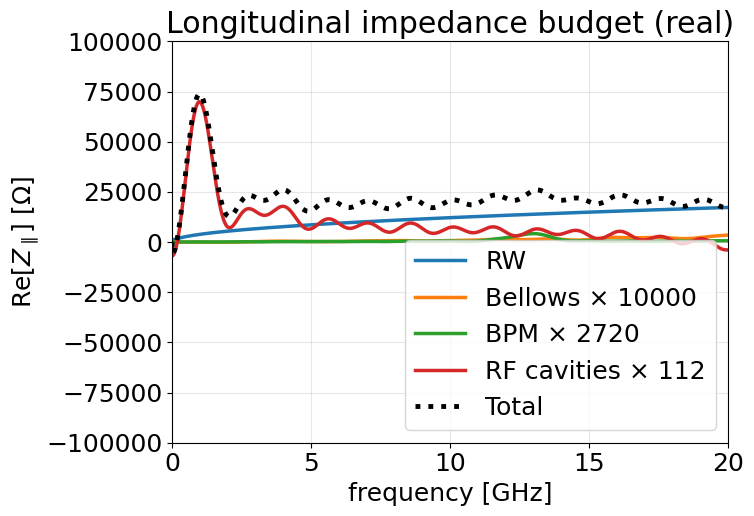

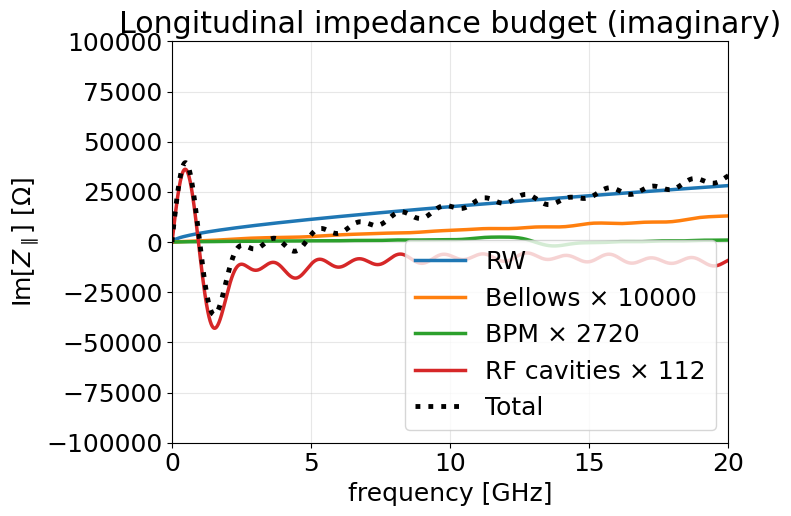


Component summary at 20 GHz:
RW (reduced) = (27648.004178647552+54595.04437447284j)
Bellows      = (24248.5+13621.23j)
BPM          = (1950.937952+246.70519679999998j)
RF cavities  = (-40935.6192+22209.8352j)
TOTAL        = (12911.822930647551+90672.81477127284j)


In [6]:
# =========================================================
# NEW CELL: Longitudinal impedance budget up to 20 GHz
# Uses:
#   - existing RW impedance already in memory: freq_z, Zz_C
#   - existing impedance files for RF / BPM / bellows
# No new impedance calculation here
#
# IMPORTANT:
#   Z_bellows_long.txt is already multiplied by 10000
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Check that RW result from previous cell exists
# ---------------------------------------------------------
if 'freq_z' not in globals() or 'Zz_C' not in globals():
    raise NameError(
        "freq_z and Zz_C are not defined. "
        "Please run your previous RW impedance cell first."
    )

if 'model_iw2d' not in globals():
    raise NameError(
        "model_iw2d is not defined. "
        "Please run the cell where HEBModel is built first."
    )

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"

# rf_file = os.path.join(repo_data, "rf_cavities", "Z_rf_cavity_long_iddefix.txt")
# rf_file = os.path.join(repo_data, "rf_cavities", "Z (sigma 3.5mm).txt")
# rf_file = os.path.join(repo_data, "rf_cavities", "Z_single_rf_cavity_long_10mm.txt")
# rf_file = os.path.join(repo_data, "rf_cavities", "Z_single_rf_cavity_long_3mm.txt")
rf_file = os.path.join(repo_data, "rf_cavities", "Z_single_rf_cavity_long_filter_3mm.txt")
bpm_file = os.path.join(repo_data, "bpm", "Z_bpm_long_3mm.txt")
bellows_file = os.path.join(repo_data, "bellows", "Z_bellows_long.txt")

# ---------------------------------------------------------
# Budget numbers
# ---------------------------------------------------------
n_rf = 112 #112 #28*4
n_bpm = 2720 #3344
n_bellows = 10000
L_bellows = 0.15   # [m] per bellows

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 50e9   # 20 GHz
n_interp = 5001

# ---------------------------------------------------------
# Helper: read impedance file
# format:
#   # Freq(GHz) Re(Z) Im(Z)
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# 1) RW impedance already computed in previous cell
#    freq_z : frequency array [Hz]
#    Zz_C   : full-ring RW longitudinal impedance
# ---------------------------------------------------------
freq_rw_full = np.array(freq_z)
Zrw_full_ring = np.array(Zz_C)

# Bellows already include their own RW, so remove that RW length
C_ring = model_iw2d.circ
L_remove = n_bellows * L_bellows
L_rw_effective = C_ring - L_remove

if L_rw_effective < 0:
    raise ValueError(
        f"Effective RW length became negative: C={C_ring}, removed={L_remove}"
    )

rw_scale = L_rw_effective / C_ring
Zrw_budget = rw_scale * Zrw_full_ring

print(f"Circumference       = {C_ring:.6f} m")
print(f"Removed RW length   = {L_remove:.6f} m")
print(f"Effective RW length = {L_rw_effective:.6f} m")
print(f"RW scaling factor   = {rw_scale:.6f}")

# ---------------------------------------------------------
# 2) Read already-prepared impedance files
# ---------------------------------------------------------
freq_rf, Zrf = read_impedance_file_ghz(rf_file)
freq_bpm, Zbpm = read_impedance_file_ghz(bpm_file)
freq_bell, Zbell = read_impedance_file_ghz(bellows_file)

# Cut-off for RF cavities
# RF_CUTOFF = 5.0e9
# Zrf = np.where(freq_rf <= RF_CUTOFF, Zrf, 0.0 + 0.0j)

# Multiply by number of components
Zrf_budget = n_rf * Zrf
Zbpm_budget = n_bpm * Zbpm

# IMPORTANT:
# bellows file is already multiplied by 10000
Zbell_budget = Zbell

# ---------------------------------------------------------
# 3) Interpolate to common grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Zrw_i   = interp_complex(freq_rw_full, Zrw_budget, f_common)
Zrf_i   = interp_complex(freq_rf, Zrf_budget, f_common)
Zbpm_i  = interp_complex(freq_bpm, Zbpm_budget, f_common)
Zbell_i = interp_complex(freq_bell, Zbell_budget, f_common)

Ztot = Zrw_i + Zrf_i + Zbpm_i + Zbell_i

# ---------------------------------------------------------
# 4) Plot real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Zrw_i.real,   linewidth=2.5, label='RW')
plt.plot(f_common/1e9, Zbell_i.real, linewidth=2.5, label='Bellows × 10000')
plt.plot(f_common/1e9, Zbpm_i.real,  linewidth=2.5, label='BPM × 2720')
plt.plot(f_common/1e9, Zrf_i.real,   linewidth=2.5, label='RF cavities × 112')
plt.plot(f_common/1e9, Ztot.real,  ":",  color='black', linewidth=3.5, label='Total')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_\parallel$] [$\Omega$]')
plt.title('Longitudinal impedance budget (real)')
plt.xlim(0, 20)
plt.ylim(-1e5, 1e5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) Plot imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Zrw_i.imag,   linewidth=2.5, label='RW')
plt.plot(f_common/1e9, Zbell_i.imag, linewidth=2.5, label='Bellows × 10000')
plt.plot(f_common/1e9, Zbpm_i.imag,  linewidth=2.5, label='BPM × 2720')
plt.plot(f_common/1e9, Zrf_i.imag,   linewidth=2.5, label='RF cavities × 112')
plt.plot(f_common/1e9, Ztot.imag,  ":",  color='black', linewidth=3.5, label='Total')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_\parallel$] [$\Omega$]')
plt.title('Longitudinal impedance budget (imaginary)')
plt.xlim(0, 20)
plt.ylim(-1e5, 1e5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6) Optional summary at 20 GHz
# ---------------------------------------------------------
print("\nComponent summary at 20 GHz:")
print(f"RW (reduced) = {Zrw_i[-1]}")
print(f"Bellows      = {Zbell_i[-1]}")
print(f"BPM          = {Zbpm_i[-1]}")
print(f"RF cavities  = {Zrf_i[-1]}")
print(f"TOTAL        = {Ztot[-1]}")

In [7]:
# =========================================================
# NEW CELL: Bellows verification
# Calculate 0.4 mm bunch wake potential from Z_bellows_long.txt
# and compare with existing bellows 0.4 mm CST wake data
#
# No saving of calculated bellows wake.
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
bellows_Z_file = os.path.join(
    repo_data,
    "bellows",
    "Z_bellows_long.txt"
)

bellows_folder = os.path.join(repo_data, "bellows")

bellows_W_candidates = [
    os.path.join(bellows_folder, "WakeLong_04mm.txt"),
    os.path.join(bellows_folder, "WakeLong_04mm"),
]

# bellows_W_candidates = [
#     os.path.join(bellows_folder, "W_bellows_long (sigma 0.4 mm).txt"),
#     os.path.join(bellows_folder, "W_bellows_long (sigma 0.4 mm)"),
# ]

bellows_W_file = None
for candidate in bellows_W_candidates:
    if os.path.exists(candidate):
        bellows_W_file = candidate
        break

if bellows_W_file is None:
    raise FileNotFoundError(
        "Could not find existing bellows 0.4 mm wake file. Tried:\n"
        + "\n".join(bellows_W_candidates)
    )

print(f"Using bellows impedance file:\n{bellows_Z_file}")
print(f"Using existing bellows wake file:\n{bellows_W_file}")


# ---------------------------------------------------------
# Reader for existing wake file
# ---------------------------------------------------------
def read_wake_file_any_header(filepath):
    """
    Read wake potential file with two columns:

        s [mm], W [V/pC]

    Header/comment lines starting with # are ignored.
    """
    data = np.loadtxt(filepath, comments="#")
    s_mm = data[:, 0]
    W_v_per_pC = data[:, 1] * 10000
    return s_mm, W_v_per_pC


# ---------------------------------------------------------
# Calculate bellows 0.4 mm wake from impedance
# ---------------------------------------------------------
sigma_z_mm_bellows = 0.4

f_bell, Z_bell = read_impedance_file_ghz(bellows_Z_file)

t_point_bell, W_point_bell, f_uniform_bell, Z_uniform_bell = calc_long_wake_from_long_Z(
    [f_bell, Z_bell],
    fmax_test=10000e9,
    n_freq=200001,
    verbose=True,
)

t_pad_bell, s_calc_bell_mm, W_calc_bell_v_per_pC, lambda_t_bell, W_point_pad_bell = (
    convolve_point_wake_with_gaussian(
        t_point=t_point_bell,
        W_point=W_point_bell,
        sigma_z_mm=sigma_z_mm_bellows,
    )
)


# ---------------------------------------------------------
# Read existing bellows 0.4 mm wake
# ---------------------------------------------------------
s_cst_bell_mm, W_cst_bell_v_per_pC = read_wake_file_any_header(bellows_W_file)


# ---------------------------------------------------------
# Interpolate calculated wake onto CST grid for difference
# ---------------------------------------------------------
W_calc_on_cst_bell = np.interp(
    s_cst_bell_mm,
    s_calc_bell_mm,
    W_calc_bell_v_per_pC,
    left=0.0,
    right=0.0,
)

diff_bell = W_calc_on_cst_bell - W_cst_bell_v_per_pC

print("\nBellows 0.4 mm verification:")
print(f"Existing wake range    = {s_cst_bell_mm[0]:.6f} mm to {s_cst_bell_mm[-1]:.6f} mm")
print(f"Calculated wake range  = {s_calc_bell_mm[0]:.6f} mm to {s_calc_bell_mm[-1]:.6f} mm")
print(f"Max abs difference     = {np.max(np.abs(diff_bell)):.6e} V/pC")
print(f"RMS difference         = {np.sqrt(np.mean(diff_bell**2)):.6e} V/pC")


# ---------------------------------------------------------
# Plot point-charge wake reconstructed from bellows impedance
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(t_point_bell * 1e9, W_point_bell, linewidth=2.5)
plt.xlabel("time [ns]")
plt.ylabel(r"$W_\parallel(t)$ [V/C]")
plt.title("Bellows: point-charge wake reconstructed from Re[Z]")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot existing vs calculated 0.4 mm bellows wake
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_cst_bell_mm,
    W_cst_bell_v_per_pC,
    linewidth=2.5,
    label="existing bellows wake, sigma = 0.4 mm",
)

plt.plot(
    s_calc_bell_mm,
    W_calc_bell_v_per_pC,
    "--",
    linewidth=2.0,
    label="calculated from Z_bellows_long.txt, sigma = 0.4 mm",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Bellows: 0.4 mm bunch wake verification")
plt.xlim(-10, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Near-origin zoom
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_cst_bell_mm,
    W_cst_bell_v_per_pC,
    linewidth=2.5,
    label="existing bellows wake",
)

plt.plot(
    s_calc_bell_mm,
    W_calc_bell_v_per_pC,
    "--",
    linewidth=2.0,
    label="calculated from impedance",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Bellows: 0.4 mm bunch wake verification, near-origin zoom")
plt.xlim(-5, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Difference plot on existing wake grid
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))
plt.plot(s_cst_bell_mm, diff_bell, linewidth=2.0)
plt.xlabel("s [mm]")
plt.ylabel("calculated - existing [V/pC]")
plt.title("Bellows: difference between calculated and existing 0.4 mm wake")
plt.xlim(-10, 200)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Store results for later use
# ---------------------------------------------------------
results_bellows_04mm_verification = {
    "f_bell": f_bell,
    "Z_bell": Z_bell,
    "f_uniform_bell": f_uniform_bell,
    "Z_uniform_bell": Z_uniform_bell,
    "t_point_bell": t_point_bell,
    "W_point_bell": W_point_bell,
    "s_calc_bell_mm": s_calc_bell_mm,
    "W_calc_bell_v_per_pC": W_calc_bell_v_per_pC,
    "s_cst_bell_mm": s_cst_bell_mm,
    "W_cst_bell_v_per_pC": W_cst_bell_v_per_pC,
    "W_calc_on_cst_bell": W_calc_on_cst_bell,
    "diff_bell": diff_bell,
}

Using bellows impedance file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_long.txt
Using existing bellows wake file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/WakeLong_04mm.txt


NameError: name 'calc_long_wake_from_long_Z' is not defined


RW longitudinal wake calculation from existing freq_z, Zz_C
* Existing Z -> point-charge wake
  Input frequency range = 1.000000e-10 GHz to 1.000000e+04 GHz
  Number of input samples = 1000
  Number of uniform frequency samples = 150001
  fmax = 100.000000 THz
  df = 666.662222 MHz
  Number of wake samples = 75001
  dt = 10.000000 fs
  ds = 0.002998 mm
  tmax = 0.750000 ns
  smax = 224.844343 mm
Saved point-charge wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/elliptic_elements/base_30mm/neg150nm/W_rw_long_point_charge.txt
Saved range: 0.000000 mm to 199.997545 mm
Number of saved samples: 66713
Saved 0.4 mm bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/elliptic_elements/base_30mm/neg150nm/W_rw_long (sigma 0.4 mm).txt
Saved range: -9.998078 mm to 199.997545 mm
Number of saved samples: 70048


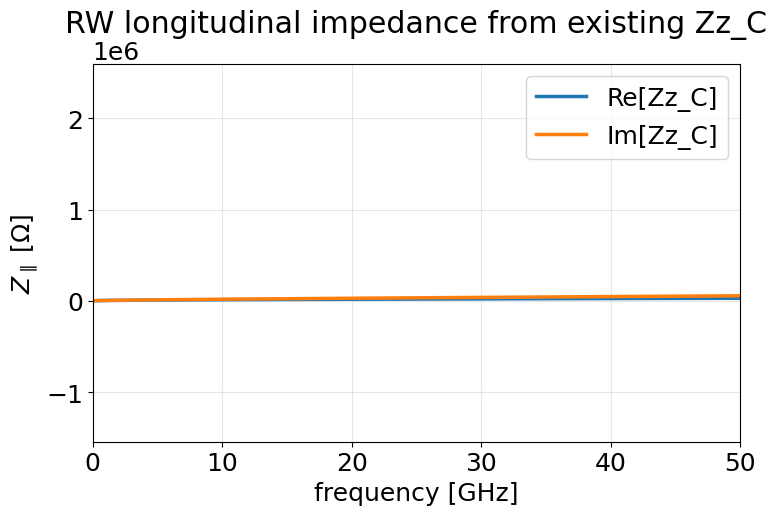

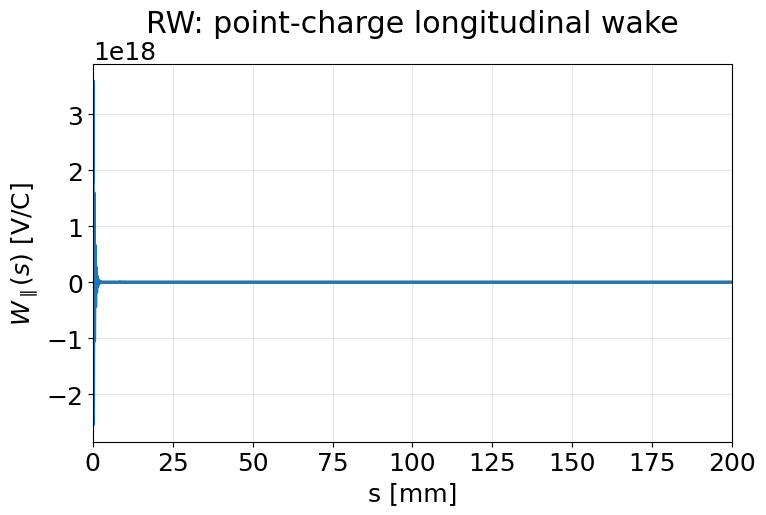

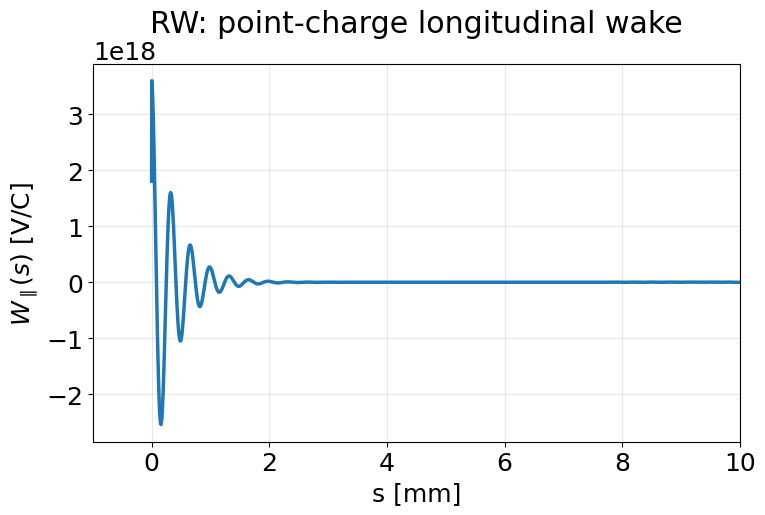

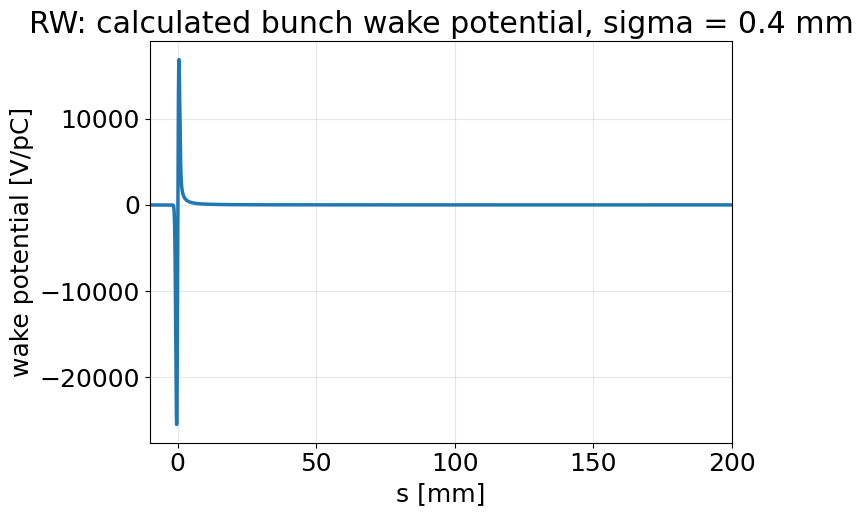

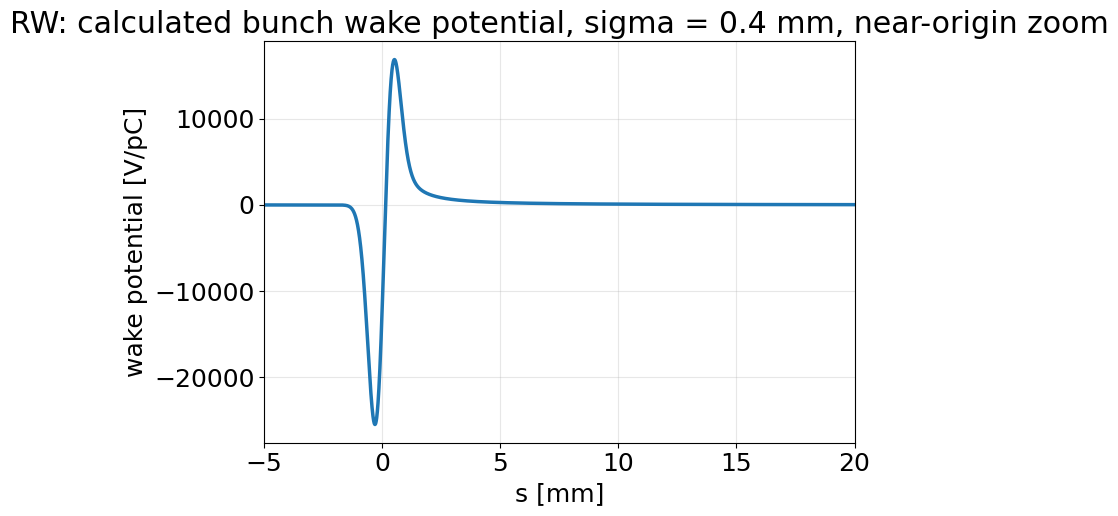

In [18]:
# =========================================================
# NEW CELL: Save longitudinal RW point-charge wake
# and 0.4 mm bunch wake potential
#
# Uses existing variables from previous IW2D cell:
#   freq_z : frequency array [Hz]
#   Zz_C   : longitudinal RW impedance [Ohm]
#
# Outputs:
#   elliptic_elements/base_30mm/neg150nm/W_rw_long_point_charge.txt
#   elliptic_elements/base_30mm/neg150nm/W_rw_long (sigma 0.4 mm).txt
#
# Longitudinal only.
# No file reading.
# No component-number multiplication.
#
# RW-specific setting:
#   fmax_test = 100 THz
#   n_freq    = 150001
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fft import ihfft
from scipy.signal import fftconvolve


# ---------------------------------------------------------
# Check existing RW impedance
# ---------------------------------------------------------
if "freq_z" not in globals() or "Zz_C" not in globals():
    raise NameError(
        "freq_z and Zz_C are not defined. "
        "Please run the IW2D RW impedance cell first."
    )

if "repo_data" not in globals():
    repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"


# ---------------------------------------------------------
# RW output folder and files
# ---------------------------------------------------------
rw_folder = os.path.join(
    repo_data,
    "elliptic_elements",
    "base_30mm",
    "neg150nm",
)

os.makedirs(rw_folder, exist_ok=True)

rw_point_output_file = os.path.join(
    rw_folder,
    "W_rw_long_point_charge.txt"
)

rw_bunch_output_file = os.path.join(
    rw_folder,
    "W_rw_long (sigma 0.4 mm).txt"
)


# ---------------------------------------------------------
# Complex interpolation
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re + 1j * im


# ---------------------------------------------------------
# Z -> point-charge wake
# Longitudinal wake reconstructed from Re[Z]
# ---------------------------------------------------------
def calc_long_wake_from_existing_Z(
    f_in,
    Z_in,
    fmax_test=100e12,
    n_freq=150001,
    verbose=True,
):
    """
    Calculate longitudinal point-charge wake from existing impedance arrays.

    Parameters
    ----------
    f_in : ndarray
        Frequency array [Hz].

    Z_in : ndarray
        Longitudinal impedance [Ohm].

    fmax_test : float
        Maximum frequency for inverse transform [Hz].

    n_freq : int
        Number of positive-frequency samples.

    Returns
    -------
    t : ndarray
        Time array [s], starting from 0.

    W : ndarray
        Point-charge wake [V/C].

    f_uniform : ndarray
        Uniform frequency grid [Hz].

    Z_uniform : ndarray
        Interpolated impedance [Ohm].
    """

    f_in = np.asarray(f_in)
    Z_in = np.asarray(Z_in)

    order = np.argsort(f_in)
    f_in = f_in[order]
    Z_in = Z_in[order]

    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)
    Z_uniform = interp_complex(f_in, Z_in, f_uniform)

    # Avoid artificial DC ambiguity
    Z_uniform[0] = 0.0 + 0.0j

    df = np.mean(np.diff(f_uniform))
    fmax = np.max(f_uniform)

    Nf = len(f_uniform)
    Nt = Nf // 2 + 1

    dt = 1.0 / fmax
    t = np.arange(Nt) * dt

    W = np.real(ihfft(Z_uniform.real, norm="forward")) * 4.0 * df
    W[[0, -1]] *= 0.5

    smax_mm = t[-1] * c * 1e3
    ds_mm = dt * c * 1e3

    if verbose:
        print("* Existing Z -> point-charge wake")
        print(f"  Input frequency range = {f_in[0]/1e9:.6e} GHz to {f_in[-1]/1e9:.6e} GHz")
        print(f"  Number of input samples = {len(f_in)}")
        print(f"  Number of uniform frequency samples = {Nf}")
        print(f"  fmax = {fmax / 1e12:.6f} THz")
        print(f"  df = {df / 1e6:.6f} MHz")
        print(f"  Number of wake samples = {Nt}")
        print(f"  dt = {dt * 1e15:.6f} fs")
        print(f"  ds = {ds_mm:.6f} mm")
        print(f"  tmax = {t[-1] * 1e9:.6f} ns")
        print(f"  smax = {smax_mm:.6f} mm")

    if smax_mm < 200.0:
        raise ValueError(
            f"smax = {smax_mm:.6f} mm is smaller than 200 mm. "
            "Increase n_freq."
        )

    return t, W, f_uniform, Z_uniform


# ---------------------------------------------------------
# Point-charge wake -> Gaussian bunch wake
# ---------------------------------------------------------
def convolve_point_wake_with_gaussian(
    t_point,
    W_point,
    sigma_z_mm=0.4,
):
    """
    Convolve point-charge wake with Gaussian bunch profile.

    Convention:
        WP_bunch(t) = - convolution[W_point(t), lambda(t)]

    Returns
    -------
    t_pad : ndarray
        Padded time grid [s].

    s_pad_mm : ndarray
        Padded distance grid [mm].

    WP_conv_v_per_pC : ndarray
        Bunch wake potential [V/pC].
    """

    sigma_t = sigma_z_mm * 1e-3 / c

    N = len(t_point)
    dt = np.mean(np.diff(t_point))

    # Symmetric time grid.
    # Index N - 1 corresponds to t = 0.
    t_pad = np.arange(-(N - 1), N) * dt

    W_point_pad = np.zeros_like(t_pad)
    W_point_pad[N - 1:] = W_point

    lambda_t = (
        1.0 / (sigma_t * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * (t_pad / sigma_t) ** 2)
    )

    WP_conv = -fftconvolve(W_point_pad, lambda_t, mode="same") * dt

    # V/C -> V/pC
    WP_conv_v_per_pC = WP_conv * 1e-12

    s_pad_mm = t_pad * c * 1e3

    return t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad


# ---------------------------------------------------------
# Save point-charge wake
# ---------------------------------------------------------
def save_point_charge_wake_file(
    output_file,
    t,
    W_v_per_C,
    s_min_save_mm=0.0,
    s_max_save_mm=200.0,
):
    """
    Save point-charge wake function.

    Columns:
        s [mm], W_parallel [V/C]
    """

    s_mm = t * c * 1e3

    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_C[mask]

    if len(s_save) == 0:
        raise ValueError("No point-charge wake data selected for saving.")

    with open(output_file, "w") as f:
        f.write("# Point-charge longitudinal RW wake function\n")
        f.write("# Source: existing freq_z, Zz_C from IW2D model\n")
        f.write('#"s / mm"\t"W_parallel [V/C]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved point-charge wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Save 0.4 mm bunch wake in CST-like format
# ---------------------------------------------------------
def save_cst_like_bunch_wake_file(
    output_file,
    s_mm,
    W_v_per_pC,
    sigma_z_mm=0.4,
    cpw=15,
    wakelength=200,
    xbeam=0,
    xtest=0,
    ybeam=0,
    ytest=0,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
):
    """
    Save bunch wake potential in CST-like text format.

    Columns:
        s [mm], W [V/pC]
    """

    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_pC[mask]

    if len(s_save) == 0:
        raise ValueError("No bunch wake data selected for saving.")

    with open(output_file, "w") as f:
        f.write(
            f"#Parameters = {{cpw={cpw}; sigma_z={sigma_z_mm}; "
            f"wakelength={wakelength}; xbeam={xbeam}; xtest={xtest}; "
            f"ybeam={ybeam}; ytest={ytest}}}\n"
        )
        f.write('#"s / mm"\t"Z [Real Part]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved 0.4 mm bunch wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Main RW longitudinal calculation from existing arrays
# ---------------------------------------------------------
def calculate_and_save_rw_from_existing_impedance(
    freq_z,
    Zz_C,
    point_output_file,
    bunch_output_file,
    sigma_z_mm=0.4,
    fmax_test=100e12,
    n_freq=150001,
    s_point_min_save_mm=0.0,
    s_point_max_save_mm=200.0,
    s_bunch_min_save_mm=-10.0,
    s_bunch_max_save_mm=200.0,
    xlim_point_mm=(0, 200),
    xlim_bunch_mm=(-10, 200),
):
    print("\n" + "=" * 80)
    print("RW longitudinal wake calculation from existing freq_z, Zz_C")
    print("=" * 80)

    t_point, W_point, f_uniform, Z_uniform = calc_long_wake_from_existing_Z(
        f_in=freq_z,
        Z_in=Zz_C,
        fmax_test=fmax_test,
        n_freq=n_freq,
        verbose=True,
    )

    save_point_charge_wake_file(
        output_file=point_output_file,
        t=t_point,
        W_v_per_C=W_point,
        s_min_save_mm=s_point_min_save_mm,
        s_max_save_mm=s_point_max_save_mm,
    )

    t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad = (
        convolve_point_wake_with_gaussian(
            t_point=t_point,
            W_point=W_point,
            sigma_z_mm=sigma_z_mm,
        )
    )

    save_cst_like_bunch_wake_file(
        output_file=bunch_output_file,
        s_mm=s_pad_mm,
        W_v_per_pC=WP_conv_v_per_pC,
        sigma_z_mm=sigma_z_mm,
        cpw=15,
        wakelength=200,
        s_min_save_mm=s_bunch_min_save_mm,
        s_max_save_mm=s_bunch_max_save_mm,
    )

    # -----------------------------------------------------
    # Plot input longitudinal RW impedance
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(
        np.asarray(freq_z) / 1e9,
        np.asarray(Zz_C).real,
        linewidth=2.5,
        label="Re[Zz_C]",
    )
    plt.plot(
        np.asarray(freq_z) / 1e9,
        np.asarray(Zz_C).imag,
        linewidth=2.5,
        label="Im[Zz_C]",
    )
    plt.xlabel("frequency [GHz]")
    plt.ylabel(r"$Z_\parallel$ [$\Omega$]")
    plt.title("RW longitudinal impedance from existing Zz_C")
    plt.xlim(0, 50)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot point-charge wake
    # -----------------------------------------------------
    s_point_mm = t_point * c * 1e3

    plt.figure(figsize=(8, 5.5))
    plt.plot(s_point_mm, W_point, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"$W_\parallel(s)$ [V/C]")
    plt.title("RW: point-charge longitudinal wake")
    plt.xlim(*xlim_point_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Zoom near origin
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_point_mm, W_point, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"$W_\parallel(s)$ [V/C]")
    plt.title("RW: point-charge longitudinal wake")
    plt.xlim(-1, 10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot 0.4 mm bunch wake
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, WP_conv_v_per_pC, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel("wake potential [V/pC]")
    plt.title(f"RW: calculated bunch wake potential, sigma = {sigma_z_mm} mm")
    plt.xlim(*xlim_bunch_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Zoom near origin
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, WP_conv_v_per_pC, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel("wake potential [V/pC]")
    plt.title(f"RW: calculated bunch wake potential, sigma = {sigma_z_mm} mm, near-origin zoom")
    plt.xlim(-5, 20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "point_output_file": point_output_file,
        "bunch_output_file": bunch_output_file,
        "f_uniform": f_uniform,
        "Z_uniform": Z_uniform,
        "t_point": t_point,
        "s_point_mm": s_point_mm,
        "W_point_v_per_C": W_point,
        "t_pad": t_pad,
        "s_bunch_mm": s_pad_mm,
        "W_bunch_v_per_pC": WP_conv_v_per_pC,
        "lambda_t": lambda_t,
        "W_point_pad": W_point_pad,
        "sigma_z_mm": sigma_z_mm,
    }


# ---------------------------------------------------------
# Run RW longitudinal calculation
# ---------------------------------------------------------
results_rw_04mm = calculate_and_save_rw_from_existing_impedance(
    freq_z=freq_z,
    Zz_C=Zz_C,
    point_output_file=rw_point_output_file,
    bunch_output_file=rw_bunch_output_file,
    sigma_z_mm=0.4,
    fmax_test=100e12,      # 100 THz for RW
    n_freq=150001,         # enough to save up to ~200 mm
    s_point_min_save_mm=0.0,
    s_point_max_save_mm=200.0,
    s_bunch_min_save_mm=-10.0,
    s_bunch_max_save_mm=200.0,
    xlim_point_mm=(0, 200),
    xlim_bunch_mm=(-10, 200),
)

RW length correction:
  Ring circumference       = 9.064483599995e+04 m
  Number of bellows        = 1
  Bellows length each      = 1.500000000000e-01 m
  Removed bellows length   = 1.500000000000e-01 m
  Effective RW length      = 9.064468599995e+04 m
  RW scale factor          = 9.999983451898e-01

Created corrected RW impedances:
  Zx_rw_budget = rw_scale * Zx_C
  Zy_rw_budget = rw_scale * Zy_C

RW transverse dipolar wake calculation from existing impedance, x-plane
Input convention:
  Zperp is used directly after RW length correction.
  No beta multiplication is applied here.
  No component-number multiplication is applied here.
  Zperp unit: Ohm/m
  W_point unit: V/C/m
  W_bunch unit: V/pC/m
* Existing transverse Z -> point-charge wake
  No beta multiplication is applied in this cell.
  No component-number multiplication is applied in this cell.
  Bellows length has already been subtracted from RW.
  Input frequency range = 1.000000e-10 GHz to 1.000000e+04 GHz
  Number of input sa

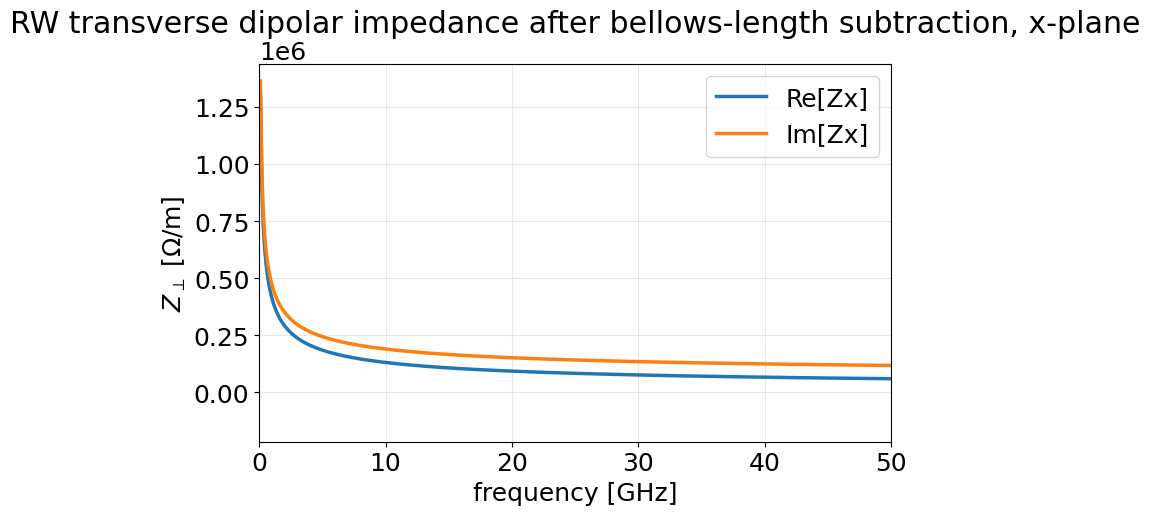

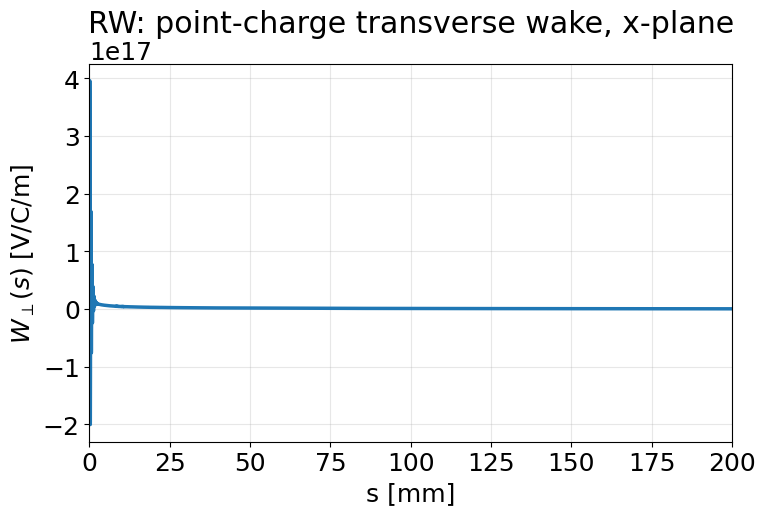

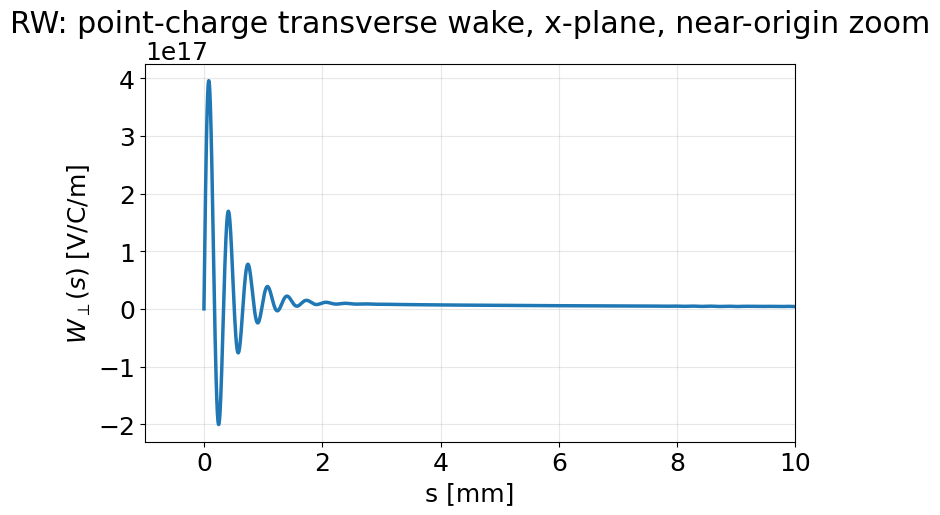

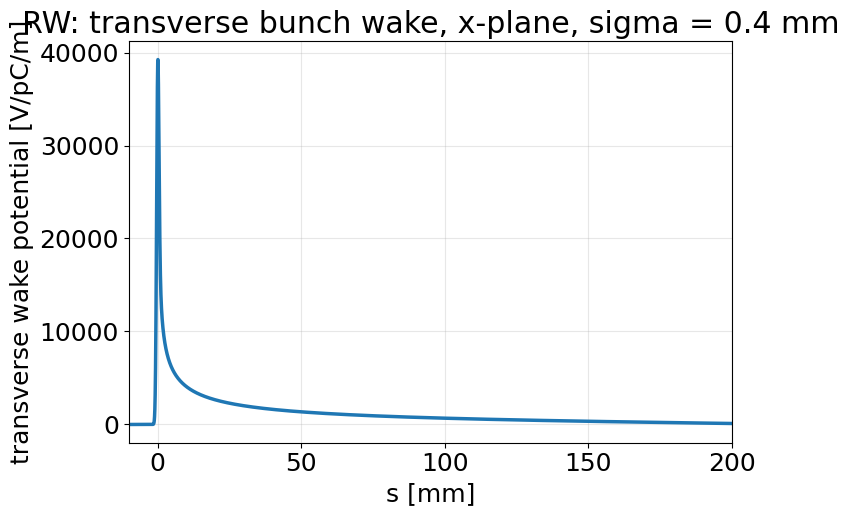

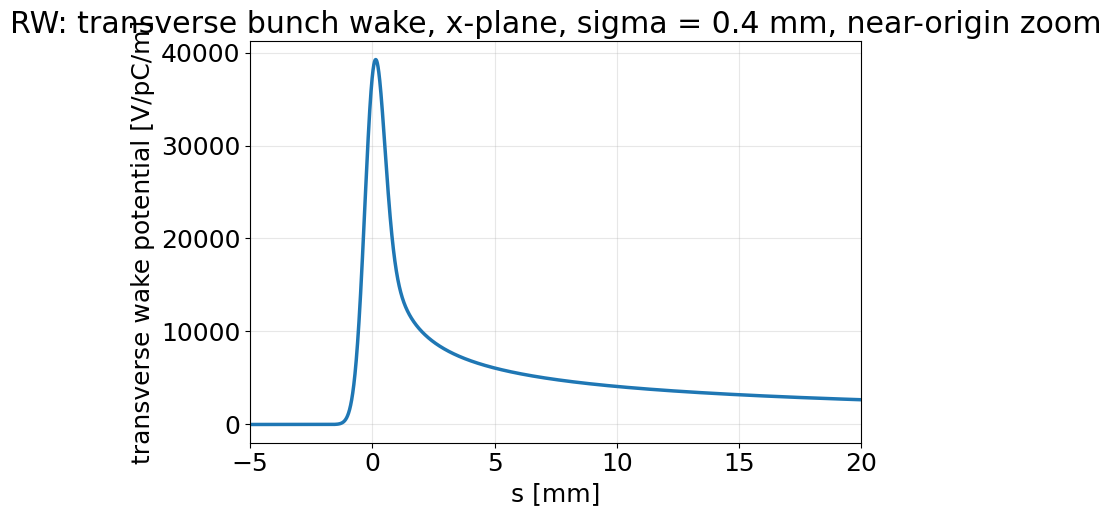


RW transverse dipolar wake calculation from existing impedance, y-plane
Input convention:
  Zperp is used directly after RW length correction.
  No beta multiplication is applied here.
  No component-number multiplication is applied here.
  Zperp unit: Ohm/m
  W_point unit: V/C/m
  W_bunch unit: V/pC/m
* Existing transverse Z -> point-charge wake
  No beta multiplication is applied in this cell.
  No component-number multiplication is applied in this cell.
  Bellows length has already been subtracted from RW.
  Input frequency range = 1.000000e-10 GHz to 1.000000e+04 GHz
  Number of input samples = 1000
  Number of uniform frequency samples = 150001
  fmax = 100.000000 THz
  df = 666.662222 MHz
  Number of wake samples = 75001
  dt = 10.000000 fs
  ds = 0.002998 mm
  tmax = 0.750000 ns
  smax = 224.844343 mm
  Z unit = Ohm/m
  W unit = V/C/m
Saved transverse point-charge wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/elliptic_elements/ba

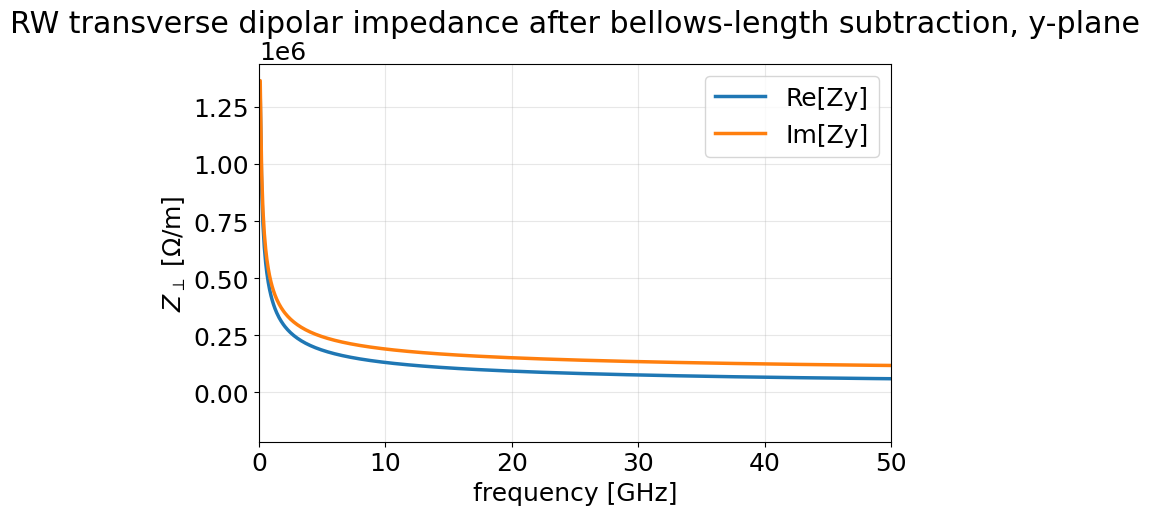

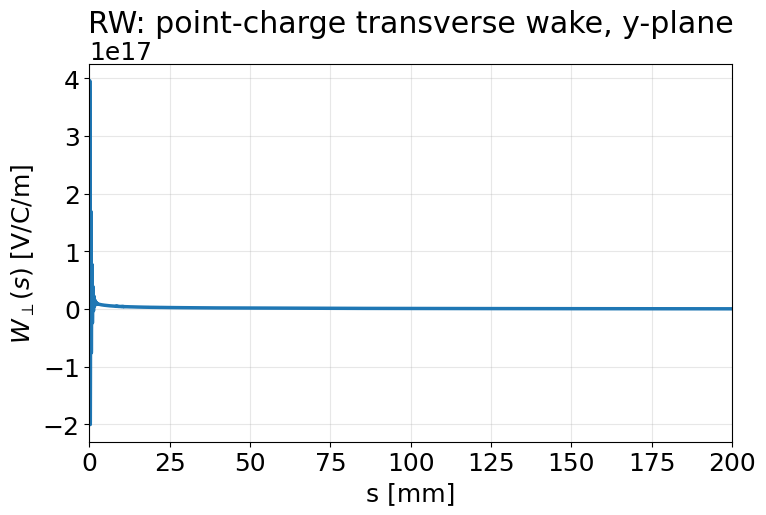

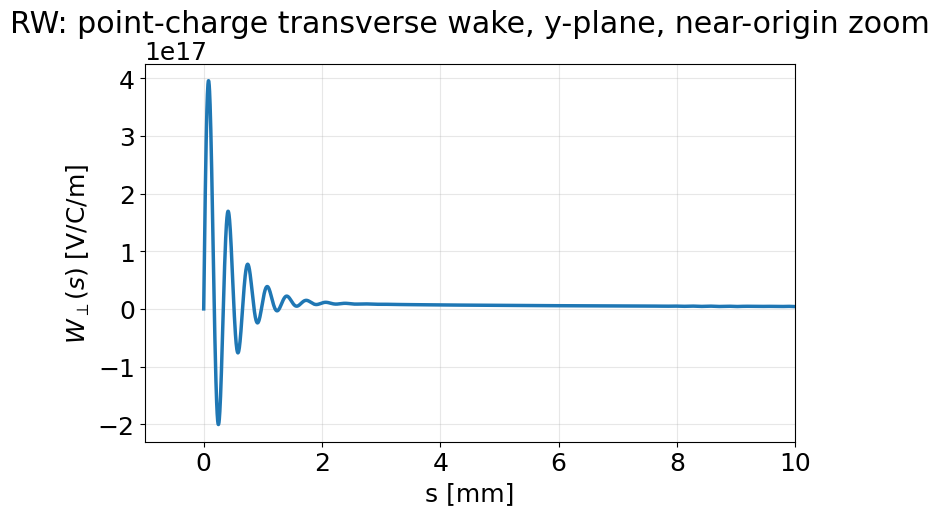

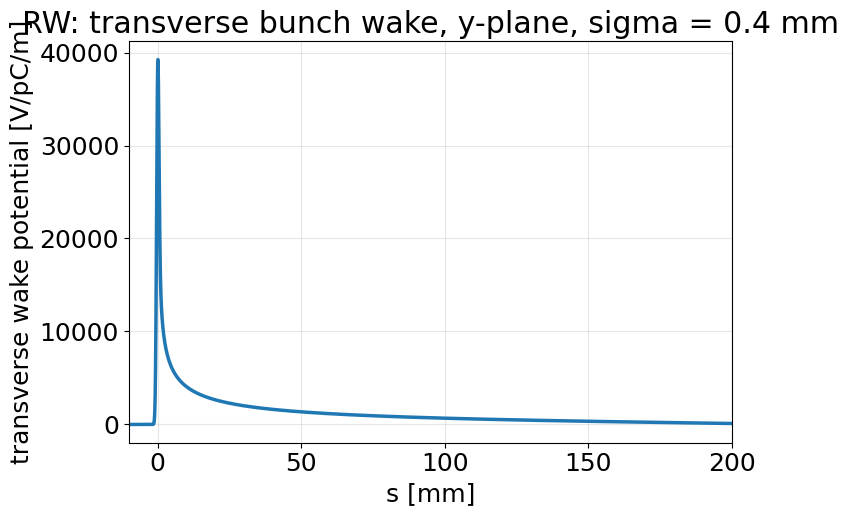

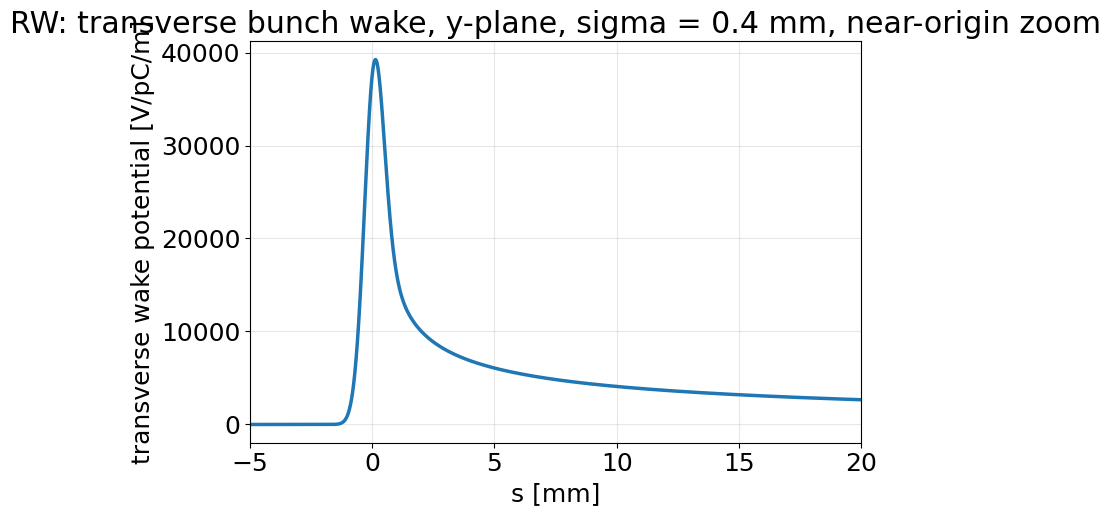

In [19]:
# =========================================================
# NEW CELL: Save transverse RW dipolar wakes
# with bellows-length subtraction
# and 0.4 mm bunch wake potentials
#
# Uses existing variables from previous IW2D cell:
#   freq_x : frequency array [Hz]
#   freq_y : frequency array [Hz]
#   Zx_C   : horizontal transverse RW dipolar impedance [Ohm/m]
#   Zy_C   : vertical transverse RW dipolar impedance [Ohm/m]
#
# Also required:
#   model_iw2d.circ : full ring circumference [m]
#   n_bellows       : number of bellows
#   L_bellows       : length of one bellows [m]
#
# IMPORTANT:
#   Bellows impedance already includes its own RW contribution.
#   Therefore, the smooth-pipe RW length is reduced by:
#
#       L_remove = n_bellows * L_bellows
#
#   and
#
#       Zx_rw_budget = (C_ring - L_remove) / C_ring * Zx_C
#       Zy_rw_budget = (C_ring - L_remove) / C_ring * Zy_C
#
# No beta multiplication is applied here.
# No component-number multiplication is applied here.
#
# Outputs:
#   elliptic_elements/base_30mm/neg150nm/W_rw_x_dipole_point_charge.txt
#   elliptic_elements/base_30mm/neg150nm/W_rw_y_dipole_point_charge.txt
#   elliptic_elements/base_30mm/neg150nm/W_rw_x_dipole (sigma 0.4 mm).txt
#   elliptic_elements/base_30mm/neg150nm/W_rw_y_dipole (sigma 0.4 mm).txt
#
# Units:
#   Z_perp  : [Ohm/m]
#   W_point : [V/C/m]
#   W_bunch : [V/pC/m]
#
# RW-specific setting:
#   fmax_test = 100 THz
#   n_freq    = 150001
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fft import ihfft
from scipy.signal import fftconvolve


# ---------------------------------------------------------
# Check existing transverse RW impedance
# ---------------------------------------------------------
required_vars = ["freq_x", "freq_y", "Zx_C", "Zy_C", "model_iw2d"]

for var in required_vars:
    if var not in globals():
        raise NameError(
            f"{var} is not defined. "
            "Please run the IW2D RW impedance cell first."
        )

if "n_bellows" not in globals():
    raise NameError(
        "n_bellows is not defined. "
        "Please define the number of bellows before running this cell."
    )

if "L_bellows" not in globals():
    raise NameError(
        "L_bellows is not defined. "
        "Please define the length of one bellows in meters before running this cell."
    )

if "repo_data" not in globals():
    repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"


# ---------------------------------------------------------
# RW length correction due to bellows
# ---------------------------------------------------------
C_ring = model_iw2d.circ

L_remove = n_bellows * L_bellows
L_rw_effective = C_ring - L_remove

if L_rw_effective < 0:
    raise ValueError(
        f"Effective RW length became negative:\n"
        f"  C_ring   = {C_ring:.12e} m\n"
        f"  L_remove = {L_remove:.12e} m\n"
        f"  L_eff    = {L_rw_effective:.12e} m"
    )

rw_scale = L_rw_effective / C_ring

print("RW length correction:")
print(f"  Ring circumference       = {C_ring:.12e} m")
print(f"  Number of bellows        = {n_bellows}")
print(f"  Bellows length each      = {L_bellows:.12e} m")
print(f"  Removed bellows length   = {L_remove:.12e} m")
print(f"  Effective RW length      = {L_rw_effective:.12e} m")
print(f"  RW scale factor          = {rw_scale:.12e}")

# Apply correction
Zx_rw_budget = rw_scale * np.array(Zx_C, dtype=complex)
Zy_rw_budget = rw_scale * np.array(Zy_C, dtype=complex)

print()
print("Created corrected RW impedances:")
print("  Zx_rw_budget = rw_scale * Zx_C")
print("  Zy_rw_budget = rw_scale * Zy_C")


# ---------------------------------------------------------
# RW output folder and files
# ---------------------------------------------------------
rw_folder = os.path.join(
    repo_data,
    "elliptic_elements",
    "base_30mm",
    "neg150nm",
)

os.makedirs(rw_folder, exist_ok=True)

rw_x_point_output_file = os.path.join(
    rw_folder,
    "W_rw_x_dipole_point_charge.txt"
)

rw_y_point_output_file = os.path.join(
    rw_folder,
    "W_rw_y_dipole_point_charge.txt"
)

rw_x_bunch_output_file = os.path.join(
    rw_folder,
    "W_rw_x_dipole (sigma 0.4 mm).txt"
)

rw_y_bunch_output_file = os.path.join(
    rw_folder,
    "W_rw_y_dipole (sigma 0.4 mm).txt"
)


# ---------------------------------------------------------
# Complex interpolation
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re + 1j * im


# ---------------------------------------------------------
# Z_perp -> transverse point-charge wake
#
# Input:
#   Z_perp [Ohm/m]
#
# Output:
#   W_perp [V/C/m]
#
# Convention:
#   W_perp = imag(ihfft(Re[Z_perp])) * 4 * df
# ---------------------------------------------------------
def calc_transverse_wake_from_existing_Z(
    f_in,
    Z_in,
    fmax_test=100e12,
    n_freq=150001,
    verbose=True,
):
    """
    Calculate transverse dipolar point-charge wake
    from existing transverse impedance arrays.

    Parameters
    ----------
    f_in : ndarray
        Frequency array [Hz].

    Z_in : ndarray
        Transverse dipolar impedance [Ohm/m].

    fmax_test : float
        Maximum frequency for inverse transform [Hz].

    n_freq : int
        Number of positive-frequency samples.

    Returns
    -------
    t : ndarray
        Time array [s], starting from 0.

    W : ndarray
        Transverse point-charge wake [V/C/m].

    f_uniform : ndarray
        Uniform frequency grid [Hz].

    Z_uniform : ndarray
        Interpolated impedance [Ohm/m].
    """

    f_in = np.asarray(f_in)
    Z_in = np.asarray(Z_in)

    order = np.argsort(f_in)
    f_in = f_in[order]
    Z_in = Z_in[order]

    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)
    Z_uniform = interp_complex(f_in, Z_in, f_uniform)

    # Avoid artificial DC ambiguity
    Z_uniform[0] = 0.0 + 0.0j

    df = np.mean(np.diff(f_uniform))
    fmax = np.max(f_uniform)

    Nf = len(f_uniform)
    Nt = Nf // 2 + 1

    dt = 1.0 / fmax
    t = np.arange(Nt) * dt

    # Transverse convention
    W = np.imag(ihfft(Z_uniform.real, norm="forward")) * 4.0 * df

    # Half-weight at boundaries
    W[[0, -1]] *= 0.5

    smax_mm = t[-1] * c * 1e3
    ds_mm = dt * c * 1e3

    if verbose:
        print("* Existing transverse Z -> point-charge wake")
        print("  No beta multiplication is applied in this cell.")
        print("  No component-number multiplication is applied in this cell.")
        print("  Bellows length has already been subtracted from RW.")
        print(f"  Input frequency range = {f_in[0]/1e9:.6e} GHz to {f_in[-1]/1e9:.6e} GHz")
        print(f"  Number of input samples = {len(f_in)}")
        print(f"  Number of uniform frequency samples = {Nf}")
        print(f"  fmax = {fmax / 1e12:.6f} THz")
        print(f"  df = {df / 1e6:.6f} MHz")
        print(f"  Number of wake samples = {Nt}")
        print(f"  dt = {dt * 1e15:.6f} fs")
        print(f"  ds = {ds_mm:.6f} mm")
        print(f"  tmax = {t[-1] * 1e9:.6f} ns")
        print(f"  smax = {smax_mm:.6f} mm")
        print("  Z unit = Ohm/m")
        print("  W unit = V/C/m")

    if smax_mm < 200.0:
        raise ValueError(
            f"smax = {smax_mm:.6f} mm is smaller than 200 mm. "
            "Increase n_freq."
        )

    return t, W, f_uniform, Z_uniform


# ---------------------------------------------------------
# Point-charge transverse wake -> Gaussian bunch wake
# ---------------------------------------------------------
def convolve_point_wake_with_gaussian(
    t_point,
    W_point,
    sigma_z_mm=0.4,
    convolution_sign=+1.0,
):
    """
    Convolve transverse point-charge wake with Gaussian bunch profile.

    Input:
        W_point [V/C/m]

    Output:
        WP_conv_v_per_pC_per_m [V/pC/m]

    Convention:
        WP_bunch(t) = convolution_sign * convolution[W_point(t), lambda(t)]

    If the final sign is opposite to your convention/CST convention,
    change convolution_sign to -1.
    """

    sigma_t = sigma_z_mm * 1e-3 / c

    N = len(t_point)
    dt = np.mean(np.diff(t_point))

    # Symmetric time grid.
    # Index N - 1 corresponds to t = 0.
    t_pad = np.arange(-(N - 1), N) * dt

    W_point_pad = np.zeros_like(t_pad)
    W_point_pad[N - 1:] = W_point

    lambda_t = (
        1.0 / (sigma_t * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * (t_pad / sigma_t) ** 2)
    )

    WP_conv = convolution_sign * fftconvolve(
        W_point_pad,
        lambda_t,
        mode="same",
    ) * dt

    # V/C/m -> V/pC/m
    WP_conv_v_per_pC_per_m = WP_conv * 1e-12

    s_pad_mm = t_pad * c * 1e3

    return t_pad, s_pad_mm, WP_conv_v_per_pC_per_m, lambda_t, W_point_pad


# ---------------------------------------------------------
# Save transverse point-charge wake
# ---------------------------------------------------------
def save_transverse_point_charge_wake_file(
    output_file,
    t,
    W_v_per_C_per_m,
    plane_label="x",
    s_min_save_mm=0.0,
    s_max_save_mm=200.0,
):
    """
    Save transverse point-charge wake function.

    Columns:
        s [mm], W_perp [V/C/m]
    """

    s_mm = t * c * 1e3

    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_C_per_m[mask]

    if len(s_save) == 0:
        raise ValueError("No point-charge wake data selected for saving.")

    with open(output_file, "w") as f:
        f.write(f"# Point-charge transverse RW dipolar wake, {plane_label}-plane\n")
        f.write("# Source: existing freq_x/freq_y and Zx_C/Zy_C from IW2D model\n")
        f.write("# Bellows length has been subtracted from the RW impedance.\n")
        f.write("# No beta multiplication is applied in this cell.\n")
        f.write("# Z_perp unit: Ohm/m\n")
        f.write('#"s / mm"\t"W_perp [V/C/m]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved transverse point-charge wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Save 0.4 mm transverse bunch wake
# ---------------------------------------------------------
def save_transverse_bunch_wake_file(
    output_file,
    s_mm,
    W_v_per_pC_per_m,
    plane_label="x",
    sigma_z_mm=0.4,
    cpw=15,
    wakelength=200,
    xbeam=0,
    xtest=0,
    ybeam=0,
    ytest=0,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
):
    """
    Save transverse bunch wake potential.

    Columns:
        s [mm], W_perp [V/pC/m]
    """

    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_pC_per_m[mask]

    if len(s_save) == 0:
        raise ValueError("No bunch wake data selected for saving.")

    with open(output_file, "w") as f:
        f.write(
            f"#Parameters = {{cpw={cpw}; sigma_z={sigma_z_mm}; "
            f"wakelength={wakelength}; xbeam={xbeam}; xtest={xtest}; "
            f"ybeam={ybeam}; ytest={ytest}}}\n"
        )
        f.write(f"# Transverse RW dipolar bunch wake, {plane_label}-plane\n")
        f.write("# Bellows length has been subtracted from the RW impedance.\n")
        f.write("# No beta multiplication is applied in this cell.\n")
        f.write("# Z_perp unit: Ohm/m\n")
        f.write('#"s / mm"\t"W_perp [V/pC/m]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved transverse 0.4 mm bunch wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Main transverse calculation for one plane
# ---------------------------------------------------------
def calculate_and_save_transverse_rw_from_existing_impedance(
    plane_label,
    freq,
    Zperp,
    point_output_file,
    bunch_output_file,
    sigma_z_mm=0.4,
    fmax_test=100e12,
    n_freq=150001,
    convolution_sign=+1.0,
    s_point_min_save_mm=0.0,
    s_point_max_save_mm=200.0,
    s_bunch_min_save_mm=-10.0,
    s_bunch_max_save_mm=200.0,
    xlim_point_mm=(0, 200),
    xlim_bunch_mm=(-10, 200),
):
    print("\n" + "=" * 80)
    print(f"RW transverse dipolar wake calculation from existing impedance, {plane_label}-plane")
    print("=" * 80)
    print("Input convention:")
    print("  Zperp is used directly after RW length correction.")
    print("  No beta multiplication is applied here.")
    print("  No component-number multiplication is applied here.")
    print("  Zperp unit: Ohm/m")
    print("  W_point unit: V/C/m")
    print("  W_bunch unit: V/pC/m")

    t_point, W_point, f_uniform, Z_uniform = calc_transverse_wake_from_existing_Z(
        f_in=freq,
        Z_in=Zperp,
        fmax_test=fmax_test,
        n_freq=n_freq,
        verbose=True,
    )

    save_transverse_point_charge_wake_file(
        output_file=point_output_file,
        t=t_point,
        W_v_per_C_per_m=W_point,
        plane_label=plane_label,
        s_min_save_mm=s_point_min_save_mm,
        s_max_save_mm=s_point_max_save_mm,
    )

    t_pad, s_pad_mm, W_bunch_v_per_pC_per_m, lambda_t, W_point_pad = (
        convolve_point_wake_with_gaussian(
            t_point=t_point,
            W_point=W_point,
            sigma_z_mm=sigma_z_mm,
            convolution_sign=convolution_sign,
        )
    )

    save_transverse_bunch_wake_file(
        output_file=bunch_output_file,
        s_mm=s_pad_mm,
        W_v_per_pC_per_m=W_bunch_v_per_pC_per_m,
        plane_label=plane_label,
        sigma_z_mm=sigma_z_mm,
        cpw=15,
        wakelength=200,
        s_min_save_mm=s_bunch_min_save_mm,
        s_max_save_mm=s_bunch_max_save_mm,
    )

    # -----------------------------------------------------
    # Plot input transverse impedance
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(
        np.asarray(freq) / 1e9,
        np.asarray(Zperp).real,
        linewidth=2.5,
        label=f"Re[Z{plane_label}]",
    )
    plt.plot(
        np.asarray(freq) / 1e9,
        np.asarray(Zperp).imag,
        linewidth=2.5,
        label=f"Im[Z{plane_label}]",
    )
    plt.xlabel("frequency [GHz]")
    plt.ylabel(r"$Z_\perp$ [$\Omega$/m]")
    plt.title(f"RW transverse dipolar impedance after bellows-length subtraction, {plane_label}-plane")
    plt.xlim(0, 50)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot point-charge wake
    # -----------------------------------------------------
    s_point_mm = t_point * c * 1e3

    plt.figure(figsize=(8, 5.5))
    plt.plot(s_point_mm, W_point, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"$W_\perp(s)$ [V/C/m]")
    plt.title(f"RW: point-charge transverse wake, {plane_label}-plane")
    plt.xlim(*xlim_point_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Zoom near origin
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_point_mm, W_point, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"$W_\perp(s)$ [V/C/m]")
    plt.title(f"RW: point-charge transverse wake, {plane_label}-plane, near-origin zoom")
    plt.xlim(-1, 10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot 0.4 mm bunch wake
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, W_bunch_v_per_pC_per_m, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"transverse wake potential [V/pC/m]")
    plt.title(
        f"RW: transverse bunch wake, "
        f"{plane_label}-plane, sigma = {sigma_z_mm} mm"
    )
    plt.xlim(*xlim_bunch_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Zoom near origin
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, W_bunch_v_per_pC_per_m, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"transverse wake potential [V/pC/m]")
    plt.title(
        f"RW: transverse bunch wake, "
        f"{plane_label}-plane, sigma = {sigma_z_mm} mm, near-origin zoom"
    )
    plt.xlim(-5, 20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "plane_label": plane_label,
        "point_output_file": point_output_file,
        "bunch_output_file": bunch_output_file,
        "rw_scale": rw_scale,
        "L_rw_effective": L_rw_effective,
        "L_remove": L_remove,
        "f_uniform": f_uniform,
        "Z_uniform": Z_uniform,
        "t_point": t_point,
        "s_point_mm": s_point_mm,
        "W_point_v_per_C_per_m": W_point,
        "t_pad": t_pad,
        "s_bunch_mm": s_pad_mm,
        "W_bunch_v_per_pC_per_m": W_bunch_v_per_pC_per_m,

        # Compatibility aliases for later total-budget scripts
        "W_point_v_per_C": W_point,
        "W_bunch_v_per_pC": W_bunch_v_per_pC_per_m,

        "lambda_t": lambda_t,
        "W_point_pad": W_point_pad,
        "sigma_z_mm": sigma_z_mm,
        "unit_point": "V/C/m",
        "unit_bunch": "V/pC/m",
    }


# ---------------------------------------------------------
# Run x- and y-plane transverse RW calculation
# ---------------------------------------------------------
results_rw_x_dipole_04mm = calculate_and_save_transverse_rw_from_existing_impedance(
    plane_label="x",
    freq=freq_x,
    Zperp=Zx_rw_budget,
    point_output_file=rw_x_point_output_file,
    bunch_output_file=rw_x_bunch_output_file,
    sigma_z_mm=0.4,
    fmax_test=100e12,
    n_freq=150001,
    convolution_sign=+1.0,
    s_point_min_save_mm=0.0,
    s_point_max_save_mm=200.0,
    s_bunch_min_save_mm=-10.0,
    s_bunch_max_save_mm=200.0,
    xlim_point_mm=(0, 200),
    xlim_bunch_mm=(-10, 200),
)

results_rw_y_dipole_04mm = calculate_and_save_transverse_rw_from_existing_impedance(
    plane_label="y",
    freq=freq_y,
    Zperp=Zy_rw_budget,
    point_output_file=rw_y_point_output_file,
    bunch_output_file=rw_y_bunch_output_file,
    sigma_z_mm=0.4,
    fmax_test=100e12,
    n_freq=150001,
    convolution_sign=+1.0,
    s_point_min_save_mm=0.0,
    s_point_max_save_mm=200.0,
    s_bunch_min_save_mm=-10.0,
    s_bunch_max_save_mm=200.0,
    xlim_point_mm=(0, 200),
    xlim_bunch_mm=(-10, 200),
)


RF cavity: calculating 0.4 mm bunch wake
Input impedance file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/Z_single_rf_cavity_long_filter_3mm.txt
* Z -> point-charge wake
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
Saved wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/W_single_rf_cavity_long_filter (sigma 0.4 mm).txt
Saved range: -9.983089 mm to 199.991549 mm
Number of saved samples: 7005


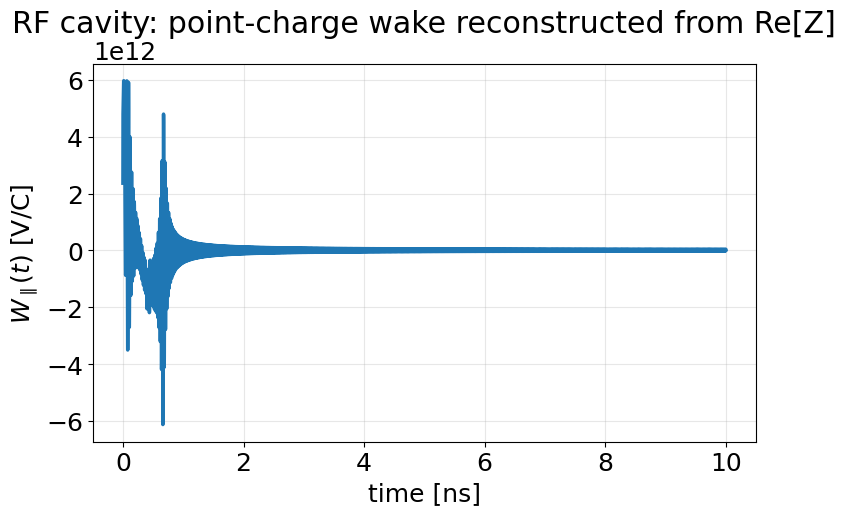

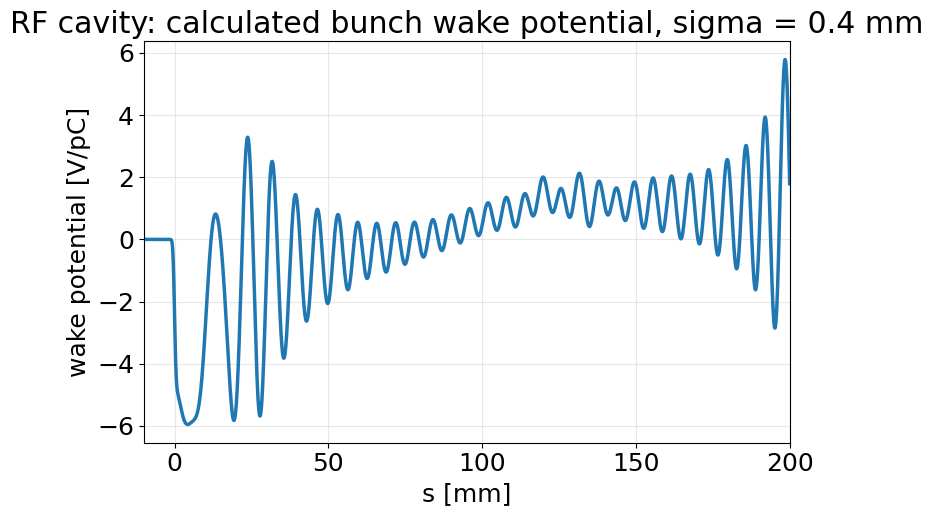


BPM: calculating 0.4 mm bunch wake
Input impedance file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/Z_bpm_long_3mm.txt
* Z -> point-charge wake
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
Saved wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/W_bpm_long (sigma 0.4 mm).txt
Saved range: -9.983089 mm to 199.991549 mm
Number of saved samples: 7005


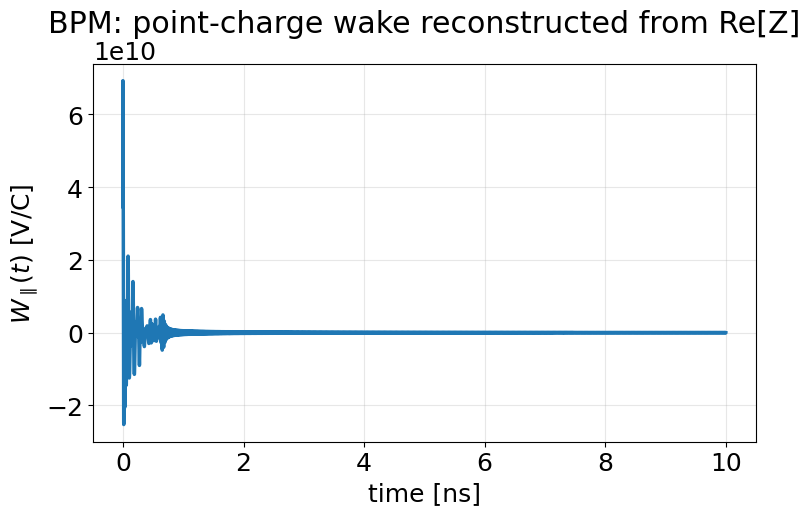

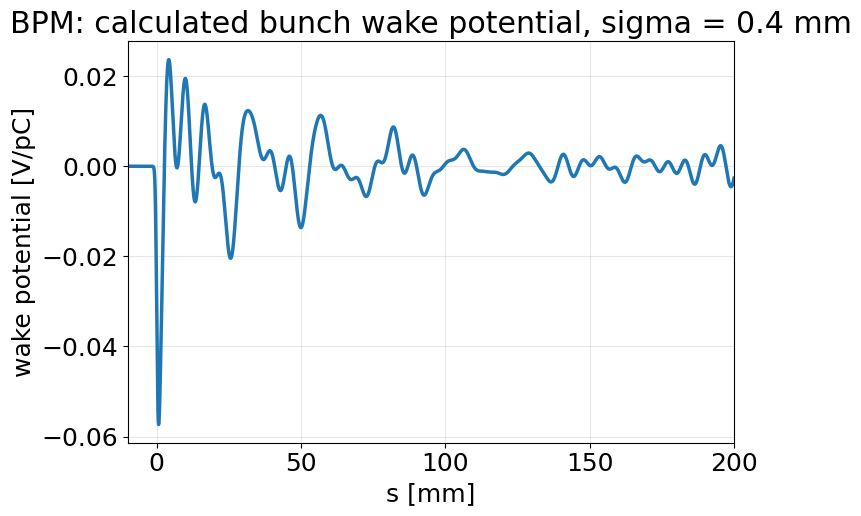


Bellows: calculating 0.4 mm bunch wake
Input impedance file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_long.txt
* Z -> point-charge wake
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
Saved wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/W_bellows_long (sigma 0.4 mm).txt
Saved range: -9.983089 mm to 199.991549 mm
Number of saved samples: 7005


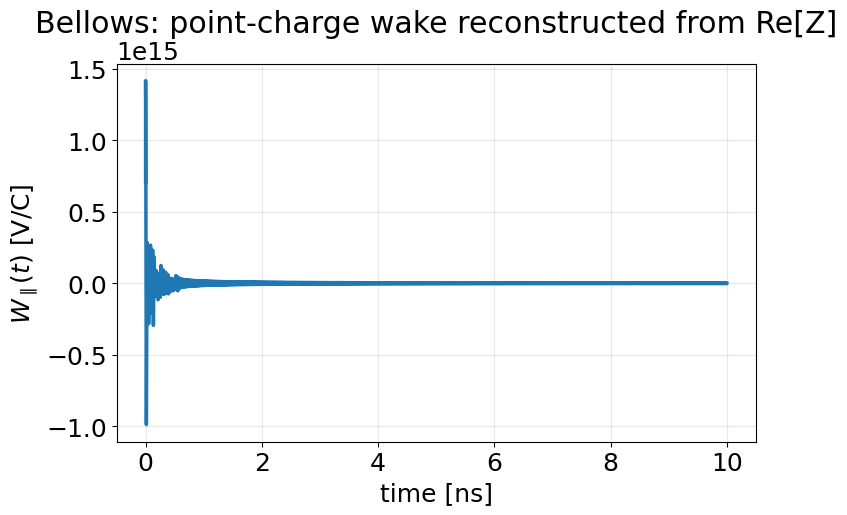

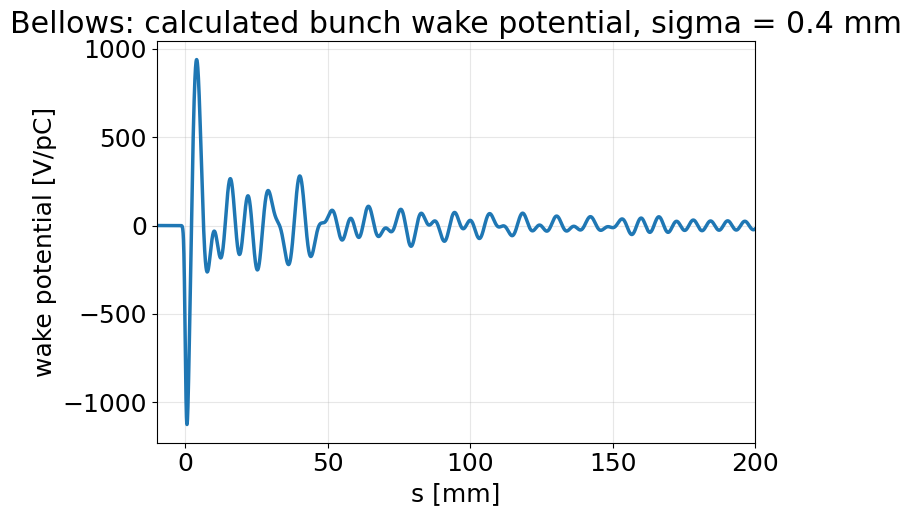

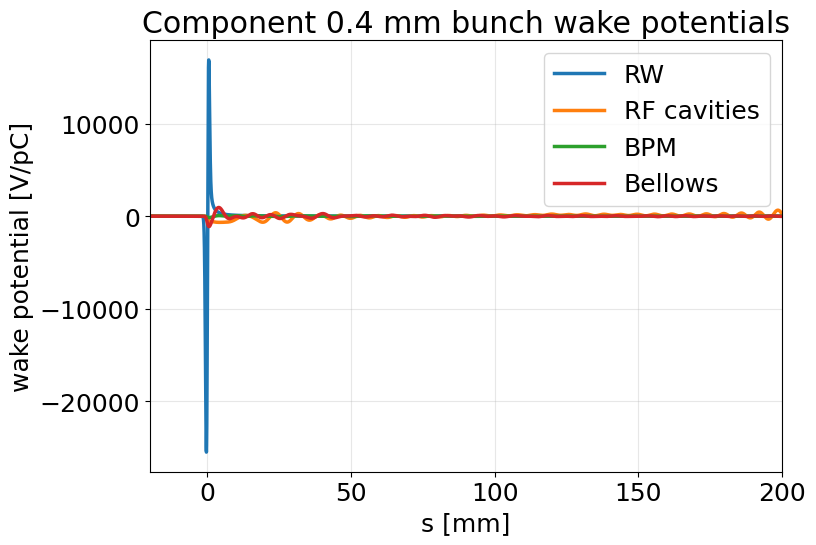

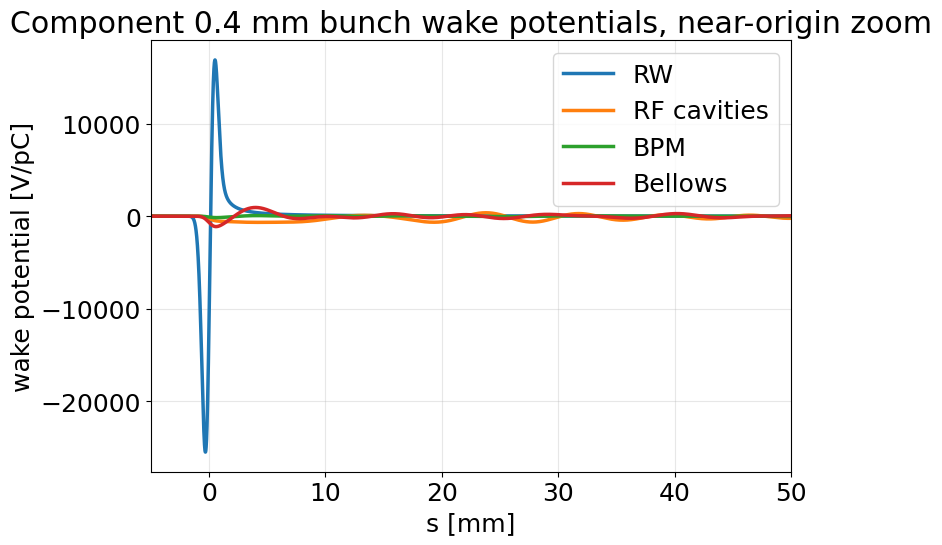

Saved total 0.4 mm wake potential to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/total/W_total_long (sigma 0.4 mm).txt
Saved range: -10.000000 mm to 200.000000 mm
Number of saved samples: 7001


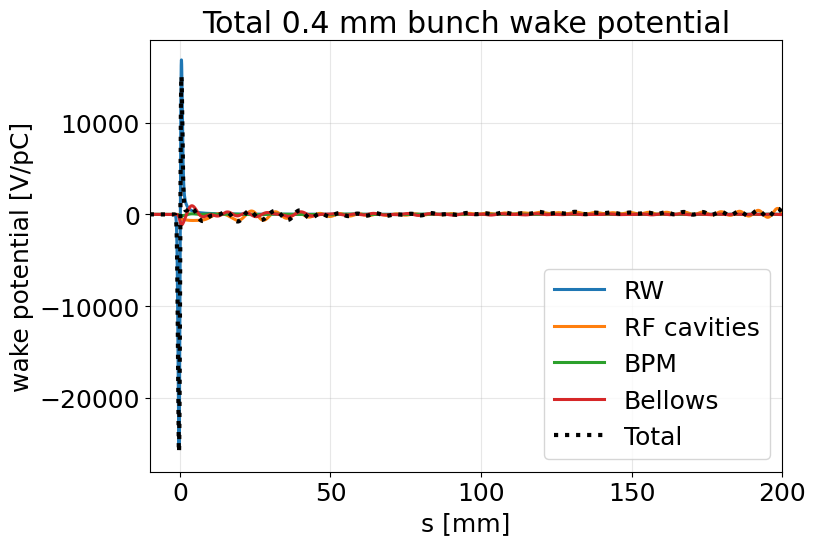

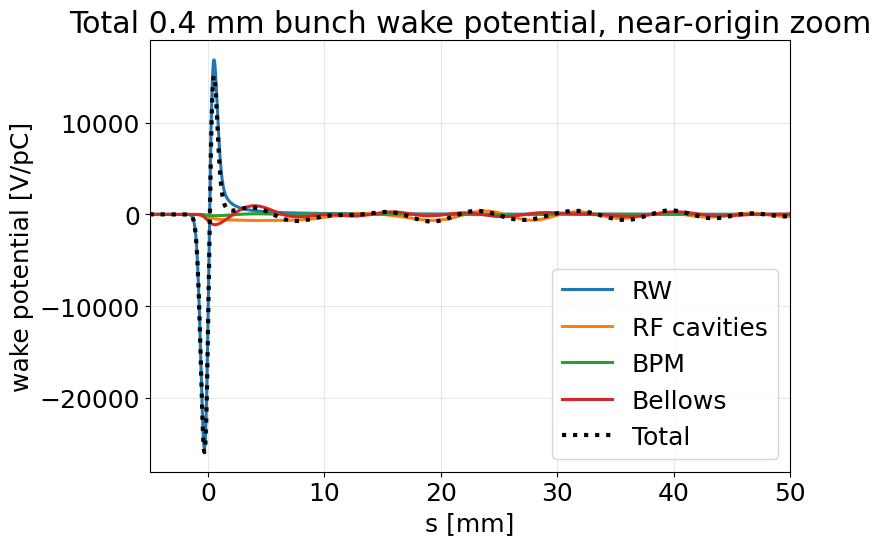

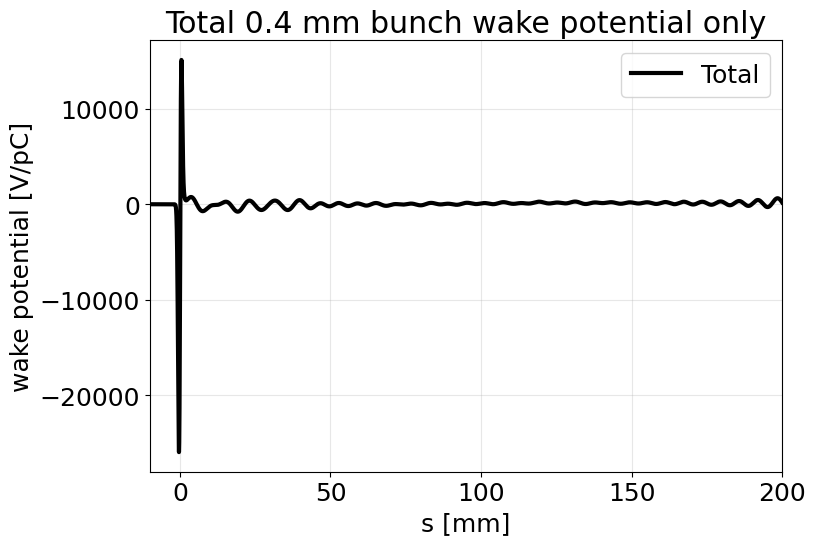

In [20]:
# =========================================================
# NEW CELL: Calculate 0.4 mm RF/BPM/Bellows wakes,
# combine with already-calculated RW wake,
# overplot all components, and save total wake
#
# Inputs:
#   RF:
#     Z_single_rf_cavity_long_filter_3mm.txt
#
#   BPM:
#     Z_bpm_long_3mm.txt
#
#   Bellows:
#     Z_bellows_long.txt
#
# Already required:
#   results_rw_04mm
#
# Outputs:
#   RF:
#     W_single_rf_cavity_long_filter (sigma 0.4 mm).txt
#
#   BPM:
#     W_bpm_long (sigma 0.4 mm).txt
#
#   Bellows:
#     W_bellows_long (sigma 0.4 mm).txt
#
#   Total:
#     total/W_total_long (sigma 0.4 mm).txt
#
# Notes:
#   No RW convolution is performed here.
#   RW is taken from results_rw_04mm.
#   RF and BPM are multiplied internally for the total.
#   Bellows file is assumed to already include the required multiplication.
#   Legend names do not show component numbers.
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fft import ihfft
from scipy.signal import fftconvolve


# ---------------------------------------------------------
# Check required RW result
# ---------------------------------------------------------
if "results_rw_04mm" not in globals():
    raise NameError(
        "results_rw_04mm is not defined. "
        "Please run the RW 0.4 mm wake calculation first."
    )


# ---------------------------------------------------------
# Base data folder
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"


# ---------------------------------------------------------
# Component numbers for total wake
# ---------------------------------------------------------
n_rf = 112
n_bpm = 2720
n_bellows = 1   # bellows number is already included in W_bellows_long (sigma 0.4 mm).txt


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
rf_Z_file = os.path.join(
    repo_data,
    "rf_cavities",
    "Z_single_rf_cavity_long_filter_3mm.txt"
)

bpm_Z_file = os.path.join(
    repo_data,
    "bpm",
    "Z_bpm_long_3mm.txt"
)

bellows_Z_file = os.path.join(
    repo_data,
    "bellows",
    "Z_bellows_long.txt"
)

rf_output_file = os.path.join(
    repo_data,
    "rf_cavities",
    "W_single_rf_cavity_long_filter (sigma 0.4 mm).txt"
)

bpm_output_file = os.path.join(
    repo_data,
    "bpm",
    "W_bpm_long (sigma 0.4 mm).txt"
)

bellows_output_file = os.path.join(
    repo_data,
    "bellows",
    "W_bellows_long (sigma 0.4 mm).txt"
)

total_folder = os.path.join(repo_data, "total")
os.makedirs(total_folder, exist_ok=True)

total_wake_output_file = os.path.join(
    total_folder,
    "W_total_long (sigma 0.4 mm).txt"
)


# ---------------------------------------------------------
# Basic readers
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    """
    Read impedance file with format:

        # Freq(GHz) Re(Z) Im(Z)

    Returns
    -------
    f_hz : ndarray
        Frequency [Hz]

    Z : ndarray
        Complex impedance [Ohm]
    """

    data = np.loadtxt(filepath, comments="#")

    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]

    return f_hz, Z


def read_wake_file_any_header(filepath):
    """
    Read wake potential file with two columns:

        s [mm], W [V/pC]

    Header/comment lines starting with # are ignored.
    """

    data = np.loadtxt(filepath, comments="#")

    s_mm = data[:, 0]
    W_v_per_pC = data[:, 1]

    return s_mm, W_v_per_pC


def interp_complex(f_src, Z_src, f_dst):
    """
    Interpolate complex impedance.
    Values outside the original frequency range are set to zero.
    """

    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)

    return re + 1j * im


# ---------------------------------------------------------
# Z -> point-charge wake
# Same convention as previous working script.
# Longitudinal wake is reconstructed from Re[Z].
# ---------------------------------------------------------
def calc_long_wake_from_long_Z(
    impedance,
    f=None,
    fmax_test=10000e9,
    n_freq=200001,
    verbose=True,
):
    """
    Calculate longitudinal point-charge wake from longitudinal impedance.

    The input impedance can be available only up to 50 GHz.
    Above the input range, the impedance is zero-filled by interpolation.
    """

    if isinstance(impedance, list):
        f_in = np.asarray(impedance[0])
        Z_in = np.asarray(impedance[1])
    else:
        if f is None:
            raise AttributeError("Provide frequency array f.")
        f_in = np.asarray(f)
        Z_in = np.asarray(impedance)

    order = np.argsort(f_in)
    f_in = f_in[order]
    Z_in = Z_in[order]

    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)

    Z_uniform = interp_complex(f_in, Z_in, f_uniform)

    # Avoid artificial DC ambiguity
    Z_uniform[0] = 0.0 + 0.0j

    df = np.mean(np.diff(f_uniform))
    fmax = np.max(f_uniform)

    Nf = len(f_uniform)
    Nt = Nf // 2 + 1

    dt = 1.0 / fmax
    t = np.arange(Nt) * dt

    W = np.real(ihfft(Z_uniform.real, norm="forward")) * 4.0 * df

    # Half-weight at boundaries
    W[[0, -1]] *= 0.5

    if verbose:
        print("* Z -> point-charge wake")
        print(f"  Input frequency range = {f_in[0] / 1e9:.6f} GHz to {f_in[-1] / 1e9:.6f} GHz")
        print(f"  Number of input samples = {len(f_in)}")
        print(f"  Number of uniform frequency samples = {Nf}")
        print(f"  fmax = {fmax / 1e9:.6f} GHz")
        print(f"  df = {df / 1e6:.6f} MHz")
        print(f"  Number of wake samples = {Nt}")
        print(f"  dt = {dt * 1e12:.6f} ps")
        print(f"  ds = {dt * c * 1e3:.6f} mm")
        print(f"  tmax = {t[-1] * 1e9:.6f} ns")
        print(f"  smax = {t[-1] * c * 1e3:.6f} mm")

    return t, W, f_uniform, Z_uniform


# ---------------------------------------------------------
# Point-charge wake -> Gaussian bunch wake
# ---------------------------------------------------------
def convolve_point_wake_with_gaussian(
    t_point,
    W_point,
    sigma_z_mm=0.4,
):
    """
    Convolve point-charge wake with Gaussian bunch profile.

    Convention:
        WP_bunch(t) = - convolution[W_point(t), lambda(t)]

    Returns
    -------
    t_pad : ndarray
        Padded time grid [s]

    s_pad_mm : ndarray
        Padded distance grid [mm]

    WP_conv_v_per_pC : ndarray
        Bunch wake potential [V/pC]
    """

    sigma_t = sigma_z_mm * 1e-3 / c

    N = len(t_point)
    dt = np.mean(np.diff(t_point))

    # Symmetric time grid
    # index N - 1 corresponds to t = 0
    t_pad = np.arange(-(N - 1), N) * dt

    W_point_pad = np.zeros_like(t_pad)
    W_point_pad[N - 1:] = W_point

    lambda_t = (
        1.0 / (sigma_t * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * (t_pad / sigma_t) ** 2)
    )

    WP_conv = -fftconvolve(W_point_pad, lambda_t, mode="same") * dt

    # V/C -> V/pC
    WP_conv_v_per_pC = WP_conv * 1e-12

    s_pad_mm = t_pad * c * 1e3

    return t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad


# ---------------------------------------------------------
# Save CST-like bunch wake file
# ---------------------------------------------------------
def save_cst_like_wake_file(
    output_file,
    s_mm,
    W_v_per_pC,
    sigma_z_mm=0.4,
    cpw=15,
    wakelength=200,
    xbeam=0,
    xtest=0,
    ybeam=0,
    ytest=0,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
):
    """
    Save bunch wake potential in CST-like text format.
    """

    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_pC[mask]

    if len(s_save) == 0:
        raise ValueError(
            "No data points selected for saving. "
            "Check s_min_save_mm and s_max_save_mm."
        )

    with open(output_file, "w") as f:
        f.write(
            f"#Parameters = {{cpw={cpw}; sigma_z={sigma_z_mm}; "
            f"wakelength={wakelength}; xbeam={xbeam}; xtest={xtest}; "
            f"ybeam={ybeam}; ytest={ytest}}}\n"
        )
        f.write('#"s / mm"\t"Z [Real Part]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Calculate and save one component
# ---------------------------------------------------------
def calculate_and_save_04mm_wake(
    name,
    Z_file,
    output_file,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
    xlim_mm=(-10, 200),
):
    print("\n" + "=" * 80)
    print(f"{name}: calculating {sigma_z_mm} mm bunch wake")
    print("=" * 80)

    if not os.path.exists(Z_file):
        raise FileNotFoundError(f"Impedance file does not exist:\n{Z_file}")

    f_Z, Z = read_impedance_file_ghz(Z_file)

    print(f"Input impedance file:\n{Z_file}")

    t_point, W_point, f_uniform, Z_uniform = calc_long_wake_from_long_Z(
        [f_Z, Z],
        fmax_test=fmax_test,
        n_freq=n_freq,
        verbose=True,
    )

    t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad = (
        convolve_point_wake_with_gaussian(
            t_point=t_point,
            W_point=W_point,
            sigma_z_mm=sigma_z_mm,
        )
    )

    save_cst_like_wake_file(
        output_file=output_file,
        s_mm=s_pad_mm,
        W_v_per_pC=WP_conv_v_per_pC,
        sigma_z_mm=sigma_z_mm,
        cpw=15,
        wakelength=200,
        s_min_save_mm=s_min_save_mm,
        s_max_save_mm=s_max_save_mm,
    )

    # Point-charge wake plot
    plt.figure(figsize=(8, 5.5))
    plt.plot(t_point * 1e9, W_point, linewidth=2.5)
    plt.xlabel("time [ns]")
    plt.ylabel(r"$W_\parallel(t)$ [V/C]")
    plt.title(f"{name}: point-charge wake reconstructed from Re[Z]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 0.4 mm bunch wake plot
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, WP_conv_v_per_pC, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel("wake potential [V/pC]")
    plt.title(f"{name}: calculated bunch wake potential, sigma = {sigma_z_mm} mm")
    plt.xlim(*xlim_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "Z_file": Z_file,
        "output_file": output_file,
        "f_Z": f_Z,
        "Z": Z,
        "f_uniform": f_uniform,
        "Z_uniform": Z_uniform,
        "t_point": t_point,
        "W_point": W_point,
        "t_pad": t_pad,
        "s_pad_mm": s_pad_mm,
        "WP_conv_v_per_pC": WP_conv_v_per_pC,
        "lambda_t": lambda_t,
        "W_point_pad": W_point_pad,
        "sigma_z_mm": sigma_z_mm,
    }


# ---------------------------------------------------------
# Calculate RF, BPM, and Bellows 0.4 mm wakes
# ---------------------------------------------------------
results_rf_04mm = calculate_and_save_04mm_wake(
    name="RF cavity",
    Z_file=rf_Z_file,
    output_file=rf_output_file,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
    xlim_mm=(-10, 200),
)

results_bpm_04mm = calculate_and_save_04mm_wake(
    name="BPM",
    Z_file=bpm_Z_file,
    output_file=bpm_output_file,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
    xlim_mm=(-10, 200),
)

results_bellows_04mm = calculate_and_save_04mm_wake(
    name="Bellows",
    Z_file=bellows_Z_file,
    output_file=bellows_output_file,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
    xlim_mm=(-10, 200),
)


# =========================================================
# Combine RF/BPM/Bellows with already-calculated RW
# =========================================================

# ---------------------------------------------------------
# Get RF, BPM, Bellows wakes
# ---------------------------------------------------------
s_rf_mm = results_rf_04mm["s_pad_mm"]
W_rf_single_v_per_pC = results_rf_04mm["WP_conv_v_per_pC"]

s_bpm_mm = results_bpm_04mm["s_pad_mm"]
W_bpm_single_v_per_pC = results_bpm_04mm["WP_conv_v_per_pC"]

s_bell_mm = results_bellows_04mm["s_pad_mm"]
W_bell_single_v_per_pC = results_bellows_04mm["WP_conv_v_per_pC"]

# ---------------------------------------------------------
# Get already-calculated RW wake
# ---------------------------------------------------------
s_rw_mm = results_rw_04mm["s_bunch_mm"]
W_rw_total_v_per_pC = results_rw_04mm["W_bunch_v_per_pC"]


# ---------------------------------------------------------
# Apply component numbers internally
# ---------------------------------------------------------
W_rf_total_v_per_pC = n_rf * W_rf_single_v_per_pC
W_bpm_total_v_per_pC = n_bpm * W_bpm_single_v_per_pC
W_bell_total_v_per_pC = n_bellows * W_bell_single_v_per_pC


# ---------------------------------------------------------
# Plot component wakes
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(s_rw_mm, W_rw_total_v_per_pC, linewidth=2.5, label="RW")
plt.plot(s_rf_mm, W_rf_total_v_per_pC, linewidth=2.5, label="RF cavities")
plt.plot(s_bpm_mm, W_bpm_total_v_per_pC, linewidth=2.5, label="BPM")
plt.plot(s_bell_mm, W_bell_total_v_per_pC, linewidth=2.5, label="Bellows")

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Component 0.4 mm bunch wake potentials")
plt.xlim(-20, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot component wakes, near-origin zoom
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(s_rw_mm, W_rw_total_v_per_pC, linewidth=2.5, label="RW")
plt.plot(s_rf_mm, W_rf_total_v_per_pC, linewidth=2.5, label="RF cavities")
plt.plot(s_bpm_mm, W_bpm_total_v_per_pC, linewidth=2.5, label="BPM")
plt.plot(s_bell_mm, W_bell_total_v_per_pC, linewidth=2.5, label="Bellows")

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Component 0.4 mm bunch wake potentials, near-origin zoom")
plt.xlim(-5, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Interpolate all components to common s-grid and sum
# ---------------------------------------------------------
s_common_mm = np.linspace(-10.0, 200.0, 7001)

W_rw_i = np.interp(
    s_common_mm,
    s_rw_mm,
    W_rw_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_rf_i = np.interp(
    s_common_mm,
    s_rf_mm,
    W_rf_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_bpm_i = np.interp(
    s_common_mm,
    s_bpm_mm,
    W_bpm_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_bell_i = np.interp(
    s_common_mm,
    s_bell_mm,
    W_bell_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_total_i = W_rw_i + W_rf_i + W_bpm_i + W_bell_i


# ---------------------------------------------------------
# Save total 0.4 mm wake potential
# ---------------------------------------------------------
with open(total_wake_output_file, "w") as f:
    f.write(
        "#Parameters = {cpw=15; sigma_z=0.4; wakelength=200; "
        "xbeam=0; xtest=0; ybeam=0; ytest=0}\n"
    )
    f.write('#"s / mm"\t"Z [Real Part]"\n')
    f.write("#------------------------\n")

    for si, Wi in zip(s_common_mm, W_total_i):
        f.write(f"{si:.12f}\t{Wi:.13e}\n")

print(f"Saved total 0.4 mm wake potential to:\n{total_wake_output_file}")
print(f"Saved range: {s_common_mm[0]:.6f} mm to {s_common_mm[-1]:.6f} mm")
print(f"Number of saved samples: {len(s_common_mm)}")


# ---------------------------------------------------------
# Plot total wake potential with components
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(s_common_mm, W_rw_i, linewidth=2.2, label="RW")
plt.plot(s_common_mm, W_rf_i, linewidth=2.2, label="RF cavities")
plt.plot(s_common_mm, W_bpm_i, linewidth=2.2, label="BPM")
plt.plot(s_common_mm, W_bell_i, linewidth=2.2, label="Bellows")
plt.plot(s_common_mm, W_total_i, ":", color="black", linewidth=3.0, label="Total")

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Total 0.4 mm bunch wake potential")
plt.xlim(-10, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot total wake potential with components, near-origin zoom
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(s_common_mm, W_rw_i, linewidth=2.2, label="RW")
plt.plot(s_common_mm, W_rf_i, linewidth=2.2, label="RF cavities")
plt.plot(s_common_mm, W_bpm_i, linewidth=2.2, label="BPM")
plt.plot(s_common_mm, W_bell_i, linewidth=2.2, label="Bellows")
plt.plot(s_common_mm, W_total_i, ":", color="black", linewidth=3.0, label="Total")

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Total 0.4 mm bunch wake potential, near-origin zoom")
plt.xlim(-5, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Plot total only
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(s_common_mm, W_total_i, color="black", linewidth=3.0, label="Total")

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Total 0.4 mm bunch wake potential only")
plt.xlim(-10, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Store for later use
# ---------------------------------------------------------
wake_budget_04mm = {
    "s_common_mm": s_common_mm,
    "W_rw_total_v_per_pC": W_rw_i,
    "W_rf_total_v_per_pC": W_rf_i,
    "W_bpm_total_v_per_pC": W_bpm_i,
    "W_bell_total_v_per_pC": W_bell_i,
    "W_total_v_per_pC": W_total_i,
    "total_wake_output_file": total_wake_output_file,
}

Using bellows wake file:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/W_bellows_long (sigma 0.4 mm).txt


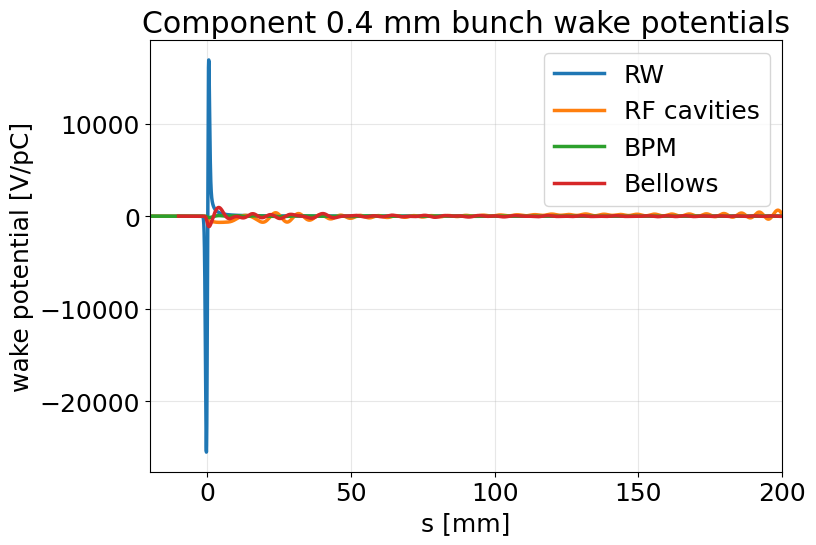

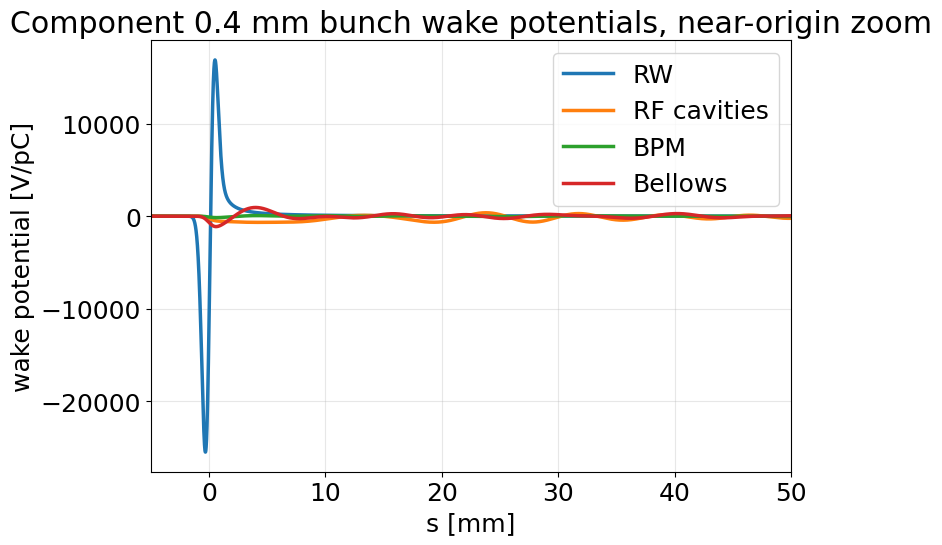

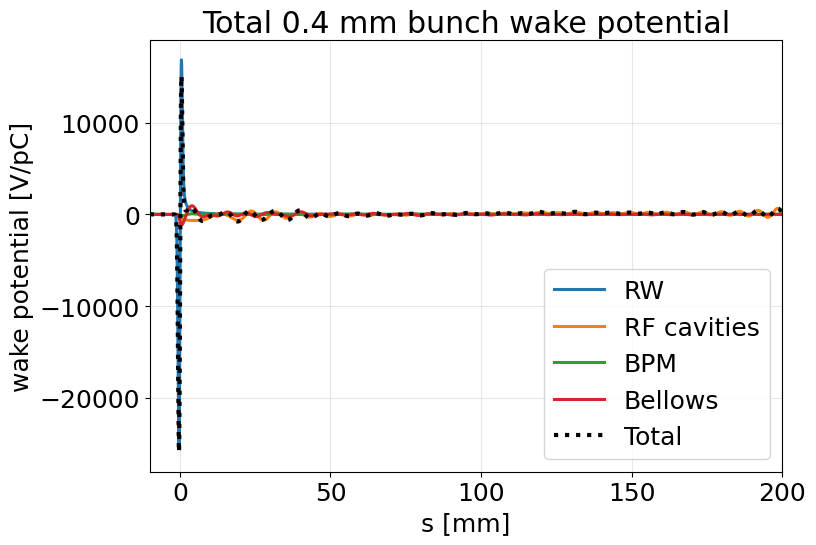

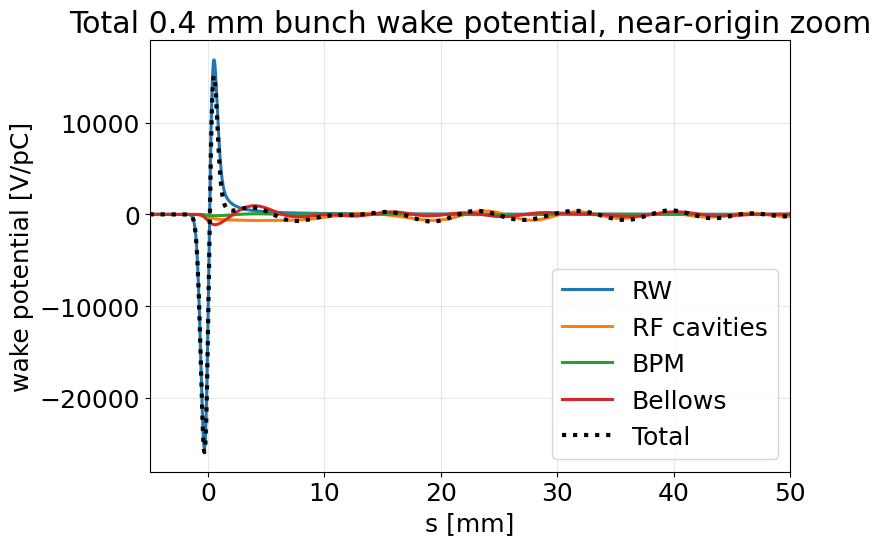

In [21]:
# =========================================================
# NEW CELL: Overplot total 0.4 mm wake potentials
#
# Components included:
#   RW
#   RF cavities
#   BPM
#   Bellows
#
# Units:
#   s: mm
#   W: V/pC
#
# Notes:
#   RF and BPM are multiplied internally.
#   Bellows file is assumed to already include the required multiplication.
#   RW is taken from results_rw_04mm.
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Component numbers
# ---------------------------------------------------------
n_rf = 112
n_bpm = 2720
n_bellows = 1   # bellows number is already included in W_bellows_long (sigma 0.4 mm).txt


# ---------------------------------------------------------
# Bellows wake file
# ---------------------------------------------------------
bellows_folder = os.path.join(repo_data, "bellows")

bellows_candidates = [
    os.path.join(bellows_folder, "W_bellows_long (sigma 0.4 mm).txt"),
    os.path.join(bellows_folder, "W_bellows_long (sigma 0.4 mm)"),
]

bellows_W_file = None
for candidate in bellows_candidates:
    if os.path.exists(candidate):
        bellows_W_file = candidate
        break

if bellows_W_file is None:
    raise FileNotFoundError(
        "Could not find bellows wake file. Tried:\n"
        + "\n".join(bellows_candidates)
    )

print(f"Using bellows wake file:\n{bellows_W_file}")


# ---------------------------------------------------------
# Reader for wake file
# ---------------------------------------------------------
def read_wake_file_any_header(filepath):
    """
    Read wake potential file with two columns:

        s [mm], W [V/pC]

    Comment/header lines starting with # are ignored.
    """
    data = np.loadtxt(filepath, comments="#")
    s_mm = data[:, 0]
    W_v_per_pC = data[:, 1]
    return s_mm, W_v_per_pC


# ---------------------------------------------------------
# Read bellows wake
# ---------------------------------------------------------
s_bell_mm, W_bell_single_v_per_pC = read_wake_file_any_header(bellows_W_file)


# ---------------------------------------------------------
# Get calculated RF, BPM, and RW wakes from previous results
# Already in:
#   s [mm]
#   W [V/pC]
# ---------------------------------------------------------
s_rf_mm = results_rf_04mm["s_pad_mm"]
W_rf_single_v_per_pC = results_rf_04mm["WP_conv_v_per_pC"]

s_bpm_mm = results_bpm_04mm["s_pad_mm"]
W_bpm_single_v_per_pC = results_bpm_04mm["WP_conv_v_per_pC"]

s_rw_mm = results_rw_04mm["s_bunch_mm"]
W_rw_v_per_pC = results_rw_04mm["W_bunch_v_per_pC"]


# ---------------------------------------------------------
# Apply total number of components
# ---------------------------------------------------------
W_rf_total_v_per_pC = n_rf * W_rf_single_v_per_pC
W_bpm_total_v_per_pC = n_bpm * W_bpm_single_v_per_pC
W_bell_total_v_per_pC = n_bellows * W_bell_single_v_per_pC

# RW is already the model/ring RW contribution used in Zz_C
W_rw_total_v_per_pC = W_rw_v_per_pC


# ---------------------------------------------------------
# Plot total component wake potentials
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_rw_mm,
    W_rw_total_v_per_pC,
    linewidth=2.5,
    label="RW",
)

plt.plot(
    s_rf_mm,
    W_rf_total_v_per_pC,
    linewidth=2.5,
    label="RF cavities",
)

plt.plot(
    s_bpm_mm,
    W_bpm_total_v_per_pC,
    linewidth=2.5,
    label="BPM",
)

plt.plot(
    s_bell_mm,
    W_bell_total_v_per_pC,
    linewidth=2.5,
    label="Bellows",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Component 0.4 mm bunch wake potentials")
plt.xlim(-20, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Near-origin zoom
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_rw_mm,
    W_rw_total_v_per_pC,
    linewidth=2.5,
    label="RW",
)

plt.plot(
    s_rf_mm,
    W_rf_total_v_per_pC,
    linewidth=2.5,
    label="RF cavities",
)

plt.plot(
    s_bpm_mm,
    W_bpm_total_v_per_pC,
    linewidth=2.5,
    label="BPM",
)

plt.plot(
    s_bell_mm,
    W_bell_total_v_per_pC,
    linewidth=2.5,
    label="Bellows",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Component 0.4 mm bunch wake potentials, near-origin zoom")
plt.xlim(-5, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Interpolate all components to common s-grid and sum
# ---------------------------------------------------------
s_common_mm = np.linspace(-10.0, 200.0, 7001)

W_rw_i = np.interp(
    s_common_mm,
    s_rw_mm,
    W_rw_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_rf_i = np.interp(
    s_common_mm,
    s_rf_mm,
    W_rf_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_bpm_i = np.interp(
    s_common_mm,
    s_bpm_mm,
    W_bpm_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_bell_i = np.interp(
    s_common_mm,
    s_bell_mm,
    W_bell_total_v_per_pC,
    left=0.0,
    right=0.0,
)

W_total_i = W_rw_i + W_rf_i + W_bpm_i + W_bell_i


# ---------------------------------------------------------
# Plot total wake potential
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_common_mm,
    W_rw_i,
    linewidth=2.2,
    label="RW",
)

plt.plot(
    s_common_mm,
    W_rf_i,
    linewidth=2.2,
    label="RF cavities",
)

plt.plot(
    s_common_mm,
    W_bpm_i,
    linewidth=2.2,
    label="BPM",
)

plt.plot(
    s_common_mm,
    W_bell_i,
    linewidth=2.2,
    label="Bellows",
)

plt.plot(
    s_common_mm,
    W_total_i,
    ":",
    color="black",
    linewidth=3.0,
    label="Total",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Total 0.4 mm bunch wake potential")
plt.xlim(-10, 200)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Near-origin zoom of total
# ---------------------------------------------------------
plt.figure(figsize=(8.5, 5.8))

plt.plot(
    s_common_mm,
    W_rw_i,
    linewidth=2.2,
    label="RW",
)

plt.plot(
    s_common_mm,
    W_rf_i,
    linewidth=2.2,
    label="RF cavities",
)

plt.plot(
    s_common_mm,
    W_bpm_i,
    linewidth=2.2,
    label="BPM",
)

plt.plot(
    s_common_mm,
    W_bell_i,
    linewidth=2.2,
    label="Bellows",
)

plt.plot(
    s_common_mm,
    W_total_i,
    ":",
    color="black",
    linewidth=3.0,
    label="Total",
)

plt.xlabel("s [mm]")
plt.ylabel("wake potential [V/pC]")
plt.title("Total 0.4 mm bunch wake potential, near-origin zoom")
plt.xlim(-5, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# Store for later use
# ---------------------------------------------------------
wake_budget_04mm = {
    "s_common_mm": s_common_mm,
    "W_rw_total_v_per_pC": W_rw_i,
    "W_rf_total_v_per_pC": W_rf_i,
    "W_bpm_total_v_per_pC": W_bpm_i,
    "W_bell_total_v_per_pC": W_bell_i,
    "W_total_v_per_pC": W_total_i,
}

Transverse dimensionless beta-weighting factors:
  RF x      = 269.14961329031115
  RF y      = 67.4923993513564
  BPM x     = 3018.757133548228
  BPM y     = 2867.8735507454576
  Bellows x = 1.0
  Bellows y = 1.0

RF cavities: calculating 0.4 mm transverse dipolar bunch wake, x-plane
  beta_factor is dimensionless = 2.691496132903e+02
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/Z_single_rf_cavity_dipx_filter_3mm.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 2.691496132903e+02
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_

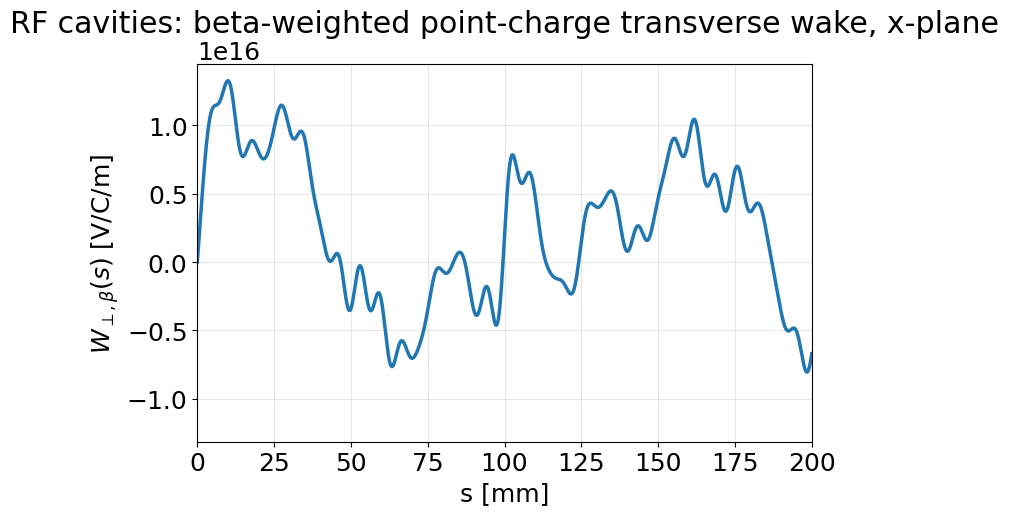

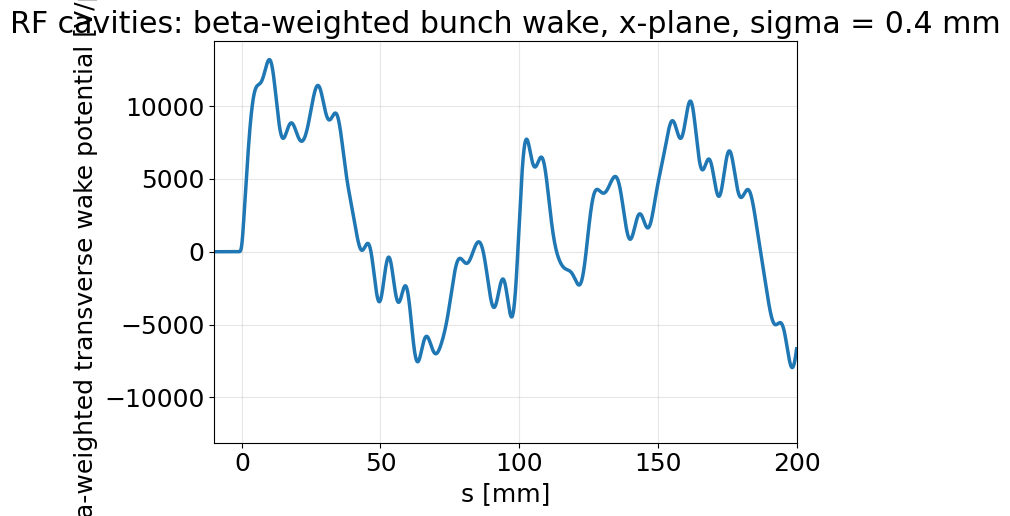


BPM: calculating 0.4 mm transverse dipolar bunch wake, x-plane
  beta_factor is dimensionless = 3.018757133548e+03
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/Z_bpm_dipx_3mm.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 3.018757133548e+03
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_weighted unit = Ohm/m
  W_point unit    = V/C/m
Saved transverse bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/W_bpm_dipx_beta_weighted (sigma 0.4 mm).txt
Saved range: -9.983089 mm to 199.991

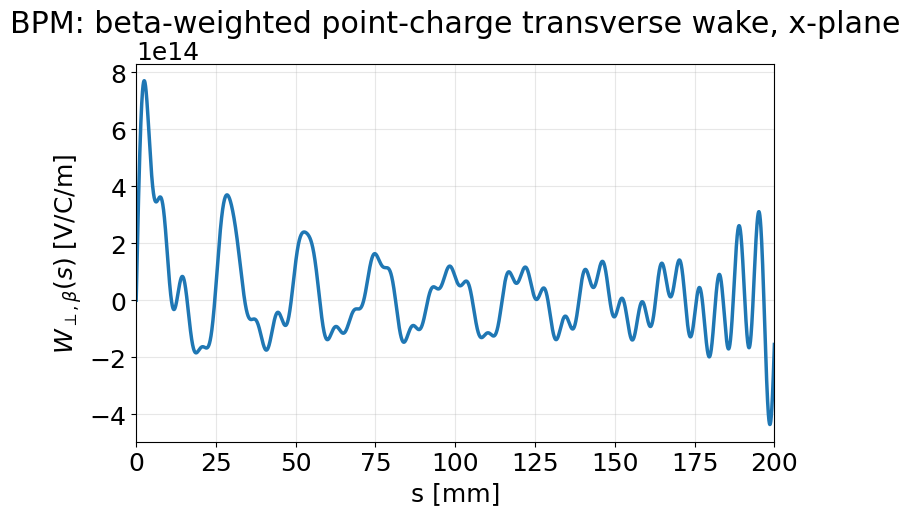

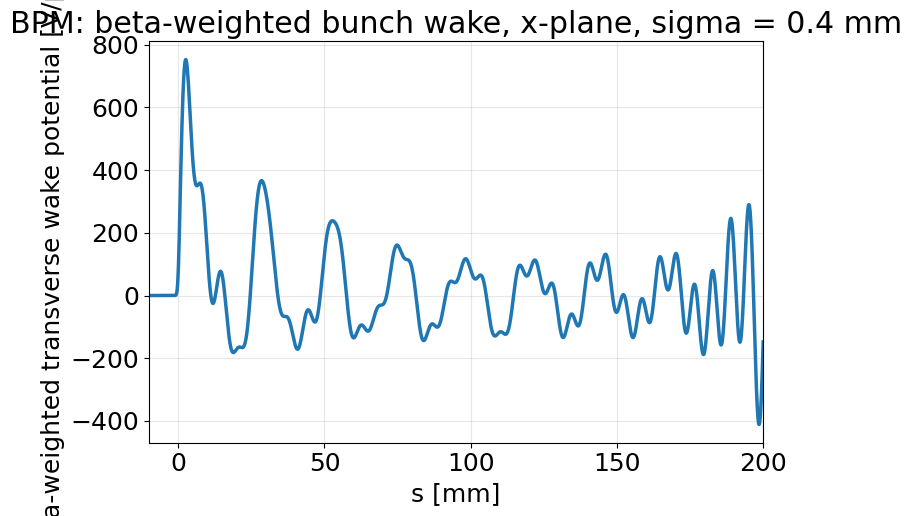


Bellows: calculating 0.4 mm transverse dipolar bunch wake, x-plane
  beta_factor is dimensionless = 1.000000000000e+00
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_dipx.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 1.000000000000e+00
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_weighted unit = Ohm/m
  W_point unit    = V/C/m
Saved transverse bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/W_bellows_dipx_avg_beta (sigma 0.4 mm).txt
Saved range: -9.983089 mm

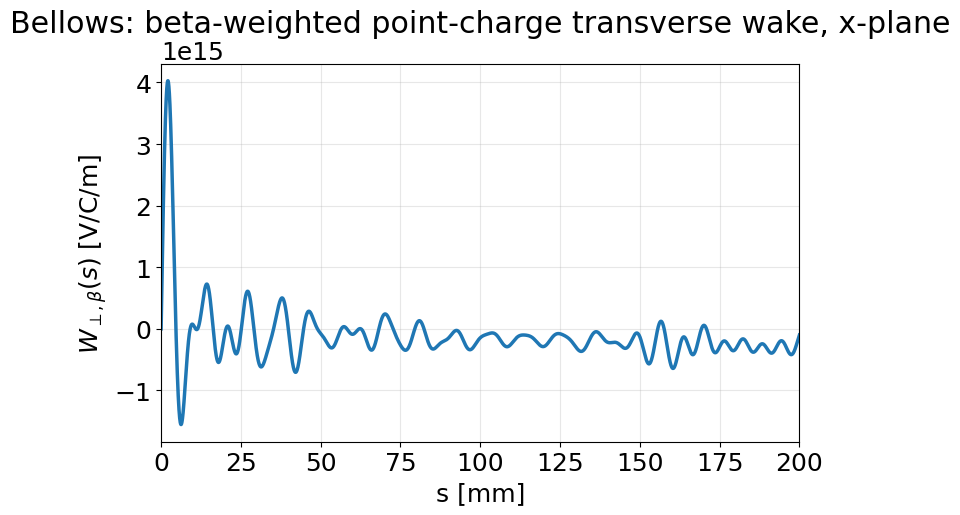

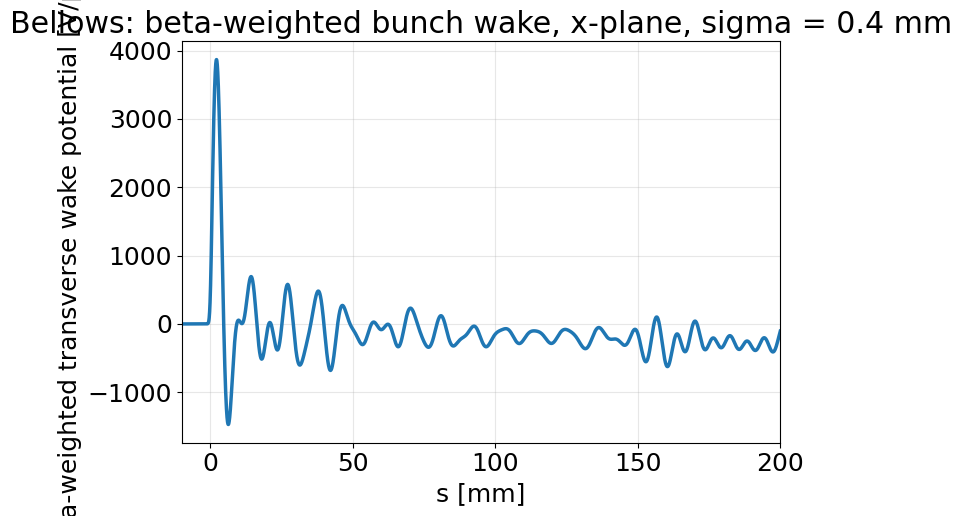

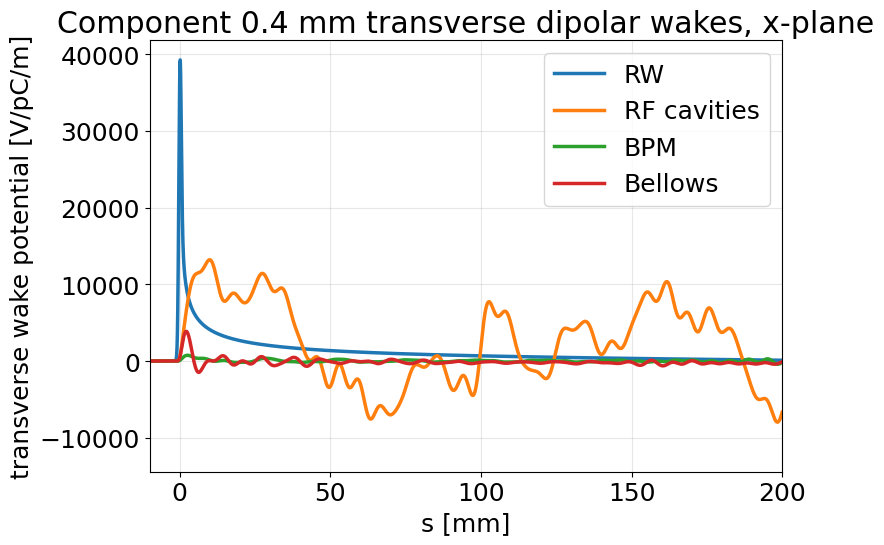

Saved total transverse wake to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/total/W_total_dipx_beta_weighted (sigma 0.4 mm).txt
Saved range: -10.000000 mm to 200.000000 mm
Number of saved samples: 7001


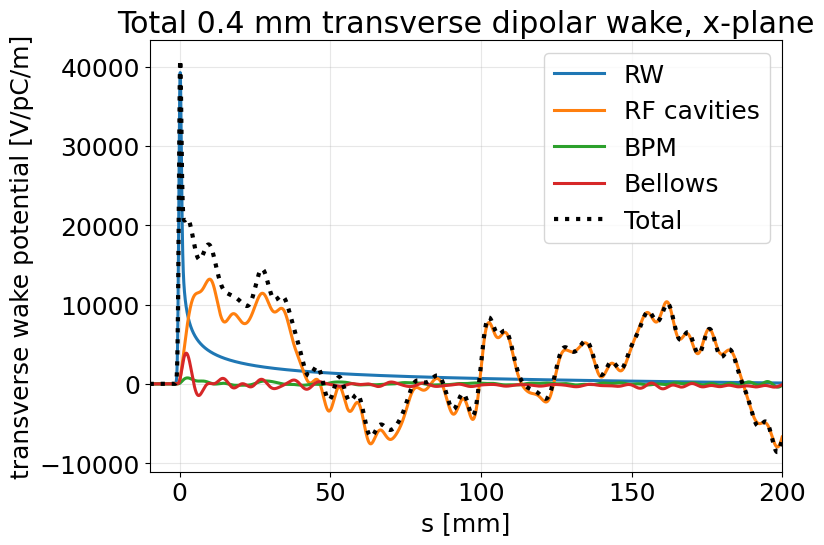

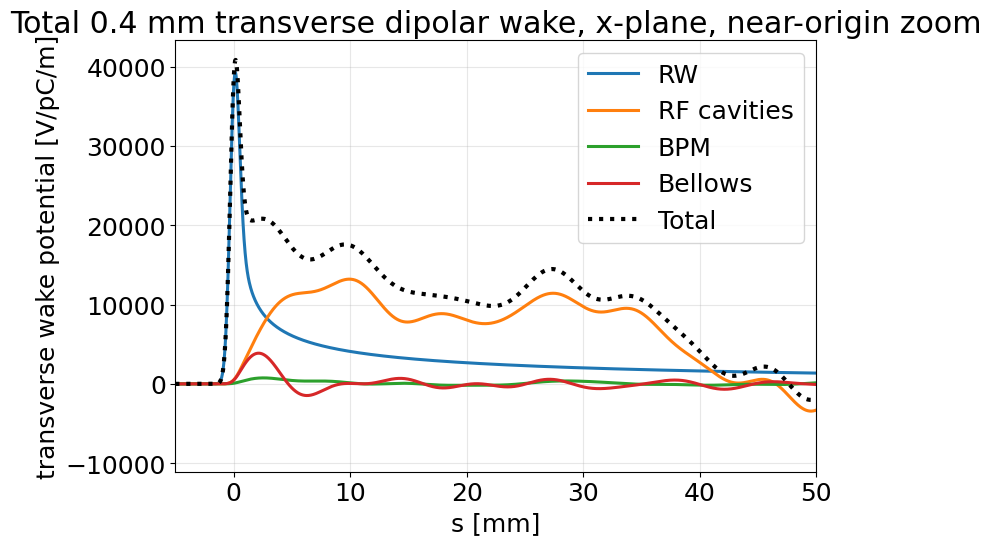


RF cavities: calculating 0.4 mm transverse dipolar bunch wake, y-plane
  beta_factor is dimensionless = 6.749239935136e+01
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/Z_single_rf_cavity_dipy_filter_3mm.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 6.749239935136e+01
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_weighted unit = Ohm/m
  W_point unit    = V/C/m
Saved transverse bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/W_single_rf_cavity_dipy_beta_weighte

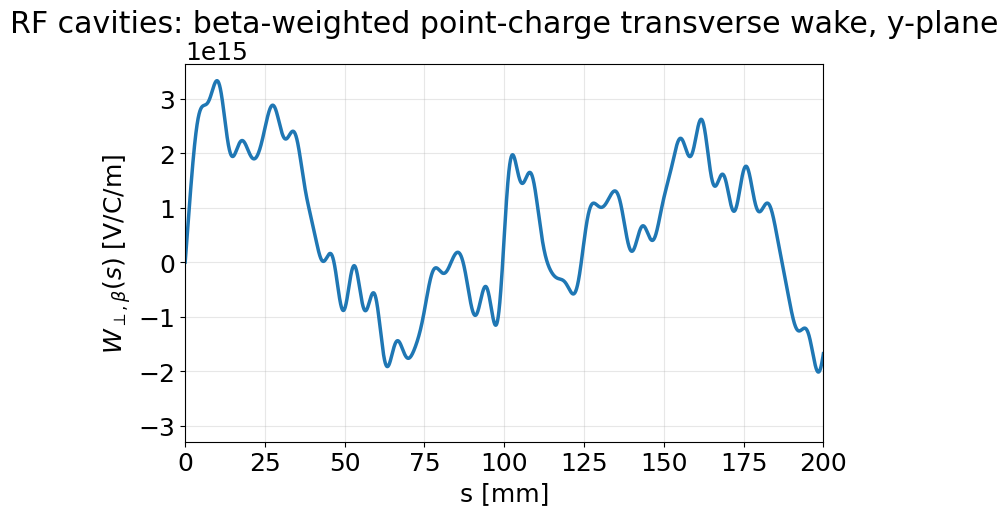

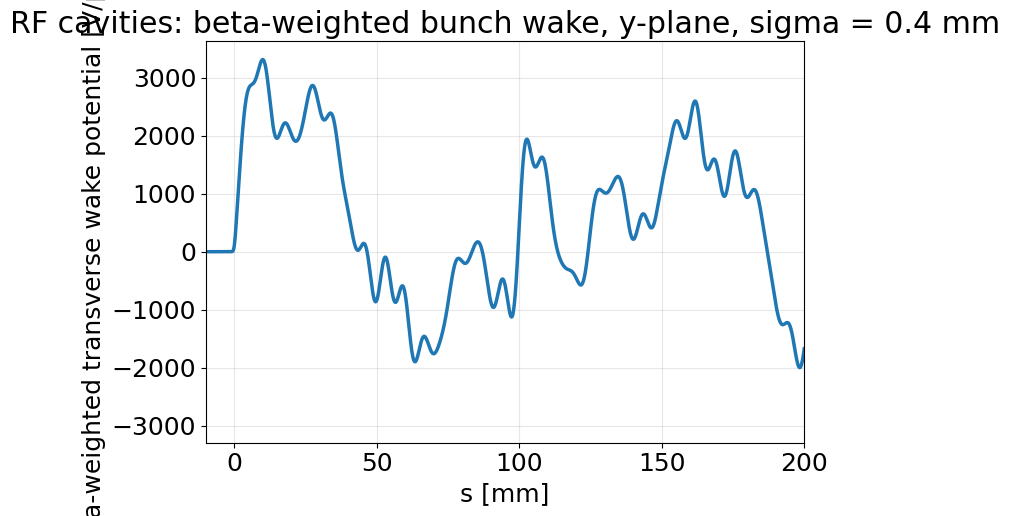


BPM: calculating 0.4 mm transverse dipolar bunch wake, y-plane
  beta_factor is dimensionless = 2.867873550745e+03
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/Z_bpm_dipy_3mm.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 2.867873550745e+03
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_weighted unit = Ohm/m
  W_point unit    = V/C/m
Saved transverse bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/W_bpm_dipy_beta_weighted (sigma 0.4 mm).txt
Saved range: -9.983089 mm to 199.991

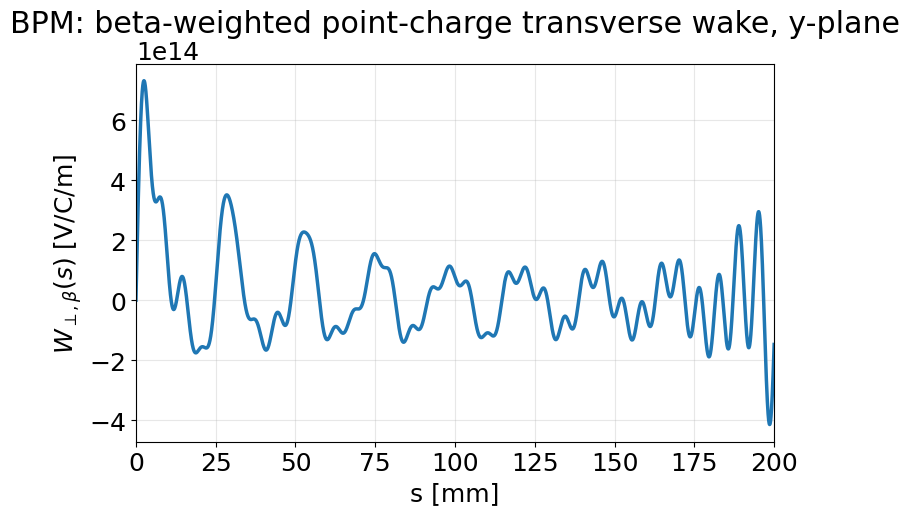

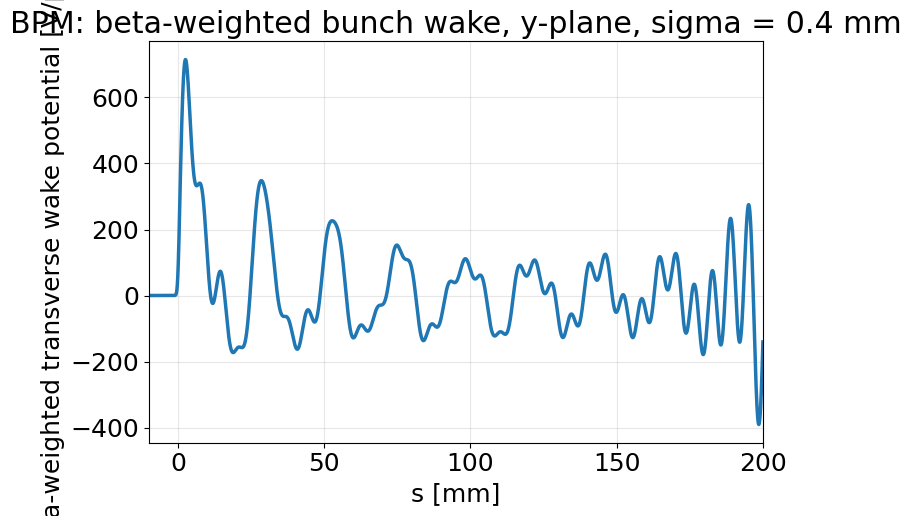


Bellows: calculating 0.4 mm transverse dipolar bunch wake, y-plane
  beta_factor is dimensionless = 1.000000000000e+00
Read impedance file: /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_dipy.txt
  detected frequency unit = GHz
  f range = 0.000000e+00 to 5.000000e+01 GHz
  samples = 5001
  assumed Z unit = Ohm/m
* Transverse Z -> point-charge wake
  dimensionless beta_factor = 1.000000000000e+00
  Input frequency range = 0.000000 GHz to 50.000000 GHz
  Number of input samples = 5001
  Number of uniform frequency samples = 200001
  fmax = 10000.000000 GHz
  df = 49.999750 MHz
  Number of wake samples = 100001
  dt = 0.100000 ps
  ds = 0.029979 mm
  tmax = 10.000000 ns
  smax = 2997.924580 mm
  Z_weighted unit = Ohm/m
  W_point unit    = V/C/m
Saved transverse bunch wake file to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/W_bellows_dipy_avg_beta (sigma 0.4 mm).txt
Saved range: -9.983089 mm

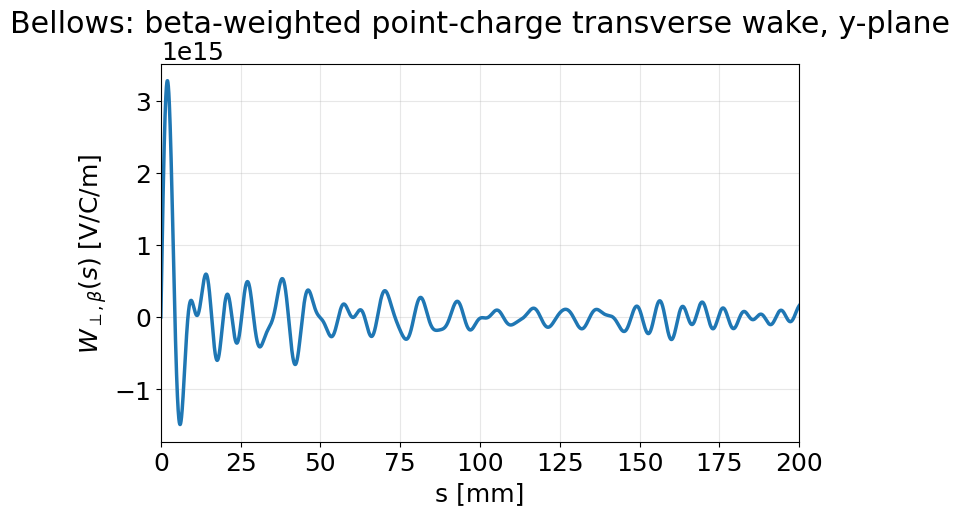

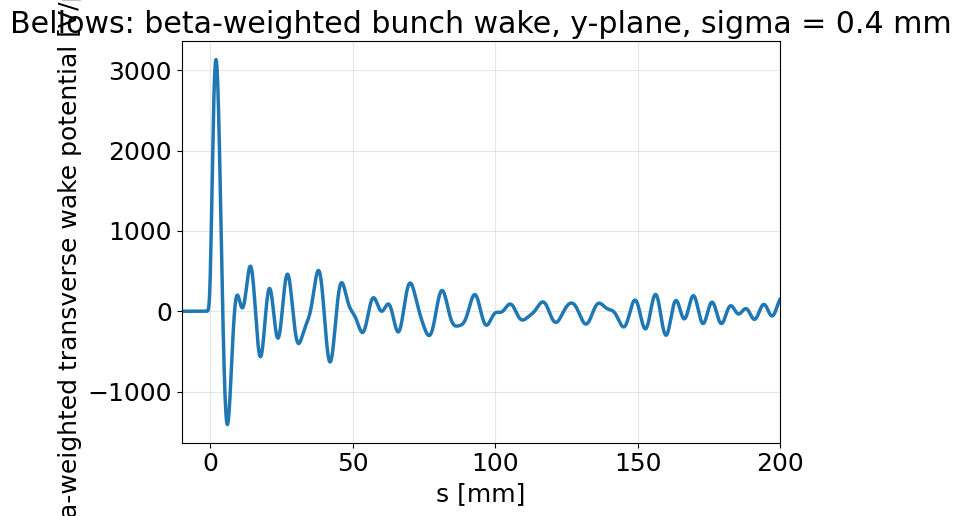

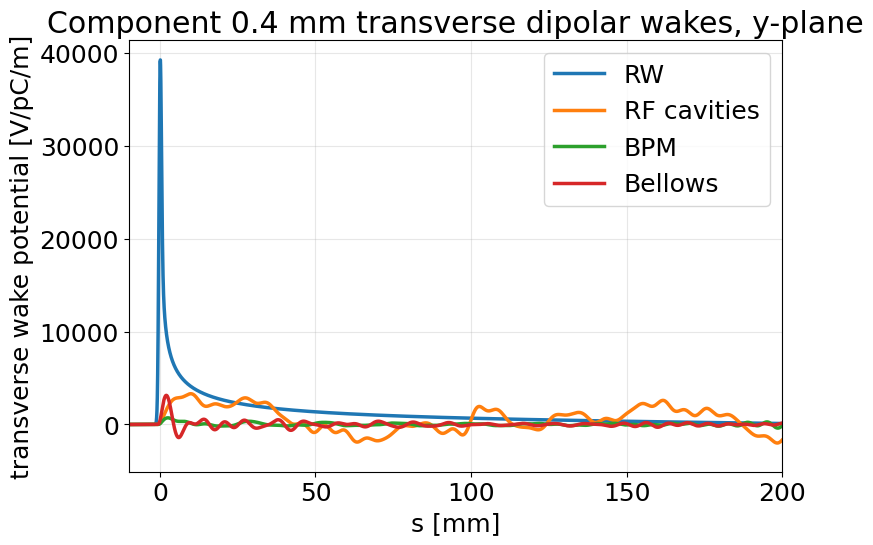

Saved total transverse wake to:
/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/total/W_total_dipy_beta_weighted (sigma 0.4 mm).txt
Saved range: -10.000000 mm to 200.000000 mm
Number of saved samples: 7001


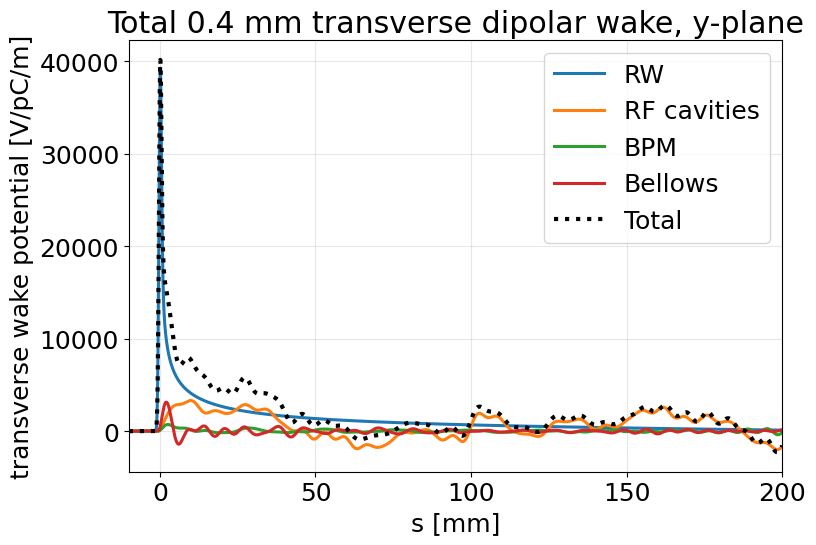

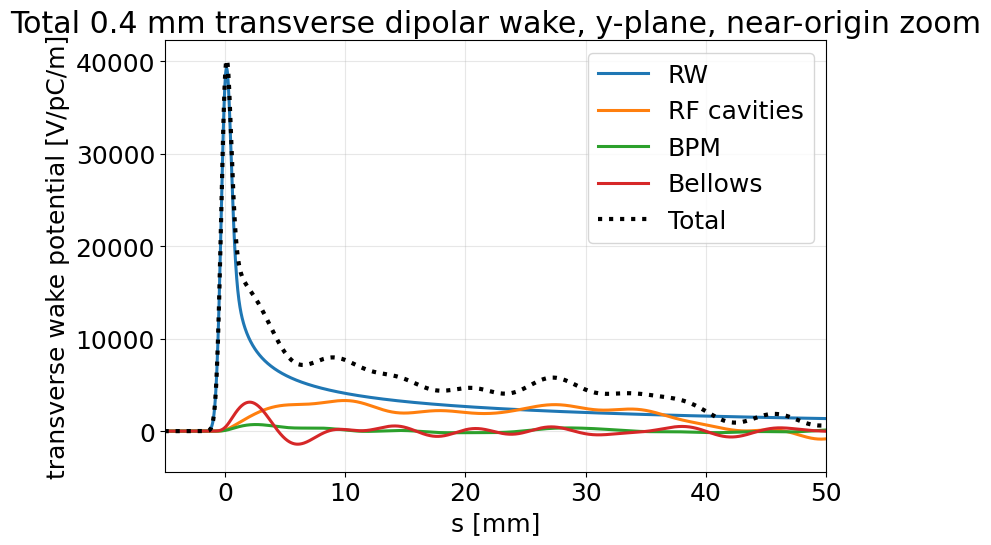

In [31]:
# =========================================================
# NEW CELL: Calculate 0.4 mm transverse dipolar RF/BPM/Bellows wakes,
# combine with already-calculated transverse RW wakes,
# and save total transverse wake budgets.
#
# Logic:
#   RW:
#     Already calculated separately from Zx_rw_budget / Zy_rw_budget.
#     No extra beta factor here.
#
#   Bellows:
#     Use average beta.
#     If the bellows impedance file already includes the required
#     number of bellows, use factor = 1.
#
#   RF:
#     Use one RF location from TFS.
#     112 physical RF cavities are assumed at the same beta.
#
#       factor_x = 112 * beta_x_RF / <beta_x>
#       factor_y = 112 * beta_y_RF / <beta_y>
#
#   BPM:
#     Use BPM-by-BPM beta weighting:
#
#       factor_x = sum_i beta_x_i / <beta_x>
#       factor_y = sum_i beta_y_i / <beta_y>
#
#     Missing BPM beta values are filled in HEBModel.
#
# IMPORTANT:
#   beta_factor is dimensionless.
#
#   It is NOT beta [m].
#   It is sum(beta_i / <beta>).
#
# Therefore:
#   input  single-device Z_perp : [Ohm/m]
#   output weighted Z_perp      : [Ohm/m]
#   output point wake           : [V/C/m]
#   output bunch wake           : [V/pC/m]
#
# Transverse wake transform:
#   Same convention as the RW transverse script:
#
#       W_perp = imag(ihfft(Re[Z_perp])) * 4 * df
#
# File naming:
#   _long -> _dipx and _dipy
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fft import ihfft
from scipy.signal import fftconvolve


# ---------------------------------------------------------
# Required objects
# ---------------------------------------------------------
required_vars = [
    "model_iw2d",
    "results_rw_x_dipole_04mm",
    "results_rw_y_dipole_04mm",
]

for var in required_vars:
    if var not in globals():
        raise NameError(
            f"{var} is not defined. "
            "Please build HEBModel and run the transverse RW wake calculation first."
        )


# ---------------------------------------------------------
# Base data folder
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"


# ---------------------------------------------------------
# Component beta-weighting factors
#
# These are dimensionless:
#
#   RF:
#       n_rf * beta_RF / <beta>
#
#   BPM:
#       sum_i beta_i / <beta>
#
#   Bellows:
#       1, if the bellows file already includes total count
# ---------------------------------------------------------
component_factors = {
    "x": {
        "rf": model_iw2d.rf_beta_factor_x,
        "bpm": model_iw2d.bpm_beta_factor_x,
        "bellows": model_iw2d.bellows_beta_factor_x,
    },
    "y": {
        "rf": model_iw2d.rf_beta_factor_y,
        "bpm": model_iw2d.bpm_beta_factor_y,
        "bellows": model_iw2d.bellows_beta_factor_y,
    },
}

print("Transverse dimensionless beta-weighting factors:")
print("  RF x      =", component_factors["x"]["rf"])
print("  RF y      =", component_factors["y"]["rf"])
print("  BPM x     =", component_factors["x"]["bpm"])
print("  BPM y     =", component_factors["y"]["bpm"])
print("  Bellows x =", component_factors["x"]["bellows"])
print("  Bellows y =", component_factors["y"]["bellows"])


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
def make_transverse_paths(plane):
    """
    plane = "x" or "y"
    Uses suffix dipx or dipy.
    """

    suffix = f"dip{plane}"

    rf_Z_file = os.path.join(
        repo_data,
        "rf_cavities",
        # f"Z_single_rf_cavity_{suffix}_3mm.txt",
        f"Z_single_rf_cavity_{suffix}_filter_3mm.txt",
    )

    bpm_Z_file = os.path.join(
        repo_data,
        "bpm",
        f"Z_bpm_{suffix}_3mm.txt",
    )

    bellows_Z_file = os.path.join(
        repo_data,
        "bellows",
        f"Z_bellows_{suffix}.txt",
    )

    rf_output_file = os.path.join(
        repo_data,
        "rf_cavities",
        f"W_single_rf_cavity_{suffix}_beta_weighted (sigma 0.4 mm).txt",
    )

    bpm_output_file = os.path.join(
        repo_data,
        "bpm",
        f"W_bpm_{suffix}_beta_weighted (sigma 0.4 mm).txt",
    )

    bellows_output_file = os.path.join(
        repo_data,
        "bellows",
        f"W_bellows_{suffix}_avg_beta (sigma 0.4 mm).txt",
    )

    total_folder = os.path.join(repo_data, "total")
    os.makedirs(total_folder, exist_ok=True)

    total_wake_output_file = os.path.join(
        total_folder,
        f"W_total_{suffix}_beta_weighted (sigma 0.4 mm).txt",
    )

    return {
        "rf_Z_file": rf_Z_file,
        "bpm_Z_file": bpm_Z_file,
        "bellows_Z_file": bellows_Z_file,
        "rf_output_file": rf_output_file,
        "bpm_output_file": bpm_output_file,
        "bellows_output_file": bellows_output_file,
        "total_wake_output_file": total_wake_output_file,
    }


# ---------------------------------------------------------
# Flexible impedance reader
# ---------------------------------------------------------
def read_impedance_file_auto(
    filepath,
    freq_col=0,
    re_col=1,
    im_col=2,
    freq_unit="auto",
):
    """
    Read transverse dipolar impedance file.

    Expected minimum format:
        frequency, Re(Z), Im(Z)

    Frequency can be in GHz or Hz.

    If freq_unit="auto":
        max(f) < 1e6 is treated as GHz.
        otherwise Hz.

    Returns
    -------
    f_hz : ndarray
        Frequency [Hz].

    Z : ndarray
        Complex transverse dipolar impedance [Ohm/m].
    """

    data = np.loadtxt(filepath, comments="#")

    if data.ndim == 1:
        data = data[None, :]

    if data.shape[1] <= max(freq_col, re_col, im_col):
        raise ValueError(
            f"File {filepath} has only {data.shape[1]} columns. "
            f"Need columns {freq_col}, {re_col}, {im_col}."
        )

    f_raw = data[:, freq_col]
    re = data[:, re_col]
    im = data[:, im_col]

    if freq_unit == "auto":
        if np.nanmax(np.abs(f_raw)) < 1e6:
            f_hz = f_raw * 1e9
            detected_unit = "GHz"
        else:
            f_hz = f_raw
            detected_unit = "Hz"

    elif freq_unit.lower() == "ghz":
        f_hz = f_raw * 1e9
        detected_unit = "GHz"

    elif freq_unit.lower() == "hz":
        f_hz = f_raw
        detected_unit = "Hz"

    else:
        raise ValueError("freq_unit must be 'auto', 'GHz', or 'Hz'.")

    Z = re + 1j * im

    print(f"Read impedance file: {filepath}")
    print(f"  detected frequency unit = {detected_unit}")
    print(f"  f range = {f_hz[0]/1e9:.6e} to {f_hz[-1]/1e9:.6e} GHz")
    print(f"  samples = {len(f_hz)}")
    print("  assumed Z unit = Ohm/m")

    return f_hz, Z


def interp_complex(f_src, Z_src, f_dst):
    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re + 1j * im


# ---------------------------------------------------------
# Transverse Z -> point-charge wake
# ---------------------------------------------------------
def calc_transverse_wake_from_Z(
    impedance,
    f=None,
    beta_factor=1.0,
    fmax_test=10000e9,
    n_freq=200001,
    verbose=True,
):
    """
    Calculate transverse dipolar point-charge wake.

    The input impedance is assumed to be a single-device transverse
    dipolar impedance [Ohm/m].

    beta_factor is dimensionless:

        beta_factor = sum_i beta_i / <beta>

    Therefore:

        Z_weighted = beta_factor * Z_single

    still has unit [Ohm/m].

    Output:
        W_point [V/C/m]
    """

    if isinstance(impedance, list):
        f_in = np.asarray(impedance[0])
        Z_in = np.asarray(impedance[1])
    else:
        if f is None:
            raise AttributeError("Provide frequency array f.")
        f_in = np.asarray(f)
        Z_in = np.asarray(impedance)

    order = np.argsort(f_in)
    f_in = f_in[order]
    Z_in = Z_in[order]

    # Dimensionless beta weighting
    Z_in_weighted = beta_factor * Z_in

    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)
    Z_uniform = interp_complex(f_in, Z_in_weighted, f_uniform)

    # Avoid artificial DC ambiguity
    Z_uniform[0] = 0.0 + 0.0j

    df = np.mean(np.diff(f_uniform))
    fmax = np.max(f_uniform)

    Nf = len(f_uniform)
    Nt = Nf // 2 + 1

    dt = 1.0 / fmax
    t = np.arange(Nt) * dt

    # Transverse convention
    W = np.imag(ihfft(Z_uniform.real, norm="forward")) * 4.0 * df

    # Half-weight at boundaries
    W[[0, -1]] *= 0.5

    if verbose:
        print("* Transverse Z -> point-charge wake")
        print(f"  dimensionless beta_factor = {beta_factor:.12e}")
        print(f"  Input frequency range = {f_in[0]/1e9:.6f} GHz to {f_in[-1]/1e9:.6f} GHz")
        print(f"  Number of input samples = {len(f_in)}")
        print(f"  Number of uniform frequency samples = {Nf}")
        print(f"  fmax = {fmax / 1e9:.6f} GHz")
        print(f"  df = {df / 1e6:.6f} MHz")
        print(f"  Number of wake samples = {Nt}")
        print(f"  dt = {dt * 1e12:.6f} ps")
        print(f"  ds = {dt * c * 1e3:.6f} mm")
        print(f"  tmax = {t[-1] * 1e9:.6f} ns")
        print(f"  smax = {t[-1] * c * 1e3:.6f} mm")
        print("  Z_weighted unit = Ohm/m")
        print("  W_point unit    = V/C/m")

    return t, W, f_uniform, Z_uniform


# ---------------------------------------------------------
# Point-charge wake -> Gaussian bunch wake
# ---------------------------------------------------------
def convolve_point_wake_with_gaussian(
    t_point,
    W_point,
    sigma_z_mm=0.4,
    convolution_sign=+1.0,
):
    """
    Convolve transverse point-charge wake with Gaussian bunch profile.

    Input:
        W_point [V/C/m]

    Output:
        WP_conv_v_per_pC_per_m [V/pC/m]
    """

    sigma_t = sigma_z_mm * 1e-3 / c

    N = len(t_point)
    dt = np.mean(np.diff(t_point))

    t_pad = np.arange(-(N - 1), N) * dt

    W_point_pad = np.zeros_like(t_pad)
    W_point_pad[N - 1:] = W_point

    lambda_t = (
        1.0 / (sigma_t * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * (t_pad / sigma_t) ** 2)
    )

    WP_conv = convolution_sign * fftconvolve(
        W_point_pad,
        lambda_t,
        mode="same",
    ) * dt

    # V/C/m -> V/pC/m
    WP_conv_v_per_pC_per_m = WP_conv * 1e-12

    s_pad_mm = t_pad * c * 1e3

    return t_pad, s_pad_mm, WP_conv_v_per_pC_per_m, lambda_t, W_point_pad


# ---------------------------------------------------------
# Save transverse bunch wake
# ---------------------------------------------------------
def save_transverse_bunch_wake_file(
    output_file,
    s_mm,
    W_v_per_pC_per_m,
    plane_label="x",
    sigma_z_mm=0.4,
    cpw=15,
    wakelength=200,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
):
    mask = (s_mm >= s_min_save_mm) & (s_mm <= s_max_save_mm)

    s_save = s_mm[mask]
    W_save = W_v_per_pC_per_m[mask]

    if len(s_save) == 0:
        raise ValueError("No bunch wake data selected for saving.")

    with open(output_file, "w") as f:
        f.write(
            f"#Parameters = {{cpw={cpw}; sigma_z={sigma_z_mm}; "
            f"wakelength={wakelength}; xbeam=0; xtest=0; "
            f"ybeam=0; ytest=0}}\n"
        )
        f.write(f"# Beta-weighted transverse dipolar bunch wake, {plane_label}-plane\n")
        f.write("# beta_factor is dimensionless: sum(beta_i/<beta>)\n")
        f.write("# Z_perp unit: Ohm/m\n")
        f.write('#"s / mm"\t"W_perp_beta [V/pC/m]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_save, W_save):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved transverse bunch wake file to:\n{output_file}")
    print(f"Saved range: {s_save[0]:.6f} mm to {s_save[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_save)}")


# ---------------------------------------------------------
# Calculate and save one transverse component
# ---------------------------------------------------------
def calculate_and_save_transverse_component_wake(
    name,
    plane_label,
    Z_file,
    output_file,
    beta_factor,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
    s_min_save_mm=-10.0,
    s_max_save_mm=200.0,
    xlim_mm=(-10, 200),
    freq_unit="auto",
    freq_col=0,
    re_col=1,
    im_col=2,
    convolution_sign=+1.0,
):
    print("\n" + "=" * 80)
    print(f"{name}: calculating {sigma_z_mm} mm transverse dipolar bunch wake, {plane_label}-plane")
    print("=" * 80)
    print(f"  beta_factor is dimensionless = {beta_factor:.12e}")

    if not os.path.exists(Z_file):
        raise FileNotFoundError(f"Impedance file does not exist:\n{Z_file}")

    f_Z, Z = read_impedance_file_auto(
        Z_file,
        freq_col=freq_col,
        re_col=re_col,
        im_col=im_col,
        freq_unit=freq_unit,
    )

    t_point, W_point, f_uniform, Z_uniform = calc_transverse_wake_from_Z(
        [f_Z, Z],
        beta_factor=beta_factor,
        fmax_test=fmax_test,
        n_freq=n_freq,
        verbose=True,
    )

    t_pad, s_pad_mm, WP_conv_v_per_pC_per_m, lambda_t, W_point_pad = (
        convolve_point_wake_with_gaussian(
            t_point=t_point,
            W_point=W_point,
            sigma_z_mm=sigma_z_mm,
            convolution_sign=convolution_sign,
        )
    )

    save_transverse_bunch_wake_file(
        output_file=output_file,
        s_mm=s_pad_mm,
        W_v_per_pC_per_m=WP_conv_v_per_pC_per_m,
        plane_label=plane_label,
        sigma_z_mm=sigma_z_mm,
        cpw=15,
        wakelength=200,
        s_min_save_mm=s_min_save_mm,
        s_max_save_mm=s_max_save_mm,
    )

    # Plot point-charge wake
    plt.figure(figsize=(8, 5.5))
    plt.plot(t_point * c * 1e3, W_point, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"$W_{\perp,\beta}(s)$ [V/C/m]")
    plt.title(f"{name}: beta-weighted point-charge transverse wake, {plane_label}-plane")
    plt.xlim(0, 200)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Plot bunch wake
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_pad_mm, WP_conv_v_per_pC_per_m, linewidth=2.5)
    plt.xlabel("s [mm]")
    plt.ylabel(r"beta-weighted transverse wake potential [V/pC/m]")
    plt.title(f"{name}: beta-weighted bunch wake, {plane_label}-plane, sigma = {sigma_z_mm} mm")
    plt.xlim(*xlim_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "plane_label": plane_label,
        "Z_file": Z_file,
        "output_file": output_file,
        "beta_factor": beta_factor,
        "f_Z": f_Z,
        "Z": Z,
        "f_uniform": f_uniform,
        "Z_uniform": Z_uniform,
        "t_point": t_point,
        "W_point_v_per_C_per_m": W_point,
        "t_pad": t_pad,
        "s_bunch_mm": s_pad_mm,
        "W_bunch_v_per_pC_per_m": WP_conv_v_per_pC_per_m,

        # compatibility aliases
        "W_point_v_per_C": W_point,
        "W_bunch_v_per_pC": WP_conv_v_per_pC_per_m,

        "lambda_t": lambda_t,
        "W_point_pad": W_point_pad,
        "sigma_z_mm": sigma_z_mm,
        "unit_point": "V/C/m",
        "unit_bunch": "V/pC/m",
    }


# ---------------------------------------------------------
# One-plane transverse budget
# ---------------------------------------------------------
def calculate_total_transverse_budget_one_plane(
    plane_label,
    rw_result,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
):
    assert plane_label in ["x", "y"]

    paths = make_transverse_paths(plane_label)

    rf_factor = component_factors[plane_label]["rf"]
    bpm_factor = component_factors[plane_label]["bpm"]
    bellows_factor = component_factors[plane_label]["bellows"]

    results_rf = calculate_and_save_transverse_component_wake(
        name="RF cavities",
        plane_label=plane_label,
        Z_file=paths["rf_Z_file"],
        output_file=paths["rf_output_file"],
        beta_factor=rf_factor,
        sigma_z_mm=sigma_z_mm,
        fmax_test=fmax_test,
        n_freq=n_freq,
        s_min_save_mm=-10.0,
        s_max_save_mm=200.0,
        xlim_mm=(-10, 200),
    )

    results_bpm = calculate_and_save_transverse_component_wake(
        name="BPM",
        plane_label=plane_label,
        Z_file=paths["bpm_Z_file"],
        output_file=paths["bpm_output_file"],
        beta_factor=bpm_factor,
        sigma_z_mm=sigma_z_mm,
        fmax_test=fmax_test,
        n_freq=n_freq,
        s_min_save_mm=-10.0,
        s_max_save_mm=200.0,
        xlim_mm=(-10, 200),
    )

    results_bellows = calculate_and_save_transverse_component_wake(
        name="Bellows",
        plane_label=plane_label,
        Z_file=paths["bellows_Z_file"],
        output_file=paths["bellows_output_file"],
        beta_factor=bellows_factor,
        sigma_z_mm=sigma_z_mm,
        fmax_test=fmax_test,
        n_freq=n_freq,
        s_min_save_mm=-10.0,
        s_max_save_mm=200.0,
        xlim_mm=(-10, 200),
    )

    # -----------------------------------------------------
    # Get component wakes
    # -----------------------------------------------------
    s_rw_mm = rw_result["s_bunch_mm"]
    W_rw = rw_result["W_bunch_v_per_pC"]

    s_rf_mm = results_rf["s_bunch_mm"]
    W_rf = results_rf["W_bunch_v_per_pC"]

    s_bpm_mm = results_bpm["s_bunch_mm"]
    W_bpm = results_bpm["W_bunch_v_per_pC"]

    s_bell_mm = results_bellows["s_bunch_mm"]
    W_bell = results_bellows["W_bunch_v_per_pC"]

    # -----------------------------------------------------
    # Plot components
    # -----------------------------------------------------
    plt.figure(figsize=(8.5, 5.8))

    plt.plot(s_rw_mm, W_rw, linewidth=2.5, label="RW")
    plt.plot(s_rf_mm, W_rf, linewidth=2.5, label="RF cavities")
    plt.plot(s_bpm_mm, W_bpm, linewidth=2.5, label="BPM")
    plt.plot(s_bell_mm, W_bell, linewidth=2.5, label="Bellows")

    plt.xlabel("s [mm]")
    plt.ylabel(r"transverse wake potential [V/pC/m]")
    plt.title(f"Component 0.4 mm transverse dipolar wakes, {plane_label}-plane")
    plt.xlim(-10, 200)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Common grid and sum
    # -----------------------------------------------------
    s_common_mm = np.linspace(-10.0, 200.0, 7001)

    W_rw_i = np.interp(s_common_mm, s_rw_mm, W_rw, left=0.0, right=0.0)
    W_rf_i = np.interp(s_common_mm, s_rf_mm, W_rf, left=0.0, right=0.0)
    W_bpm_i = np.interp(s_common_mm, s_bpm_mm, W_bpm, left=0.0, right=0.0)
    W_bell_i = np.interp(s_common_mm, s_bell_mm, W_bell, left=0.0, right=0.0)

    W_total_i = W_rw_i + W_rf_i + W_bpm_i + W_bell_i

    # -----------------------------------------------------
    # Save total
    # -----------------------------------------------------
    with open(paths["total_wake_output_file"], "w") as f:
        f.write(
            f"#Parameters = {{cpw=15; sigma_z={sigma_z_mm}; wakelength=200; "
            "xbeam=0; xtest=0; ybeam=0; ytest=0}\n"
        )
        f.write(f"# Total transverse dipolar wake, {plane_label}-plane\n")
        f.write("# RF/BPM beta factors are dimensionless: sum(beta_i/<beta>)\n")
        f.write('#"s / mm"\t"W_perp_total [V/pC/m]"\n')
        f.write("#------------------------\n")

        for si, Wi in zip(s_common_mm, W_total_i):
            f.write(f"{si:.12f}\t{Wi:.13e}\n")

    print(f"Saved total transverse wake to:\n{paths['total_wake_output_file']}")
    print(f"Saved range: {s_common_mm[0]:.6f} mm to {s_common_mm[-1]:.6f} mm")
    print(f"Number of saved samples: {len(s_common_mm)}")

    # -----------------------------------------------------
    # Plot total with components
    # -----------------------------------------------------
    plt.figure(figsize=(8.5, 5.8))

    plt.plot(s_common_mm, W_rw_i, linewidth=2.2, label="RW")
    plt.plot(s_common_mm, W_rf_i, linewidth=2.2, label="RF cavities")
    plt.plot(s_common_mm, W_bpm_i, linewidth=2.2, label="BPM")
    plt.plot(s_common_mm, W_bell_i, linewidth=2.2, label="Bellows")
    plt.plot(s_common_mm, W_total_i, ":", color="black", linewidth=3.0, label="Total")

    plt.xlabel("s [mm]")
    plt.ylabel(r"transverse wake potential [V/pC/m]")
    plt.title(f"Total 0.4 mm transverse dipolar wake, {plane_label}-plane")
    plt.xlim(-10, 200)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Near-origin zoom
    # -----------------------------------------------------
    plt.figure(figsize=(8.5, 5.8))

    plt.plot(s_common_mm, W_rw_i, linewidth=2.2, label="RW")
    plt.plot(s_common_mm, W_rf_i, linewidth=2.2, label="RF cavities")
    plt.plot(s_common_mm, W_bpm_i, linewidth=2.2, label="BPM")
    plt.plot(s_common_mm, W_bell_i, linewidth=2.2, label="Bellows")
    plt.plot(s_common_mm, W_total_i, ":", color="black", linewidth=3.0, label="Total")

    plt.xlabel("s [mm]")
    plt.ylabel(r"transverse wake potential [V/pC/m]")
    plt.title(f"Total 0.4 mm transverse dipolar wake, {plane_label}-plane, near-origin zoom")
    plt.xlim(-5, 50)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return {
        "plane_label": plane_label,
        "s_common_mm": s_common_mm,
        "W_rw_total_v_per_pC_per_m": W_rw_i,
        "W_rf_total_v_per_pC_per_m": W_rf_i,
        "W_bpm_total_v_per_pC_per_m": W_bpm_i,
        "W_bell_total_v_per_pC_per_m": W_bell_i,
        "W_total_v_per_pC_per_m": W_total_i,

        # compatibility aliases
        "W_rw_total_v_per_pC": W_rw_i,
        "W_rf_total_v_per_pC": W_rf_i,
        "W_bpm_total_v_per_pC": W_bpm_i,
        "W_bell_total_v_per_pC": W_bell_i,
        "W_total_v_per_pC": W_total_i,

        "results_rf": results_rf,
        "results_bpm": results_bpm,
        "results_bellows": results_bellows,
        "total_wake_output_file": paths["total_wake_output_file"],
        "unit": "V/pC/m",
    }


# ---------------------------------------------------------
# Run x and y transverse budgets
# ---------------------------------------------------------
wake_budget_x_dipole_04mm = calculate_total_transverse_budget_one_plane(
    plane_label="x",
    rw_result=results_rw_x_dipole_04mm,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
)

wake_budget_y_dipole_04mm = calculate_total_transverse_budget_one_plane(
    plane_label="y",
    rw_result=results_rw_y_dipole_04mm,
    sigma_z_mm=0.4,
    fmax_test=10000e9,
    n_freq=200001,
)


===== RW: Z -> W -> Z test =====
* Number of samples = 50001
* Maximum time = 500.000000 ns
* Time resolution = 10.000000 ps
* Relativistic beta = 1.0
* Number of samples = 50000
* Maximum frequency = 99.998000 GHz
* Frequency resolution = 2.000000 MHz
* Relativistic beta = 1.0


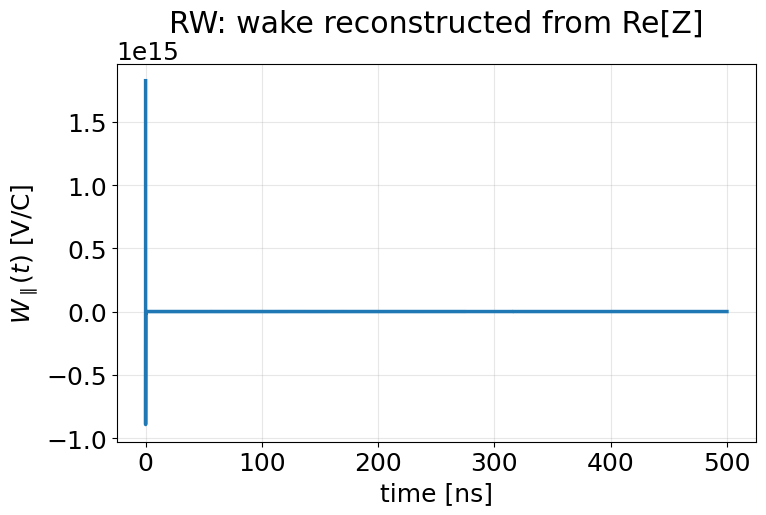

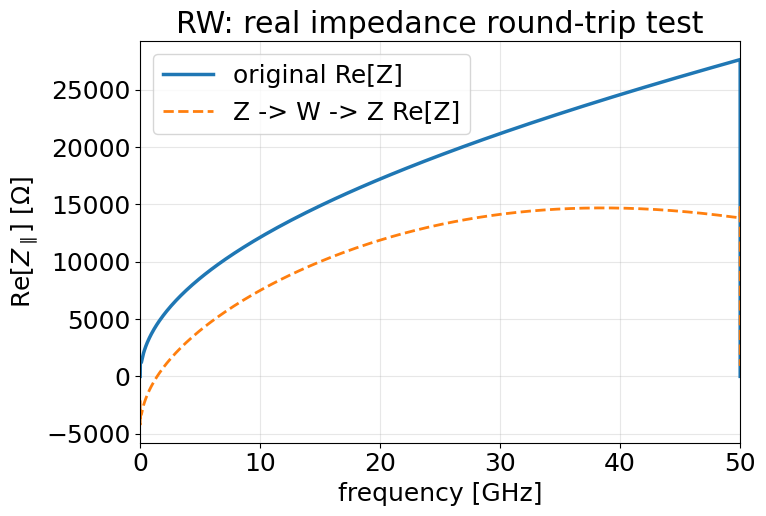

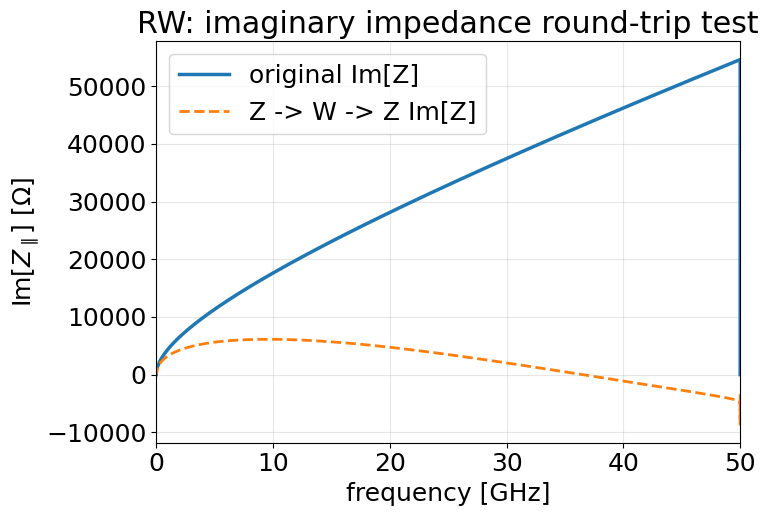

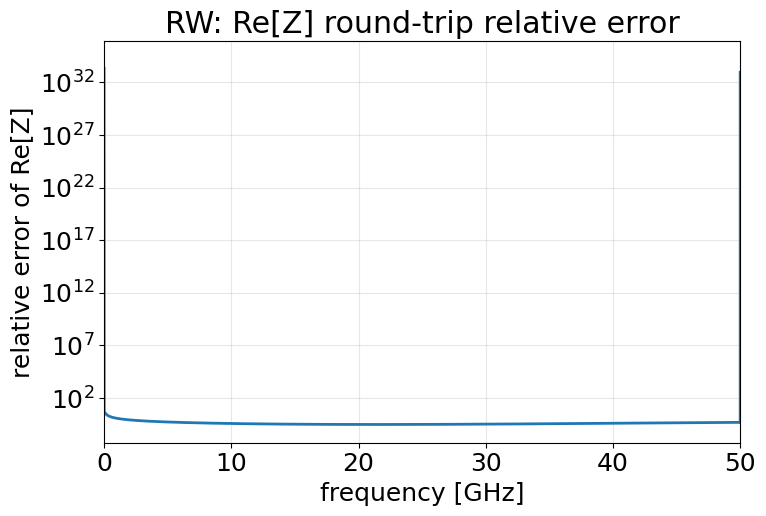

RW: max |Re error| = 2.673137e+04
RW: rms |Re error| = 7.663612e+03

===== Bellows: Z -> W -> Z test =====
* Number of samples = 50001
* Maximum time = 500.000000 ns
* Time resolution = 10.000000 ps
* Relativistic beta = 1.0
* Number of samples = 50000
* Maximum frequency = 99.998000 GHz
* Frequency resolution = 2.000000 MHz
* Relativistic beta = 1.0


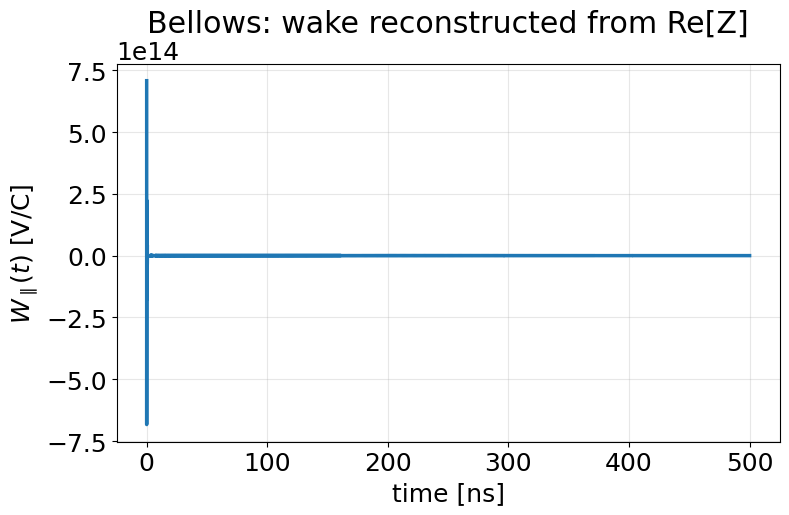

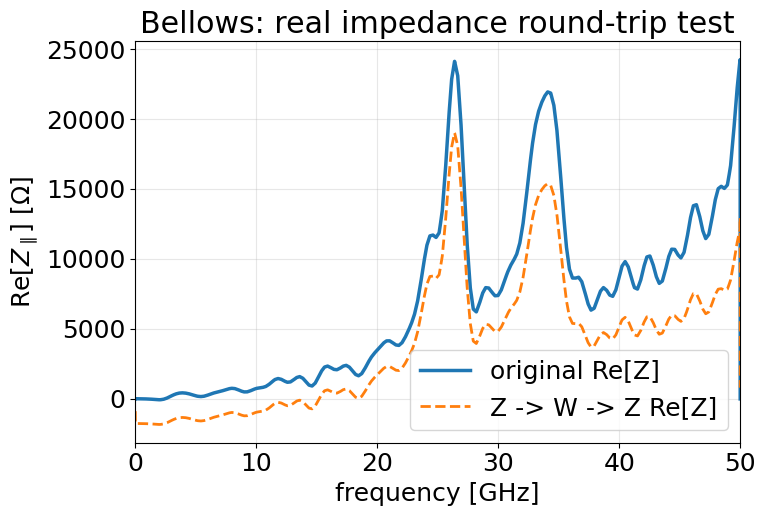

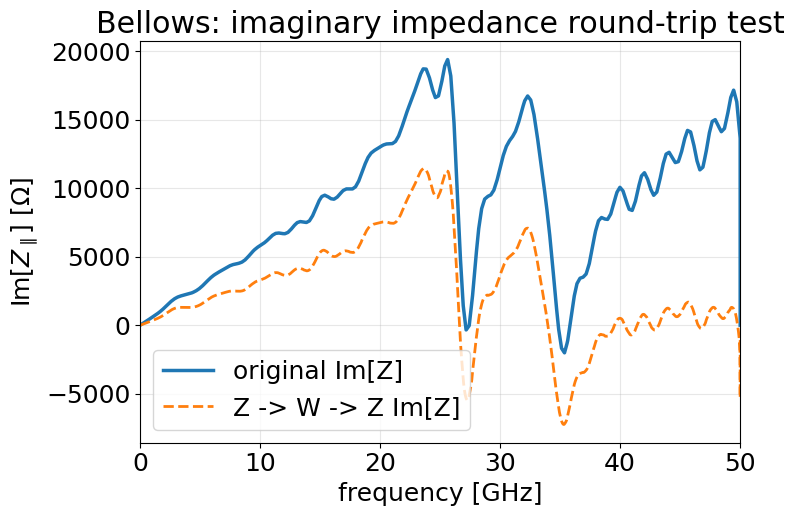

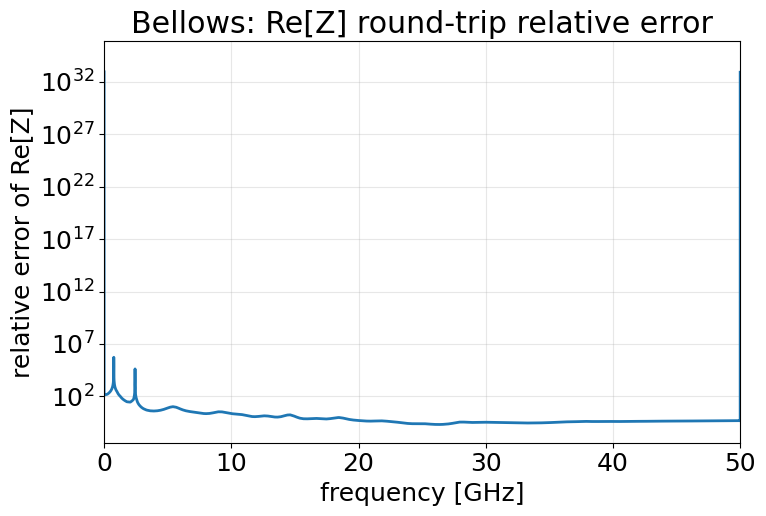

Bellows: max |Re error| = 2.344329e+04
Bellows: rms |Re error| = 3.595992e+03

===== BPM: Z -> W -> Z test =====
* Number of samples = 50001
* Maximum time = 500.000000 ns
* Time resolution = 10.000000 ps
* Relativistic beta = 1.0
* Number of samples = 50000
* Maximum frequency = 99.998000 GHz
* Frequency resolution = 2.000000 MHz
* Relativistic beta = 1.0


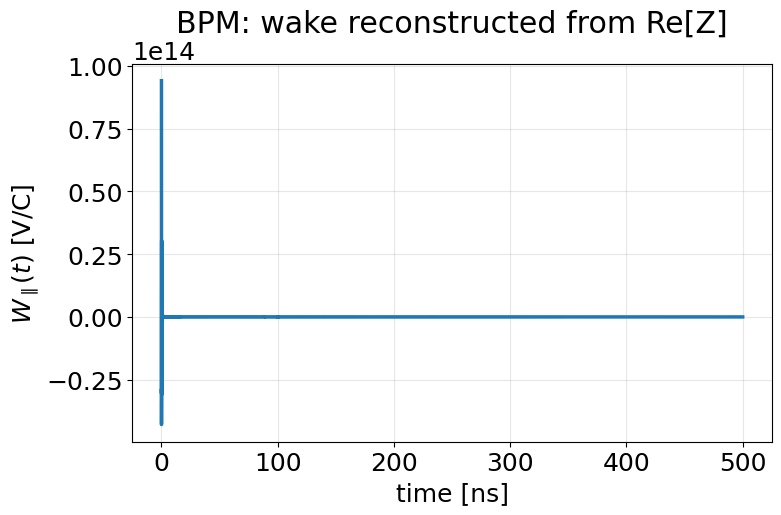

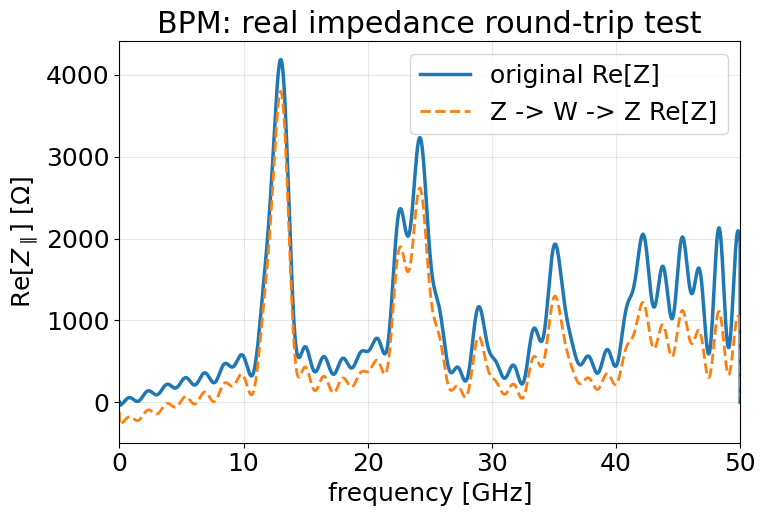

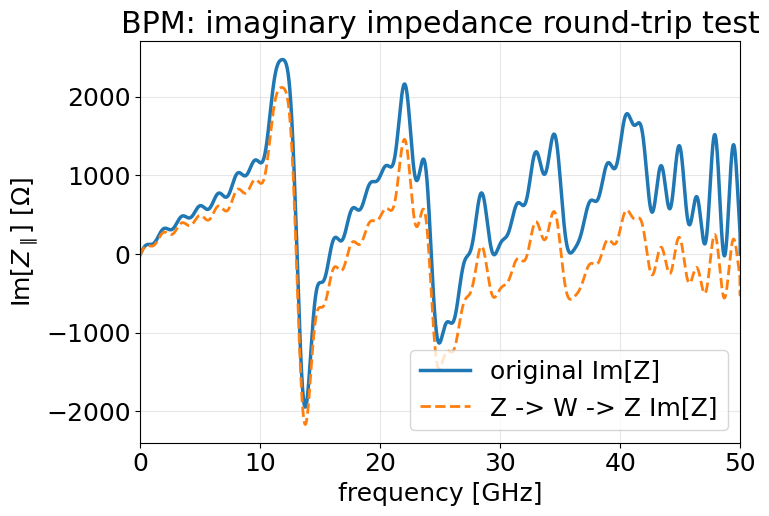

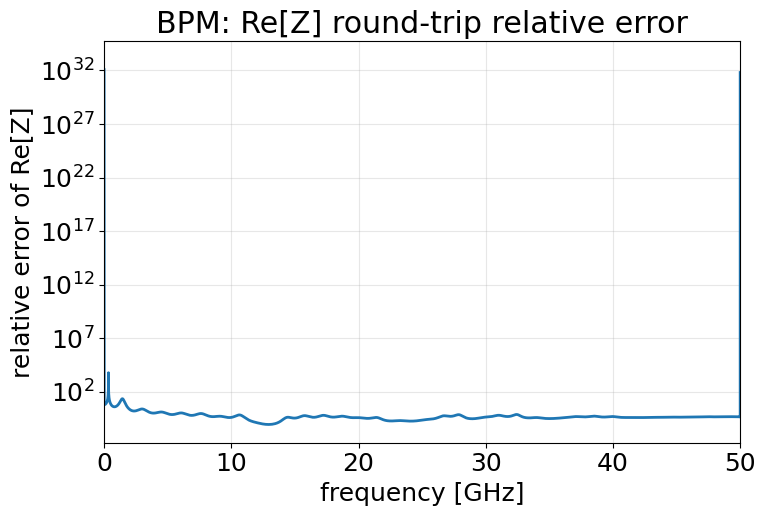

BPM: max |Re error| = 1.886269e+03
BPM: rms |Re error| = 3.988274e+02

===== RF cavities: Z -> W -> Z test =====
* Number of samples = 50001
* Maximum time = 500.000000 ns
* Time resolution = 10.000000 ps
* Relativistic beta = 1.0
* Number of samples = 50000
* Maximum frequency = 99.998000 GHz
* Frequency resolution = 2.000000 MHz
* Relativistic beta = 1.0


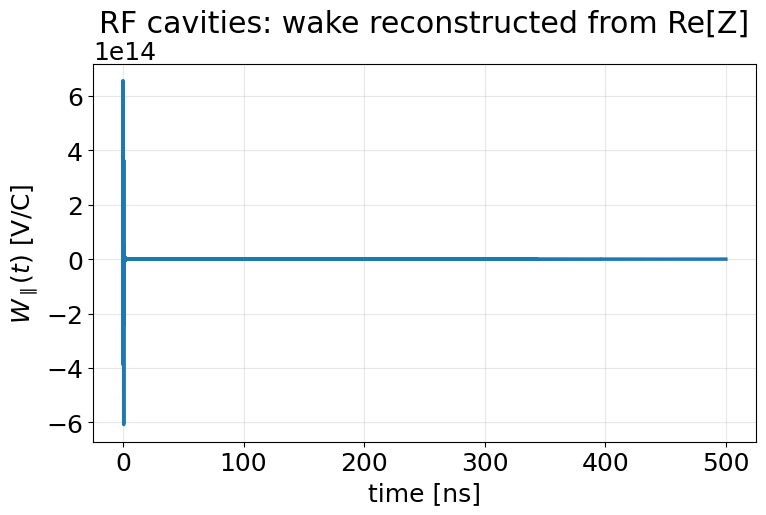

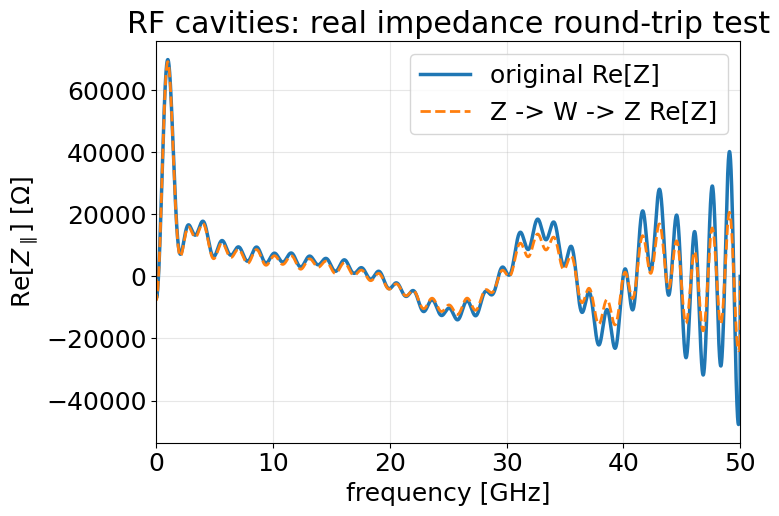

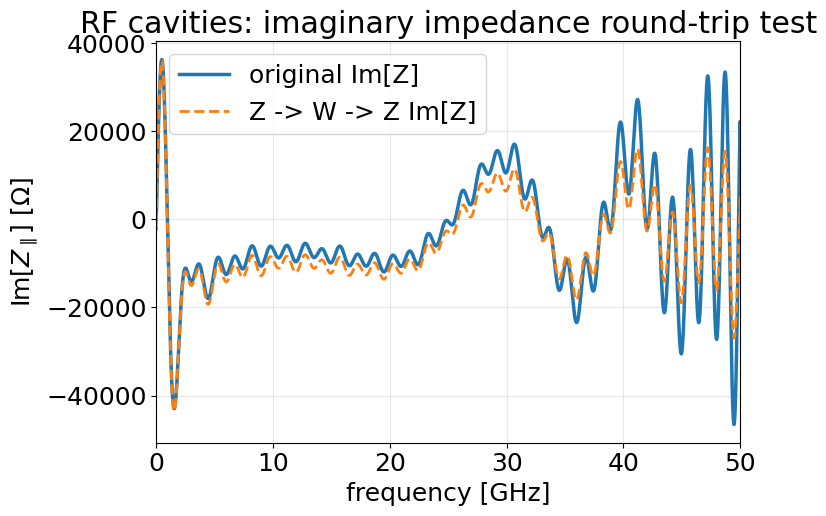

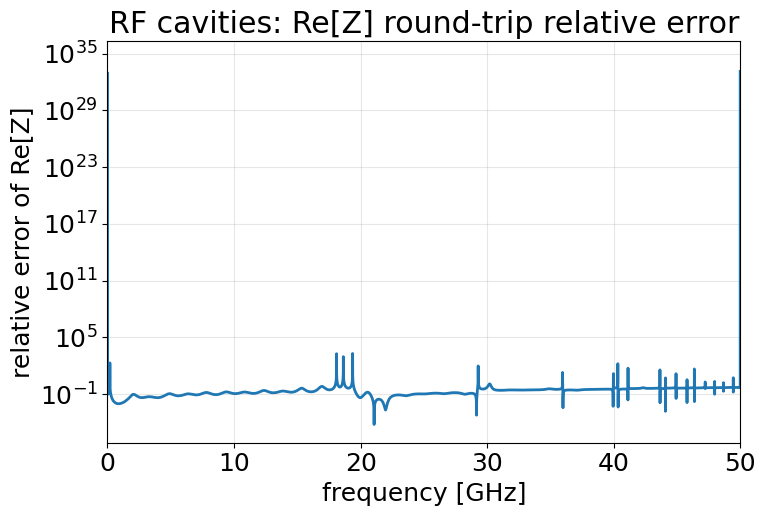

RF cavities: max |Re error| = 3.957877e+04
RF cavities: rms |Re error| = 4.265832e+03

===== Total: Z -> W -> Z test =====
* Number of samples = 50001
* Maximum time = 500.000000 ns
* Time resolution = 10.000000 ps
* Relativistic beta = 1.0
* Number of samples = 50000
* Maximum frequency = 99.998000 GHz
* Frequency resolution = 2.000000 MHz
* Relativistic beta = 1.0


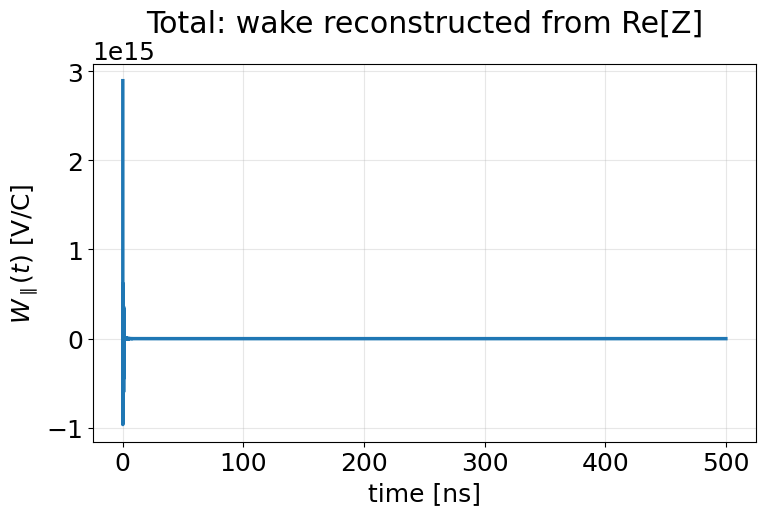

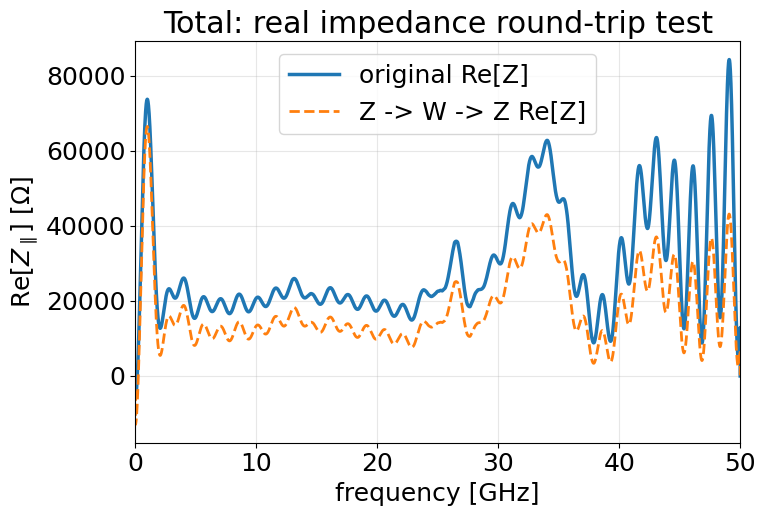

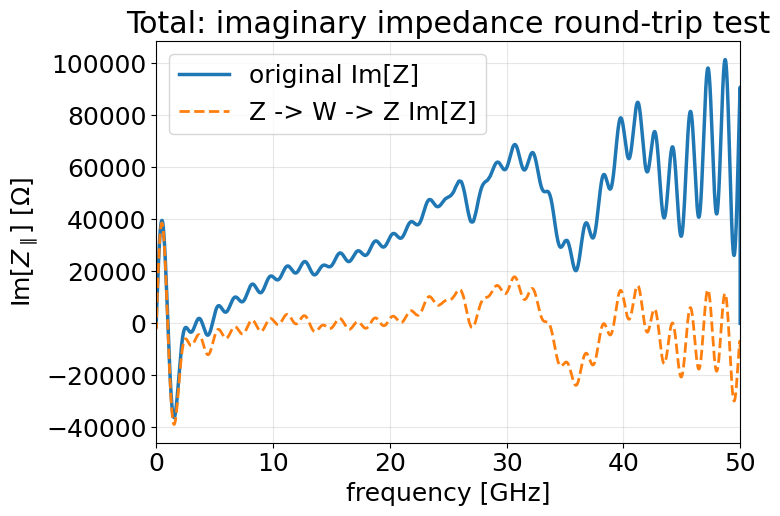

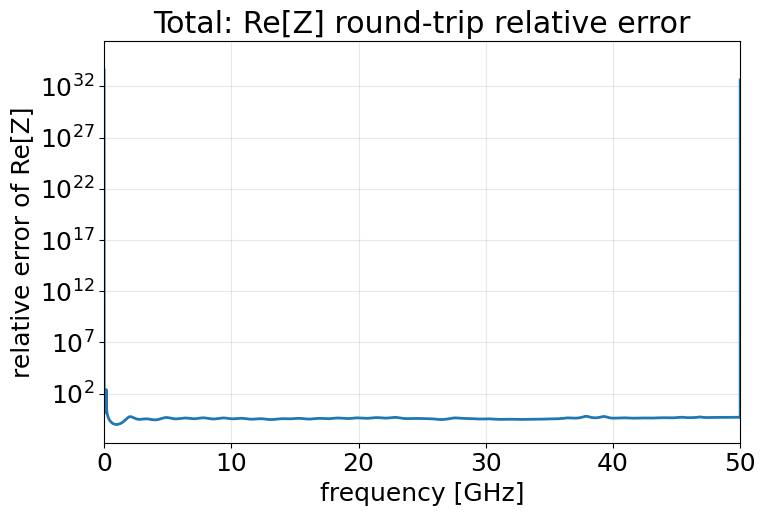

Total: max |Re error| = 4.115688e+04
Total: rms |Re error| = 1.241911e+04


In [24]:
from scipy.fft import ihfft

def calc_impedance_from_wake(
    wake, s=None, t=None, fmax=None, gamma=None,
    samples=None, plane="longitudinal", verbose=True
):
    """
    Calculate impedance from point-charge wake function using FFT.
    """

    if isinstance(wake, list):
        t = np.asarray(wake[0])
        wake = np.asarray(wake[1])

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    if s is not None:
        t = s / (beta * c_light)
    elif s is None and t is None:
        raise AttributeError(
            'Provide time or distance data through parameter "t" [s] or "s" [m]'
        )

    t = np.asarray(t)
    wake = np.asarray(wake)

    dt = np.mean(np.diff(t))

    if fmax is not None:
        aux = np.arange(t.min(), t.max(), 1 / fmax / 2)
        wake = np.interp(aux, t, wake)
        dt = np.mean(np.diff(aux))
        del aux
    else:
        fmax = 1 / dt

    if samples is not None:
        Nf = 2 * samples
        Wfft = np.fft.fft(wake, n=Nf) * dt
    else:
        Nt = len(t)
        Nf = 4 * ((Nt + 1) // 2 - 1)
        Wfft = np.fft.fft(wake, n=Nf) * dt

    if plane.lower() == "longitudinal":
        pass
    elif plane.lower() == "transverse":
        Wfft = 1j * Wfft
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    ffft = np.fft.fftfreq(Nf, dt)

    mask = np.logical_and(ffft >= 0, ffft < fmax)
    f = ffft[mask]
    Z = Wfft[mask]

    f[0] = 0.0
    Z[0] = 0.0 + 0.0j

    if verbose:
        print(f"* Number of samples = {len(f)}")
        print(f"* Maximum frequency = {f.max()/1e9:.6f} GHz")
        print(f"* Frequency resolution = {np.mean(np.diff(f))/1e6:.6f} MHz")
        print(f"* Relativistic beta = {beta}")

    return [f, Z]


def calc_wake_from_impedance(
    impedance, f=None, gamma=None, plane="longitudinal", verbose=True
):
    """
    Calculate point-charge wake function from impedance using ihfft.

    Note:
    For longitudinal plane, this implementation uses only Re[Z].
    Therefore, the Z -> W -> Z test mainly checks Re[Z] consistency.
    """

    if isinstance(impedance, list):
        f = np.asarray(impedance[0])
        Z = np.asarray(impedance[1])
    elif f is None:
        raise AttributeError('Provide frequency data through parameter "f"')
    else:
        Z = np.asarray(impedance)
        f = np.asarray(f)

    if gamma is None:
        beta = 1.0
    else:
        if gamma <= 1.0:
            raise ValueError("gamma must be > 1")
        beta = np.sqrt(1.0 - 1.0 / gamma**2)

    df = np.mean(np.diff(f))
    fmax = np.max(f)

    Nf = len(f)
    Nt = Nf // 2 + 1

    dt = 1.0 / (beta * fmax)
    t = np.arange(Nt) * dt

    if plane.lower() == "longitudinal":
        wake = np.real(ihfft(Z.real, norm="forward")) * 4 * df
    elif plane.lower() == "transverse":
        wake = np.imag(ihfft(Z.real, norm="forward")) * 4 * df
    else:
        raise ValueError("plane must be 'longitudinal' or 'transverse'")

    wake[[0, -1]] *= 0.5

    if verbose:
        print(f"* Number of samples = {Nt}")
        print(f"* Maximum time = {t.max()*1e9:.6f} ns")
        print(f"* Time resolution = {np.mean(np.diff(t))*1e12:.6f} ps")
        print(f"* Relativistic beta = {beta}")

    return [t, wake]


# ---------------------------------------------------------
# Helper: interpolate complex array
# ---------------------------------------------------------

def interp_complex(f_src, Z_src, f_dst):
    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re + 1j * im


# ---------------------------------------------------------
# Helper: Z -> W -> Z test
# ---------------------------------------------------------

def test_impedance_wake_roundtrip(
    f_in,
    Z_in,
    name="component",
    fmax_test=50e9,
    n_freq=5001,
    samples_back=None,
    plane="longitudinal",
):
    """
    Test Z(f) -> W(t) -> Z(f).

    The input impedance is first interpolated to a uniform frequency grid.
    """

    # Uniform frequency grid.
    # Start from a nonzero frequency to avoid possible f=0 singular behavior.
    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)

    Z_uniform = interp_complex(f_in, Z_in, f_uniform)

    # Avoid artificial DC problem.
    Z_uniform[0] = 0.0 + 0.0j

    print(f"\n===== {name}: Z -> W -> Z test =====")

    # Impedance -> wake
    t_wake, W = calc_wake_from_impedance(
        [f_uniform, Z_uniform],
        plane=plane,
        verbose=True,
    )

    # Wake -> impedance
    f_rec, Z_rec = calc_impedance_from_wake(
        [t_wake, W],
        fmax=fmax_test,
        samples=samples_back,
        plane=plane,
        verbose=True,
    )

    # Interpolate reconstructed impedance back to original uniform grid
    Z_rec_i = interp_complex(f_rec, Z_rec, f_uniform)

    return f_uniform, Z_uniform, t_wake, W, f_rec, Z_rec, Z_rec_i


# ---------------------------------------------------------
# Choose component to test
# ---------------------------------------------------------
# You can change this to Zrf_i, Zbpm_i, Zbell_i, Zrw_i, or Ztot.
# Since f_common is already uniform from your budget cell, this works directly.

components_to_test = {
    "RW": Zrw_i,
    "Bellows": Zbell_i,
    "BPM": Zbpm_i,
    "RF cavities": Zrf_i,
    "Total": Ztot,
}


# ---------------------------------------------------------
# Run tests and plot
# ---------------------------------------------------------

roundtrip_results = {}

for name, Zcomp in components_to_test.items():

    f_u, Z_u, t_w, W, f_r, Z_r, Z_r_i = test_impedance_wake_roundtrip(
        f_in=f_common,
        Z_in=Zcomp,
        name=name,
        fmax_test=100e9,
        n_freq=100001,
        samples_back=None,
        plane="longitudinal",
    )

    roundtrip_results[name] = {
        "f_uniform": f_u,
        "Z_uniform": Z_u,
        "t_wake": t_w,
        "W": W,
        "f_rec": f_r,
        "Z_rec": Z_r,
        "Z_rec_interp": Z_r_i,
    }

    # -----------------------------------------------------
    # Plot wake
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(t_w * 1e9, W, linewidth=2.5)
    plt.xlabel("time [ns]")
    plt.ylabel(r"$W_\parallel(t)$ [V/C]")
    plt.title(f"{name}: wake reconstructed from Re[Z]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot real impedance comparison
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(f_u / 1e9, Z_u.real, linewidth=2.5, label="original Re[Z]")
    plt.plot(f_u / 1e9, Z_r_i.real, "--", linewidth=2.0, label="Z -> W -> Z Re[Z]")
    plt.xlabel("frequency [GHz]")
    plt.ylabel(r"Re[$Z_\parallel$] [$\Omega$]")
    plt.title(f"{name}: real impedance round-trip test")
    plt.xlim(0, 50)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot imaginary impedance comparison
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(f_u / 1e9, Z_u.imag, linewidth=2.5, label="original Im[Z]")
    plt.plot(f_u / 1e9, Z_r_i.imag, "--", linewidth=2.0, label="Z -> W -> Z Im[Z]")
    plt.xlabel("frequency [GHz]")
    plt.ylabel(r"Im[$Z_\parallel$] [$\Omega$]")
    plt.title(f"{name}: imaginary impedance round-trip test")
    plt.xlim(0, 50)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot real-part relative error
    # -----------------------------------------------------
    eps = 1e-30
    rel_err_re = np.abs(Z_r_i.real - Z_u.real) / np.maximum(np.abs(Z_u.real), eps)

    plt.figure(figsize=(8, 5.5))
    plt.semilogy(f_u / 1e9, rel_err_re, linewidth=2.0)
    plt.xlabel("frequency [GHz]")
    plt.ylabel("relative error of Re[Z]")
    plt.title(f"{name}: Re[Z] round-trip relative error")
    plt.xlim(0, 50)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"{name}: max |Re error| = {np.max(np.abs(Z_r_i.real - Z_u.real)):.6e}")
    print(f"{name}: rms |Re error| = {np.sqrt(np.mean((Z_r_i.real - Z_u.real)**2)):.6e}")
    


RF cavity
sigma_z = 3.000000 mm
* Z -> W
  Number of frequency samples = 100001
  fmax = 1000.000000 GHz
  df = 9.999900 MHz
  Number of wake samples = 50001
  dt = 1.000000 ps
  tmax = 50.000000 ns
CST wake range: -25.646763 mm to 199.971480 mm
Conv wake range: -14989.622900 mm to 14989.622900 mm
Max abs difference = 5.861299e-01 V/pC
RMS difference     = 1.253910e-01 V/pC


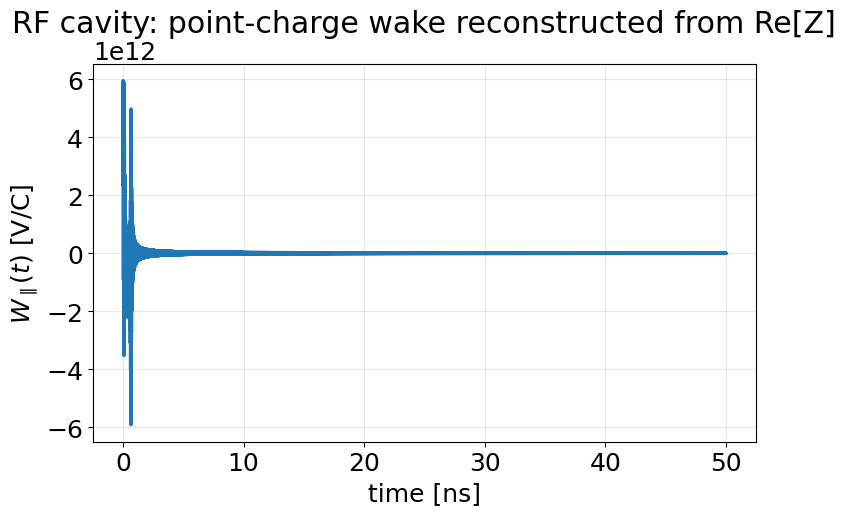

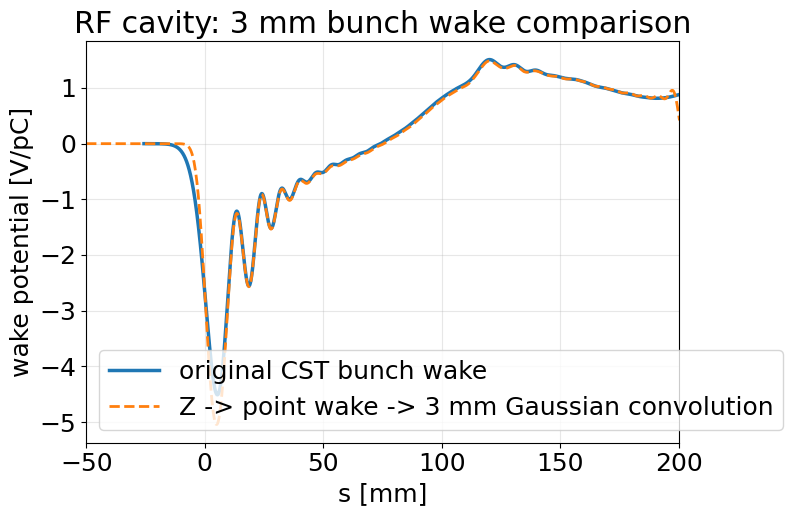

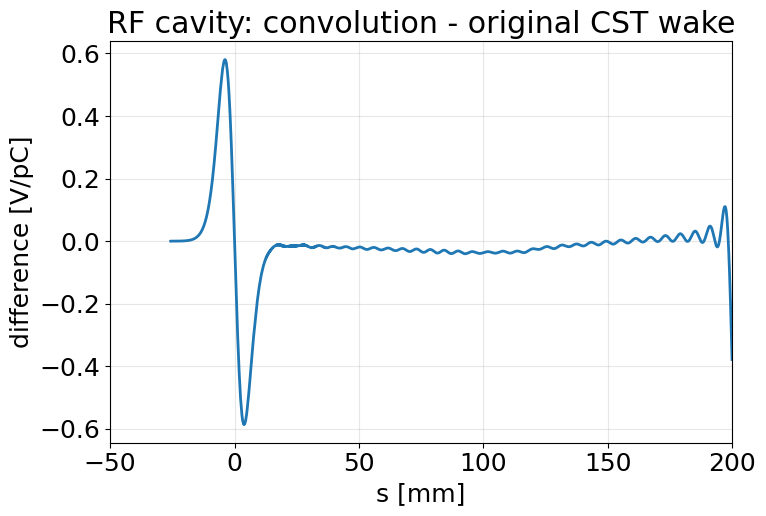


BPM
sigma_z = 3.000000 mm
* Z -> W
  Number of frequency samples = 100001
  fmax = 1000.000000 GHz
  df = 9.999900 MHz
  Number of wake samples = 50001
  dt = 1.000000 ps
  tmax = 50.000000 ns
CST wake range: -25.646763 mm to 199.998600 mm
Conv wake range: -14989.622900 mm to 14989.622900 mm
Max abs difference = 4.179648e-03 V/pC
RMS difference     = 7.374222e-04 V/pC


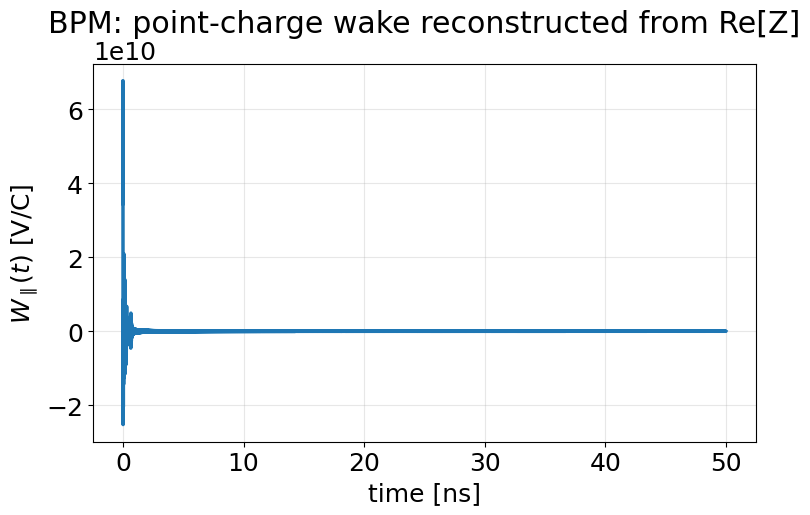

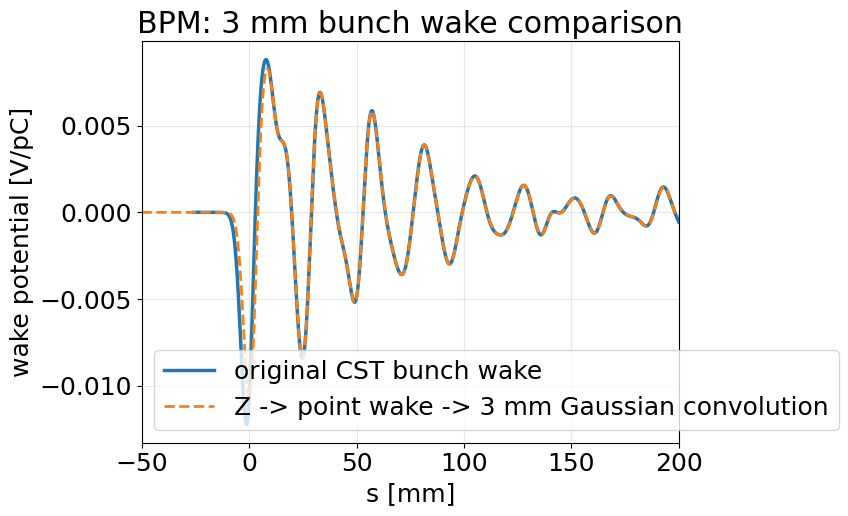

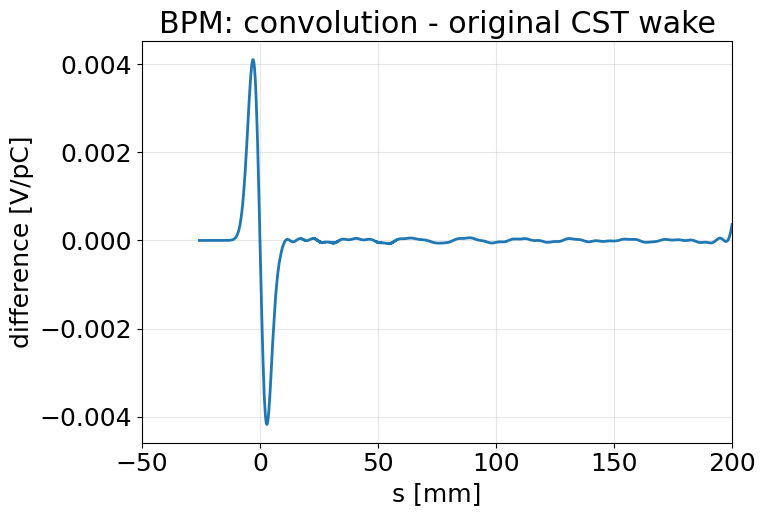

In [70]:
# =========================================================
# NEW CELL: Z -> point-charge wake -> 3 mm bunch wake
# Compare with original CST bunch wake files
#
# Targets:
#   RF:
#     Z_single_rf_cavity_long_filter_3mm.txt
#     W_single_rf_cavity_long_filter_3mm.txt
#
#   BPM:
#     Z_bpm_long_3mm.txt
#     W_bpm_long_3mm.txt
#
# Convention:
#   WP_bunch(t) = - convolution[ W_point(t), lambda(t) ]
# =========================================================

import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c
from scipy.fft import ihfft


# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"

rf_Z_file = os.path.join(
    repo_data,
    "rf_cavities",
    "Z_single_rf_cavity_long_filter_3mm.txt"
)

rf_W_file = os.path.join(
    repo_data,
    "rf_cavities",
    "W_single_rf_cavity_long_filter_3mm.txt"
)

bpm_Z_file = os.path.join(
    repo_data,
    "bpm",
    "Z_bpm_long_3mm.txt"
)

bpm_W_file = os.path.join(
    repo_data,
    "bpm",
    "W_bpm_long_3mm.txt"
)


# ---------------------------------------------------------
# Basic readers
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    """
    Read impedance file with format:

        # Freq(GHz) Re(Z) Im(Z)

    Returns
    -------
    f_hz : ndarray
        Frequency [Hz]
    Z : ndarray
        Complex impedance [Ohm]
    """
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z


def read_wake_file(filepath):
    """
    Read CST wake file with columns:

        s [mm], W [V/pC]

    Ignores comment lines starting with '#'.
    """
    data = np.loadtxt(filepath, comments="#")
    s_mm = data[:, 0]
    W_v_per_pC = data[:, 1]
    return s_mm, W_v_per_pC


def extract_sigma_z_mm(filepath, default_sigma_z_mm=3.0):
    """
    Extract sigma_z from CST header if available.
    If not found, return default_sigma_z_mm.
    """
    try:
        with open(filepath, "r") as f:
            for line in f:
                if "sigma_z" in line:
                    match = re.search(r"sigma_z\s*=\s*([0-9.eE+-]+)", line)
                    if match:
                        return float(match.group(1))
    except Exception:
        pass

    print(
        f"Could not find sigma_z in header of:\n{filepath}\n"
        f"Using default sigma_z = {default_sigma_z_mm:.6f} mm"
    )
    return default_sigma_z_mm


def interp_complex(f_src, Z_src, f_dst):
    re = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re + 1j * im


# ---------------------------------------------------------
# Z -> point-charge wake
# This follows the logic of your calc_wake_from_impedance().
# For longitudinal wake, this uses Re[Z].
# ---------------------------------------------------------
def calc_long_wake_from_long_Z(
    impedance,
    f=None,
    fmax_test=1000e9,
    n_freq=100001,
    verbose=True,
):
    """
    Calculate longitudinal point-charge wake from longitudinal impedance.

    Parameters
    ----------
    impedance : list or ndarray
        If list, use [f, Z].
        Otherwise, pass Z and provide f separately.
    fmax_test : float
        Frequency grid maximum used for inverse transform.
        If the input impedance only goes to 50 GHz, values above 50 GHz
        are zero-filled by interpolation.
    n_freq : int
        Number of positive-frequency samples.

    Returns
    -------
    t : ndarray
        Time array [s], starting from 0.
    W : ndarray
        Point-charge wake [V/C].
    f_uniform : ndarray
        Uniform frequency grid [Hz].
    Z_uniform : ndarray
        Interpolated impedance on f_uniform [Ohm].
    """

    if isinstance(impedance, list):
        f_in = np.asarray(impedance[0])
        Z_in = np.asarray(impedance[1])
    else:
        if f is None:
            raise AttributeError("Provide frequency array f.")
        f_in = np.asarray(f)
        Z_in = np.asarray(impedance)

    # Uniform positive-frequency grid.
    # Start from nonzero frequency to avoid DC ambiguity.
    f_uniform = np.linspace(fmax_test / n_freq, fmax_test, n_freq)
    Z_uniform = interp_complex(f_in, Z_in, f_uniform)

    # Avoid artificial DC problem.
    Z_uniform[0] = 0.0 + 0.0j

    df = np.mean(np.diff(f_uniform))
    fmax = np.max(f_uniform)

    Nf = len(f_uniform)
    Nt = Nf // 2 + 1

    dt = 1.0 / fmax
    t = np.arange(Nt) * dt

    # Same convention as your previous cell:
    # longitudinal wake is reconstructed from Re[Z].
    W = np.real(ihfft(Z_uniform.real, norm="forward")) * 4.0 * df

    # Half-weight at boundaries.
    W[[0, -1]] *= 0.5

    if verbose:
        print("* Z -> W")
        print(f"  Number of frequency samples = {Nf}")
        print(f"  fmax = {fmax / 1e9:.6f} GHz")
        print(f"  df = {df / 1e6:.6f} MHz")
        print(f"  Number of wake samples = {Nt}")
        print(f"  dt = {dt * 1e12:.6f} ps")
        print(f"  tmax = {t[-1] * 1e9:.6f} ns")

    return t, W, f_uniform, Z_uniform


# ---------------------------------------------------------
# Point-charge wake -> 3 mm bunch wake by convolution
# ---------------------------------------------------------
def convolve_point_wake_with_gaussian(
    t_point,
    W_point,
    sigma_z_mm=3.0,
):
    """
    Convolve point-charge wake with Gaussian bunch profile.

    Uses the same padding/convolution convention you provided:

        W_point_pad = 0 for t < 0
        lambda_t defined on the padded symmetric time grid
        WP_conv = -convolve(W_point_pad, lambda_t, mode="same") * dt

    Returns
    -------
    t_pad : ndarray
        Padded time array [s].
    s_pad_mm : ndarray
        Padded distance array [mm].
    WP_conv_v_per_pC : ndarray
        Bunch wake potential [V/pC].
    lambda_t : ndarray
        Gaussian bunch profile [1/s].
    W_point_pad : ndarray
        Padded point-charge wake [V/C].
    """

    sigma_t = sigma_z_mm * 1e-3 / c

    N = len(t_point)
    dt = np.mean(np.diff(t_point))

    # Symmetric time grid:
    # index N-1 corresponds to t = 0.
    t_pad = np.arange(-(N - 1), N) * dt

    W_point_pad = np.zeros_like(t_pad)
    W_point_pad[N - 1:] = W_point

    lambda_t = (
        1.0 / (sigma_t * np.sqrt(2.0 * np.pi))
        * np.exp(-0.5 * (t_pad / sigma_t) ** 2)
    )

    WP_conv = -np.convolve(W_point_pad, lambda_t, mode="same") * dt

    # V/C -> V/pC
    WP_conv_v_per_pC = WP_conv * 1e-12

    s_pad_mm = t_pad * c * 1e3

    return t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad


# ---------------------------------------------------------
# Main test function for one component
# ---------------------------------------------------------
def process_component(
    name,
    Z_file,
    W_file,
    fmax_test=1000e9,
    n_freq=100001,
    default_sigma_z_mm=3.0,
    xlim_mm=(-50, 200),
):
    print("\n" + "=" * 80)
    print(f"{name}")
    print("=" * 80)

    # Read impedance
    f_Z, Z = read_impedance_file_ghz(Z_file)

    # Read original CST bunch wake
    s_cst_mm, W_cst_v_per_pC = read_wake_file(W_file)

    # Get sigma_z
    sigma_z_mm = extract_sigma_z_mm(W_file, default_sigma_z_mm=default_sigma_z_mm)
    print(f"sigma_z = {sigma_z_mm:.6f} mm")

    # Z -> point-charge wake
    t_point, W_point, f_uniform, Z_uniform = calc_long_wake_from_long_Z(
        [f_Z, Z],
        fmax_test=fmax_test,
        n_freq=n_freq,
        verbose=True,
    )

    # Point-charge wake -> bunch wake
    t_pad, s_pad_mm, WP_conv_v_per_pC, lambda_t, W_point_pad = (
        convolve_point_wake_with_gaussian(
            t_point=t_point,
            W_point=W_point,
            sigma_z_mm=sigma_z_mm,
        )
    )

    # Interpolate convolution result onto CST s-grid for direct comparison
    WP_conv_on_cst = np.interp(
        s_cst_mm,
        s_pad_mm,
        WP_conv_v_per_pC,
        left=0.0,
        right=0.0,
    )

    diff = WP_conv_on_cst - W_cst_v_per_pC

    print(f"CST wake range: {s_cst_mm[0]:.6f} mm to {s_cst_mm[-1]:.6f} mm")
    print(f"Conv wake range: {s_pad_mm[0]:.6f} mm to {s_pad_mm[-1]:.6f} mm")
    print(f"Max abs difference = {np.max(np.abs(diff)):.6e} V/pC")
    print(f"RMS difference     = {np.sqrt(np.mean(diff**2)):.6e} V/pC")

    # -----------------------------------------------------
    # Plot point-charge wake
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(t_point * 1e9, W_point, linewidth=2.5)
    plt.xlabel("time [ns]")
    plt.ylabel(r"$W_\parallel(t)$ [V/C]")
    plt.title(f"{name}: point-charge wake reconstructed from Re[Z]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot bunch wake comparison
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(
        s_cst_mm,
        W_cst_v_per_pC,
        linewidth=2.5,
        label="original CST bunch wake",
    )
    plt.plot(
        s_pad_mm,
        WP_conv_v_per_pC,
        "--",
        linewidth=2.0,
        label="Z -> point wake -> 3 mm Gaussian convolution",
    )

    plt.xlabel("s [mm]")
    plt.ylabel("wake potential [V/pC]")
    plt.title(f"{name}: 3 mm bunch wake comparison")
    plt.xlim(*xlim_mm)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Plot difference on CST grid
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))
    plt.plot(s_cst_mm, diff, linewidth=2.0)
    plt.xlabel("s [mm]")
    plt.ylabel("difference [V/pC]")
    plt.title(f"{name}: convolution - original CST wake")
    plt.xlim(*xlim_mm)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "name": name,
        "f_Z": f_Z,
        "Z": Z,
        "f_uniform": f_uniform,
        "Z_uniform": Z_uniform,
        "t_point": t_point,
        "W_point": W_point,
        "t_pad": t_pad,
        "s_pad_mm": s_pad_mm,
        "WP_conv_v_per_pC": WP_conv_v_per_pC,
        "s_cst_mm": s_cst_mm,
        "W_cst_v_per_pC": W_cst_v_per_pC,
        "WP_conv_on_cst": WP_conv_on_cst,
        "diff": diff,
        "sigma_z_mm": sigma_z_mm,
    }


# ---------------------------------------------------------
# Run RF and BPM tests
# ---------------------------------------------------------
results_rf = process_component(
    name="RF cavity",
    Z_file=rf_Z_file,
    W_file=rf_W_file,
    fmax_test=1000e9,
    n_freq=100001,
    default_sigma_z_mm=3.0,
    xlim_mm=(-50, 200),
)

results_bpm = process_component(
    name="BPM",
    Z_file=bpm_Z_file,
    W_file=bpm_W_file,
    fmax_test=1000e9,
    n_freq=100001,
    default_sigma_z_mm=3.0,
    xlim_mm=(-50, 200),
)

RW length correction:
  Circumference       = 90644.836000 m
  Number of bellows   = 10000
  Bellows length      = 0.150000 m
  Removed RW length   = 1500.000000 m
  Effective RW length = 89144.836000 m
  RW scaling factor   = 9.834518979106e-01

Dimensionless transverse beta-weighting factors:
  RF x      = 269.14961329031115
  RF y      = 67.4923993513564
  BPM x     = 3018.757133548228
  BPM y     = 2867.8735507454576
  Bellows x = 1.0
  Bellows y = 1.0

Transverse dipolar impedance budget: x-plane
Files:
  RF      : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/Z_single_rf_cavity_dipx_filter_3mm.txt
  BPM     : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/Z_bpm_dipx_3mm.txt
  Bellows : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_dipx.txt

Applied dimensionless factors:
  RF      = 2.691496132903e+02
  BPM     = 3.018757133548e+03
  Bellows = 

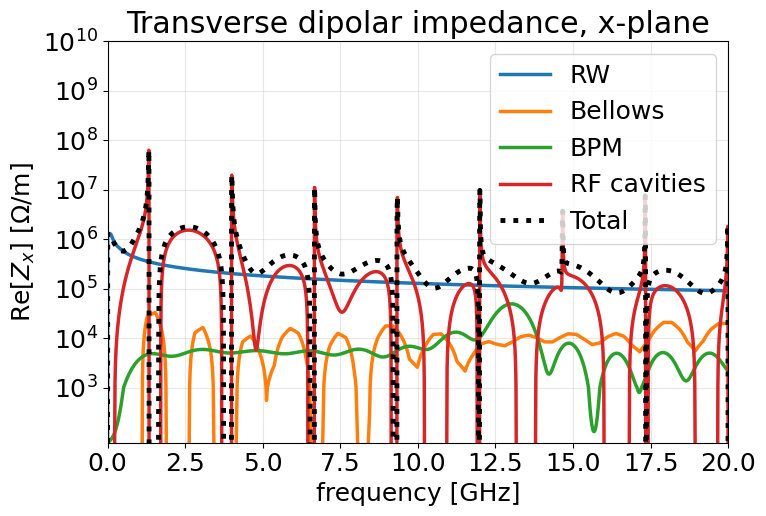

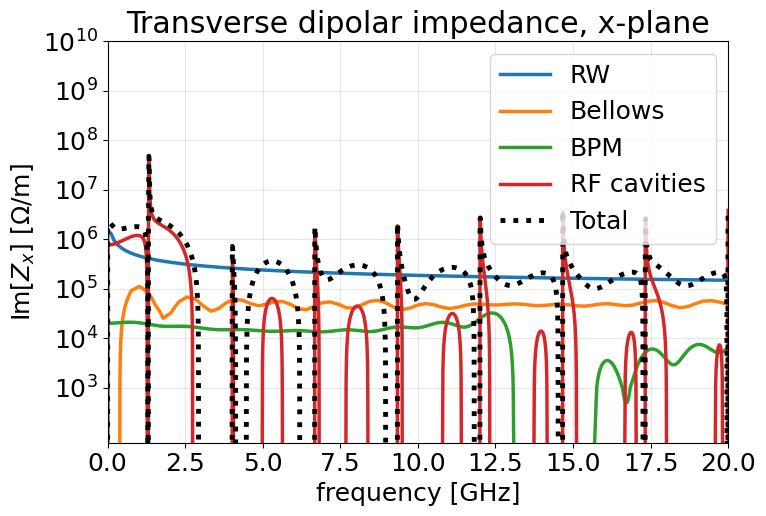


Transverse dipolar impedance budget: y-plane
Files:
  RF      : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/rf_cavities/Z_single_rf_cavity_dipy_filter_3mm.txt
  BPM     : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bpm/Z_bpm_dipy_3mm.txt
  Bellows : /home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data/bellows/Z_bellows_dipy.txt

Applied dimensionless factors:
  RF      = 6.749239935136e+01
  BPM     = 2.867873550745e+03
  Bellows = 1.000000000000e+00

Component summary at 20 GHz:
  RW      = (91338.36739253672+148957.97280186013j)
  Bellows = (14278.69+44848.18j)
  BPM     = (2088.35942200353+6145.437177582658j)
  RF      = (-162253.55033544326+965621.8566077782j)
  TOTAL   = (-54548.13352090301+1165573.446587221j)


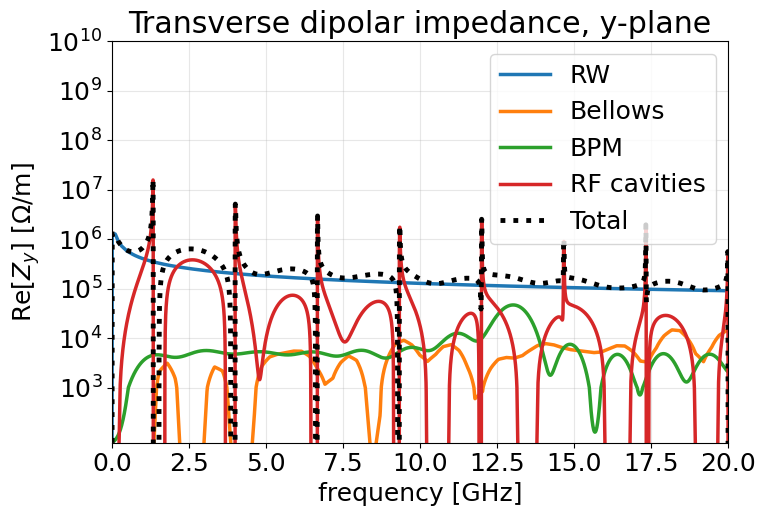

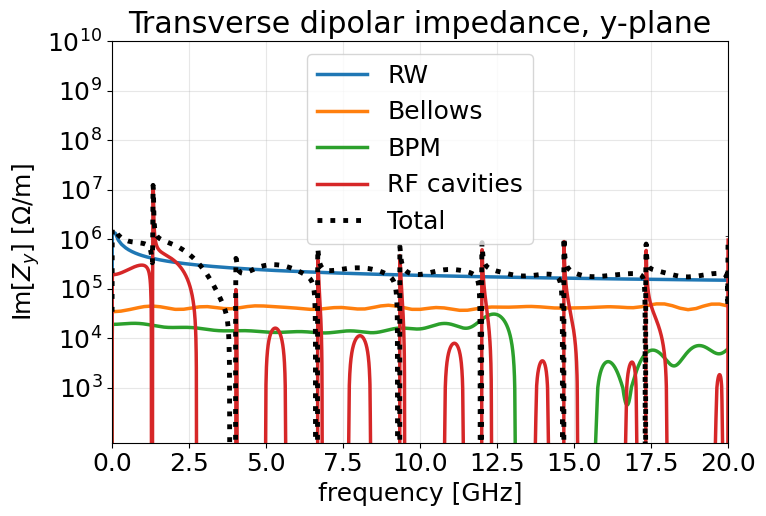


Done.
Stored results in:
  transverse_impedance_budget['x']
  transverse_impedance_budget['y']


In [32]:
# =========================================================
# NEW CELL: Transverse dipolar impedance budget up to 20 GHz
# for both x- and y-planes
#
# Uses:
#   - existing RW impedances already in memory:
#       freq_x, Zx_C
#       freq_y, Zy_C
#
#   - existing impedance files for RF / BPM / Bellows:
#       x-plane: *_dipx*
#       y-plane: *_dipy*
#
# Logic:
#   RW:
#     use Zx_C / Zy_C, but subtract the bellows-occupied length
#
#   RF:
#     use dimensionless beta-weighting factors:
#       model_iw2d.rf_beta_factor_x
#       model_iw2d.rf_beta_factor_y
#
#   BPM:
#     use dimensionless beta-weighting factors:
#       model_iw2d.bpm_beta_factor_x
#       model_iw2d.bpm_beta_factor_y
#
#   Bellows:
#     use average beta, so factor = 1
#     bellows file is assumed to already include total bellows count
#
# Units:
#   Z_perp in Ohm/m
#
# Legend:
#   Do not show component numbers.
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Check required variables
# ---------------------------------------------------------
required_vars = [
    "freq_x", "freq_y",
    "Zx_C", "Zy_C",
    "model_iw2d",
]

for var in required_vars:
    if var not in globals():
        raise NameError(
            f"{var} is not defined. "
            "Please run the previous RW impedance and HEBModel cells first."
        )


# ---------------------------------------------------------
# Base data folder
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"


# ---------------------------------------------------------
# Bellows settings
# ---------------------------------------------------------
n_bellows = 10000
L_bellows = 0.15   # [m] per bellows


# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000


# ---------------------------------------------------------
# Helper: read impedance file
# Format:
#   # Freq(GHz) Re(Z) Im(Z)
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Impedance file does not exist:\n{filepath}")

    data = np.loadtxt(filepath, comments="#")

    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]

    return f_hz, Z


# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)

    return re_part + 1j * im_part


# ---------------------------------------------------------
# Bellows length subtraction for RW
# ---------------------------------------------------------
C_ring = model_iw2d.circ

L_remove = n_bellows * L_bellows
L_rw_effective = C_ring - L_remove

if L_rw_effective < 0:
    raise ValueError(
        f"Effective RW length became negative:\n"
        f"  C_ring   = {C_ring:.12e} m\n"
        f"  L_remove = {L_remove:.12e} m\n"
        f"  L_eff    = {L_rw_effective:.12e} m"
    )

rw_scale = L_rw_effective / C_ring

print("RW length correction:")
print(f"  Circumference       = {C_ring:.6f} m")
print(f"  Number of bellows   = {n_bellows}")
print(f"  Bellows length      = {L_bellows:.6f} m")
print(f"  Removed RW length   = {L_remove:.6f} m")
print(f"  Effective RW length = {L_rw_effective:.6f} m")
print(f"  RW scaling factor   = {rw_scale:.12e}")


# ---------------------------------------------------------
# Component beta-weighting factors
# These already include component counts for RF and BPM.
# ---------------------------------------------------------
beta_factors = {
    "x": {
        "rf": model_iw2d.rf_beta_factor_x,
        "bpm": model_iw2d.bpm_beta_factor_x,
        "bellows": model_iw2d.bellows_beta_factor_x,
    },
    "y": {
        "rf": model_iw2d.rf_beta_factor_y,
        "bpm": model_iw2d.bpm_beta_factor_y,
        "bellows": model_iw2d.bellows_beta_factor_y,
    },
}

print("\nDimensionless transverse beta-weighting factors:")
print(f"  RF x      = {beta_factors['x']['rf']}")
print(f"  RF y      = {beta_factors['y']['rf']}")
print(f"  BPM x     = {beta_factors['x']['bpm']}")
print(f"  BPM y     = {beta_factors['y']['bpm']}")
print(f"  Bellows x = {beta_factors['x']['bellows']}")
print(f"  Bellows y = {beta_factors['y']['bellows']}")


# ---------------------------------------------------------
# File path builder
# ---------------------------------------------------------
def get_transverse_files(plane):
    """
    plane = "x" or "y"
    """

    suffix = f"dip{plane}"

    rf_file = os.path.join(
        repo_data,
        "rf_cavities",
        # f"Z_single_rf_cavity_{suffix}_3mm.txt",
        f"Z_single_rf_cavity_{suffix}_filter_3mm.txt",
    )

    bpm_file = os.path.join(
        repo_data,
        "bpm",
        f"Z_bpm_{suffix}_3mm.txt",
    )

    bellows_file = os.path.join(
        repo_data,
        "bellows",
        f"Z_bellows_{suffix}.txt",
    )

    return rf_file, bpm_file, bellows_file


# ---------------------------------------------------------
# One-plane transverse impedance budget
# ---------------------------------------------------------
def calculate_transverse_impedance_budget_one_plane(plane):
    """
    plane = "x" or "y"

    Returns a dictionary with common frequency grid and all components.
    """

    if plane not in ["x", "y"]:
        raise ValueError("plane must be 'x' or 'y'.")

    print("\n" + "=" * 80)
    print(f"Transverse dipolar impedance budget: {plane}-plane")
    print("=" * 80)

    # -----------------------------------------------------
    # Select RW impedance
    # -----------------------------------------------------
    if plane == "x":
        freq_rw_full = np.array(freq_x)
        Zrw_full_ring = np.array(Zx_C, dtype=complex)
    else:
        freq_rw_full = np.array(freq_y)
        Zrw_full_ring = np.array(Zy_C, dtype=complex)

    Zrw_budget = rw_scale * Zrw_full_ring

    # -----------------------------------------------------
    # Read geometric component impedances
    # -----------------------------------------------------
    rf_file, bpm_file, bellows_file = get_transverse_files(plane)

    freq_rf, Zrf_single = read_impedance_file_ghz(rf_file)
    freq_bpm, Zbpm_single = read_impedance_file_ghz(bpm_file)
    freq_bell, Zbell_input = read_impedance_file_ghz(bellows_file)

    # -----------------------------------------------------
    # Apply dimensionless beta factors
    #
    # RF/BPM factors already include component counts.
    # Bellows factor = 1 if the file already includes total bellows count.
    # -----------------------------------------------------
    rf_factor = beta_factors[plane]["rf"]
    bpm_factor = beta_factors[plane]["bpm"]
    bellows_factor = beta_factors[plane]["bellows"]

    Zrf_budget = rf_factor * Zrf_single
    Zbpm_budget = bpm_factor * Zbpm_single
    Zbell_budget = bellows_factor * Zbell_input

    # -----------------------------------------------------
    # Interpolate to common grid
    # -----------------------------------------------------
    f_common = np.linspace(0.0, f_plot_max, n_interp)

    Zrw_i = interp_complex(freq_rw_full, Zrw_budget, f_common)
    Zrf_i = interp_complex(freq_rf, Zrf_budget, f_common)
    Zbpm_i = interp_complex(freq_bpm, Zbpm_budget, f_common)
    Zbell_i = interp_complex(freq_bell, Zbell_budget, f_common)

    Ztot = Zrw_i + Zrf_i + Zbpm_i + Zbell_i

    # -----------------------------------------------------
    # Print summary
    # -----------------------------------------------------
    print("Files:")
    print(f"  RF      : {rf_file}")
    print(f"  BPM     : {bpm_file}")
    print(f"  Bellows : {bellows_file}")

    print("\nApplied dimensionless factors:")
    print(f"  RF      = {rf_factor:.12e}")
    print(f"  BPM     = {bpm_factor:.12e}")
    print(f"  Bellows = {bellows_factor:.12e}")

    print("\nComponent summary at 20 GHz:")
    print(f"  RW      = {Zrw_i[-1]}")
    print(f"  Bellows = {Zbell_i[-1]}")
    print(f"  BPM     = {Zbpm_i[-1]}")
    print(f"  RF      = {Zrf_i[-1]}")
    print(f"  TOTAL   = {Ztot[-1]}")

    return {
        "plane": plane,
        "f_common": f_common,
        "Zrw_i": Zrw_i,
        "Zrf_i": Zrf_i,
        "Zbpm_i": Zbpm_i,
        "Zbell_i": Zbell_i,
        "Ztot": Ztot,
        "rf_factor": rf_factor,
        "bpm_factor": bpm_factor,
        "bellows_factor": bellows_factor,
        "rw_scale": rw_scale,
        "rf_file": rf_file,
        "bpm_file": bpm_file,
        "bellows_file": bellows_file,
    }


# ---------------------------------------------------------
# Plot helper
# ---------------------------------------------------------
def plot_transverse_budget(result):
    plane = result["plane"]
    f_common = result["f_common"]

    Zrw_i = result["Zrw_i"]
    Zrf_i = result["Zrf_i"]
    Zbpm_i = result["Zbpm_i"]
    Zbell_i = result["Zbell_i"]
    Ztot = result["Ztot"]

    # -----------------------------------------------------
    # Real part
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))

    plt.plot(f_common / 1e9, Zrw_i.real, linewidth=2.5, label="RW")
    plt.plot(f_common / 1e9, Zbell_i.real, linewidth=2.5, label="Bellows")
    plt.plot(f_common / 1e9, Zbpm_i.real, linewidth=2.5, label="BPM")
    plt.plot(f_common / 1e9, Zrf_i.real, linewidth=2.5, label="RF cavities")
    plt.plot(f_common / 1e9, Ztot.real, ":", color="black", linewidth=3.5, label="Total")

    plt.xlabel("frequency [GHz]")
    plt.ylabel(rf"Re[$Z_{plane}$] [$\Omega$/m]")
    plt.title(f"Transverse dipolar impedance, {plane}-plane")
    plt.xlim(0, 20)
    plt.ylim(1, 1e10)
    plt.yscale("symlog", linthresh=1e3)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Imaginary part
    # -----------------------------------------------------
    plt.figure(figsize=(8, 5.5))

    plt.plot(f_common / 1e9, Zrw_i.imag, linewidth=2.5, label="RW")
    plt.plot(f_common / 1e9, Zbell_i.imag, linewidth=2.5, label="Bellows")
    plt.plot(f_common / 1e9, Zbpm_i.imag, linewidth=2.5, label="BPM")
    plt.plot(f_common / 1e9, Zrf_i.imag, linewidth=2.5, label="RF cavities")
    plt.plot(f_common / 1e9, Ztot.imag, ":", color="black", linewidth=3.5, label="Total")

    plt.xlabel("frequency [GHz]")
    plt.ylabel(rf"Im[$Z_{plane}$] [$\Omega$/m]")
    plt.title(f"Transverse dipolar impedance, {plane}-plane")
    plt.xlim(0, 20)
    plt.ylim(1, 1e10)
    plt.yscale("symlog", linthresh=1e3)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# Run both planes
# ---------------------------------------------------------
transverse_budget_x = calculate_transverse_impedance_budget_one_plane("x")
plot_transverse_budget(transverse_budget_x)

transverse_budget_y = calculate_transverse_impedance_budget_one_plane("y")
plot_transverse_budget(transverse_budget_y)


# ---------------------------------------------------------
# Optional: save combined arrays for later use
# ---------------------------------------------------------
transverse_impedance_budget = {
    "x": transverse_budget_x,
    "y": transverse_budget_y,
}

print("\nDone.")
print("Stored results in:")
print("  transverse_impedance_budget['x']")
print("  transverse_impedance_budget['y']")

Circumference       = 90658.713761 m
Removed RW length   = 1500.000000 m
Effective RW length = 89158.713761 m
RW scaling factor   = 0.983454


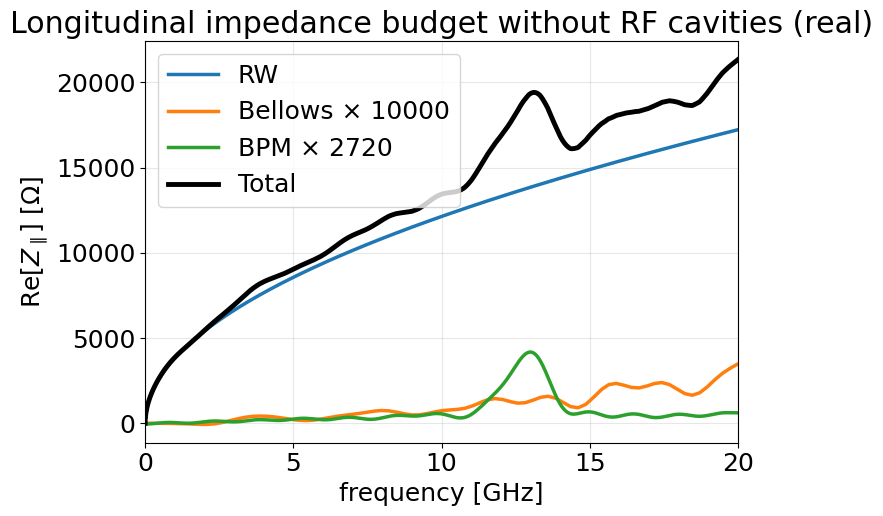

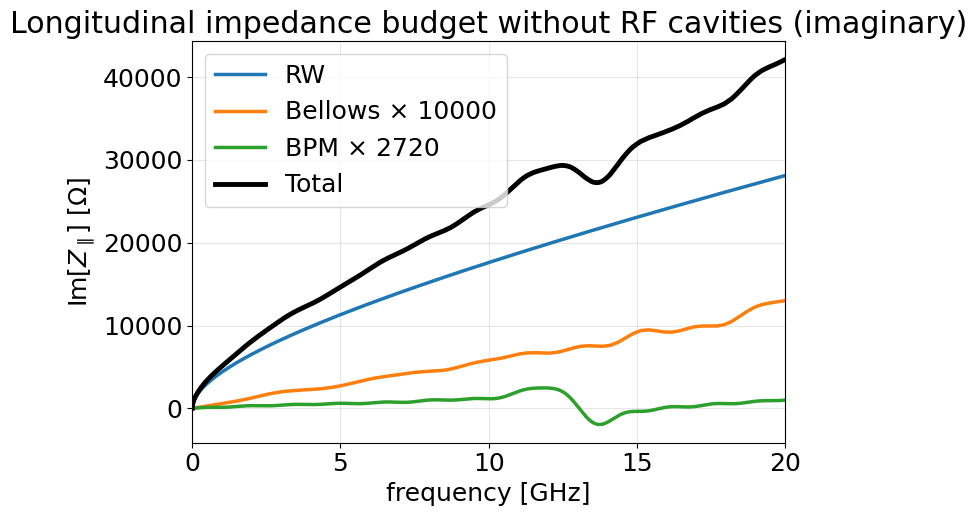


Component summary at 20 GHz:
RW (reduced) = (17229.74604049542+28110.967277094824j)
Bellows      = (3491.987+13013.09j)
BPM          = (621.7092610000001+996.3509652307691j)
TOTAL        = (21343.442301495423+42120.40824232559j)


In [14]:
# =========================================================
# NEW CELL: Longitudinal impedance budget up to 20 GHz
# Case with NO RF cavities
# Uses:
#   - existing RW impedance already in memory: freq_z, Zz_C
#   - existing impedance files for BPM / bellows
# No new impedance calculation here
#
# IMPORTANT:
#   Z_bellows_long.txt is already multiplied by 10000
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Check required variables from previous cells
# ---------------------------------------------------------
if 'freq_z' not in globals() or 'Zz_C' not in globals():
    raise NameError(
        "freq_z and Zz_C are not defined. "
        "Please run your previous RW impedance cell first."
    )

if 'model_iw2d' not in globals():
    raise NameError(
        "model_iw2d is not defined. "
        "Please run the cell where HEBModel is built first."
    )

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"

bpm_file = os.path.join(repo_data, "bpm", "Z_bpm_long_3mm.txt")
bellows_file = os.path.join(repo_data, "bellows", "Z_bellows_long.txt")

# ---------------------------------------------------------
# Budget numbers
# ---------------------------------------------------------
n_bpm = 2720 #3344
n_bellows = 10000
L_bellows = 0.15   # [m] per bellows

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000

# ---------------------------------------------------------
# Helper: read impedance file
# format:
#   # Freq(GHz) Re(Z) Im(Z)
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# 1) RW impedance already computed in previous cell
#    freq_z : frequency array [Hz]
#    Zz_C   : full-ring RW longitudinal impedance
# ---------------------------------------------------------
freq_rw_full = np.array(freq_z)
Zrw_full_ring = np.array(Zz_C)

# Bellows already include their own RW, so remove that RW length
C_ring = model_iw2d.circ
L_remove = n_bellows * L_bellows
L_rw_effective = C_ring - L_remove

if L_rw_effective < 0:
    raise ValueError(
        f"Effective RW length became negative: C={C_ring}, removed={L_remove}"
    )

rw_scale = L_rw_effective / C_ring
Zrw_budget = rw_scale * Zrw_full_ring

print(f"Circumference       = {C_ring:.6f} m")
print(f"Removed RW length   = {L_remove:.6f} m")
print(f"Effective RW length = {L_rw_effective:.6f} m")
print(f"RW scaling factor   = {rw_scale:.6f}")

# ---------------------------------------------------------
# 2) Read already-prepared impedance files
# ---------------------------------------------------------
freq_bpm, Zbpm = read_impedance_file_ghz(bpm_file)
freq_bell, Zbell = read_impedance_file_ghz(bellows_file)

# Multiply by number of components
Zbpm_budget = n_bpm * Zbpm

# IMPORTANT:
# bellows file is already multiplied by 10000
Zbell_budget = Zbell

# ---------------------------------------------------------
# 3) Interpolate to common grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Zrw_i   = interp_complex(freq_rw_full, Zrw_budget, f_common)
Zbpm_i  = interp_complex(freq_bpm, Zbpm_budget, f_common)
Zbell_i = interp_complex(freq_bell, Zbell_budget, f_common)

Ztot = Zrw_i + Zbpm_i + Zbell_i

# ---------------------------------------------------------
# 4) Plot real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Zrw_i.real,   linewidth=2.5, label='RW')
plt.plot(f_common/1e9, Zbell_i.real, linewidth=2.5, label='Bellows × 10000')
plt.plot(f_common/1e9, Zbpm_i.real,  linewidth=2.5, label='BPM × 2720')
plt.plot(f_common/1e9, Ztot.real,    color='black', linewidth=3.5, label='Total')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_\parallel$] [$\Omega$]')
plt.title('Longitudinal impedance budget without RF cavities (real)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5) Plot imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Zrw_i.imag,   linewidth=2.5, label='RW')
plt.plot(f_common/1e9, Zbell_i.imag, linewidth=2.5, label='Bellows × 10000')
plt.plot(f_common/1e9, Zbpm_i.imag,  linewidth=2.5, label='BPM × 2720')
plt.plot(f_common/1e9, Ztot.imag,    color='black', linewidth=3.5, label='Total')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_\parallel$] [$\Omega$]')
plt.title('Longitudinal impedance budget without RF cavities (imaginary)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6) Optional summary at 20 GHz
# ---------------------------------------------------------
print("\nComponent summary at 20 GHz:")
print(f"RW (reduced) = {Zrw_i[-1]}")
print(f"Bellows      = {Zbell_i[-1]}")
print(f"BPM          = {Zbpm_i[-1]}")
print(f"TOTAL        = {Ztot[-1]}")

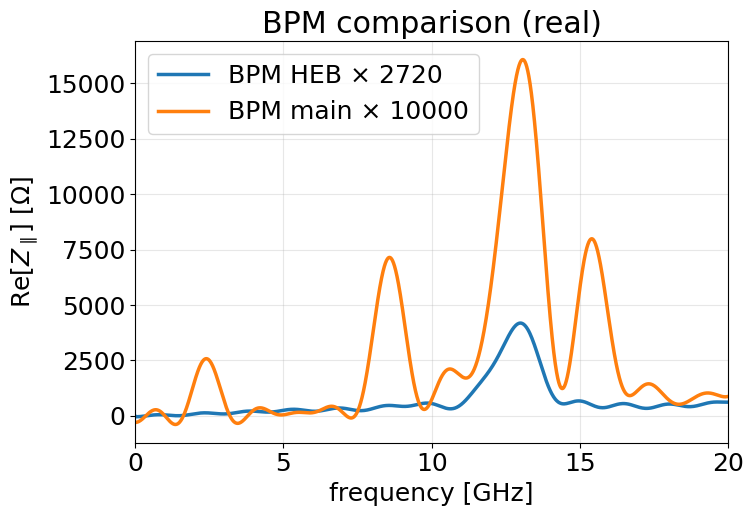

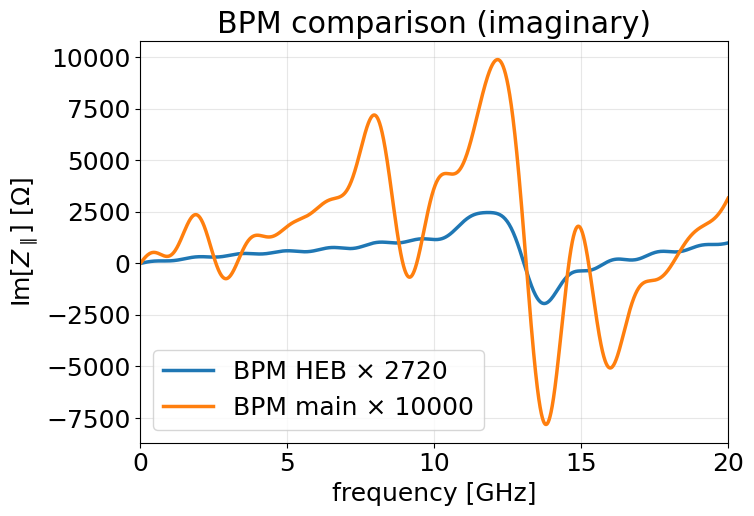

At 20 GHz:
HEB BPM (×10000) = (621.7092610000001+996.3509652307691j)
Collider BPM     = (880.4083+3165.64j)


In [17]:
# =========================================================
# NEW CELL: BPM comparison
#   - Z_bpm_long.txt   : HEB (needs ×10000)
#   - Z_bpm_long0.txt  : collider (already ×10000)
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"
bpm_dir = os.path.join(repo_data, "bpm")

# heb_file = os.path.join(bpm_dir, "Z_bpm_long.txt")
heb_file = os.path.join(bpm_dir, "Z_bpm_long_3mm.txt")
collider_file = os.path.join(bpm_dir, "Z_bpm_long0.txt")

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000

# ---------------------------------------------------------
# Helper: read impedance file
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# Read files
# ---------------------------------------------------------
freq_heb, Z_heb = read_impedance_file_ghz(heb_file)
freq_col, Z_col = read_impedance_file_ghz(collider_file)

# ---------------------------------------------------------
# IMPORTANT: scale HEB only
# ---------------------------------------------------------
Z_heb = 2720 * Z_heb #10000 * Z_heb

# ---------------------------------------------------------
# Common frequency grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Z_heb_i = interp_complex(freq_heb, Z_heb, f_common)
Z_col_i = interp_complex(freq_col, Z_col, f_common)

# ---------------------------------------------------------
# Real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.real, linewidth=2.5,
         label='BPM HEB × 2720')
plt.plot(f_common/1e9, Z_col_i.real, linewidth=2.5,
         label='BPM main × 10000')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (real)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.imag, linewidth=2.5,
         label='BPM HEB × 2720')
plt.plot(f_common/1e9, Z_col_i.imag, linewidth=2.5,
         label='BPM main × 10000')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (imaginary)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Optional summary at 20 GHz
# ---------------------------------------------------------
print("At 20 GHz:")
print(f"HEB BPM (×10000) = {Z_heb_i[-1]}")
print(f"Collider BPM     = {Z_col_i[-1]}")

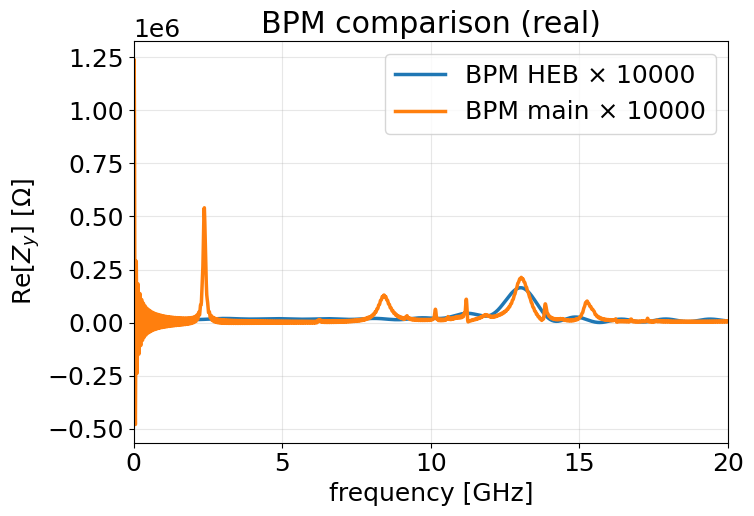

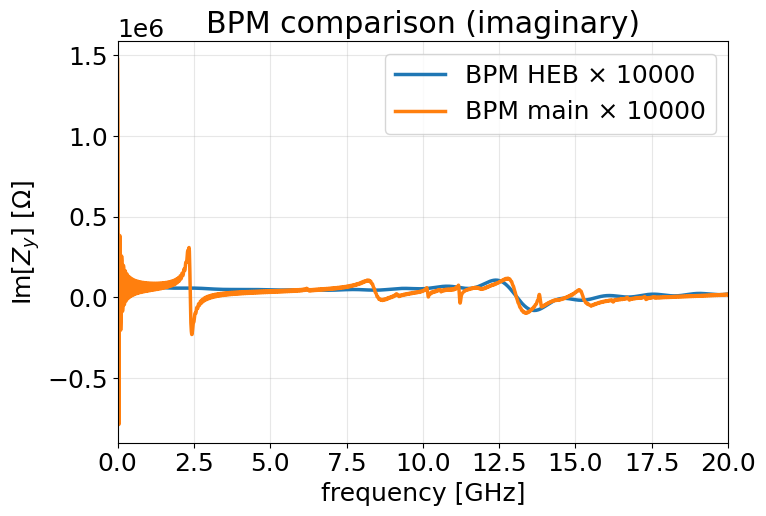

At 20 GHz:
HEB BPM (×10000) = (7282.642346153846+21429.06581730769j)
Collider BPM     = (8389.449+17158.13j)


In [34]:
# =========================================================
# NEW CELL: BPM comparison
#   - Z_bpm_long.txt   : HEB (needs ×10000)
#   - Z_bpm_long0.txt  : collider (already ×10000)
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"
bpm_dir = os.path.join(repo_data, "bpm")

# heb_file = os.path.join(bpm_dir, "Z_bpm_long.txt")
heb_file = os.path.join(bpm_dir, "Z_bpm_trans_3mm.txt")
collider_file = os.path.join(bpm_dir, "Z_bpm_trans01.txt")

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000

# ---------------------------------------------------------
# Helper: read impedance file
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# Read files
# ---------------------------------------------------------
freq_heb, Z_heb = read_impedance_file_ghz(heb_file)
freq_col, Z_col = read_impedance_file_ghz(collider_file)

# ---------------------------------------------------------
# IMPORTANT: scale HEB only
# ---------------------------------------------------------
# Z_heb = 2720 * Z_heb #10000 * Z_heb
Z_heb = 10000 * Z_heb

# ---------------------------------------------------------
# Common frequency grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Z_heb_i = interp_complex(freq_heb, Z_heb, f_common)
Z_col_i = interp_complex(freq_col, Z_col, f_common)

# ---------------------------------------------------------
# Real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.real, linewidth=2.5,
         label='BPM HEB × 10000')
plt.plot(f_common/1e9, Z_col_i.real, linewidth=2.5,
         label='BPM main × 10000')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_y$] [$\Omega$]')
plt.title('BPM comparison (real)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.imag, linewidth=2.5,
         label='BPM HEB × 10000')
plt.plot(f_common/1e9, Z_col_i.imag, linewidth=2.5,
         label='BPM main × 10000')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_y$] [$\Omega$]')
plt.title('BPM comparison (imaginary)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Optional summary at 20 GHz
# ---------------------------------------------------------
print("At 20 GHz:")
print(f"HEB BPM (×10000) = {Z_heb_i[-1]}")
print(f"Collider BPM     = {Z_col_i[-1]}")

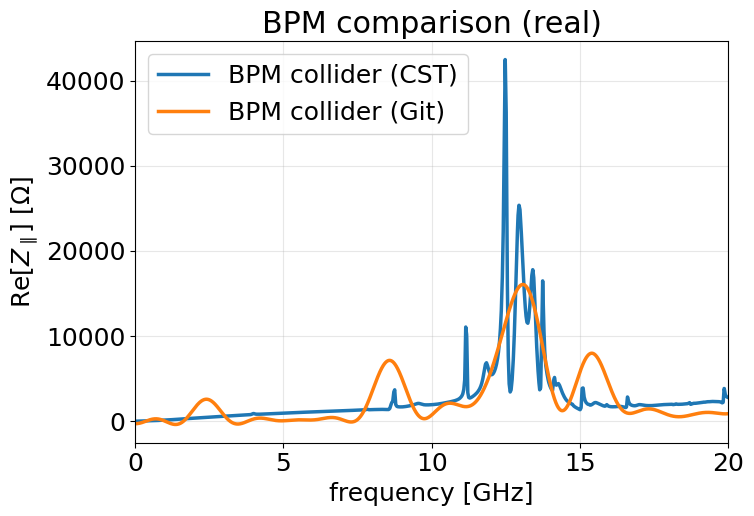

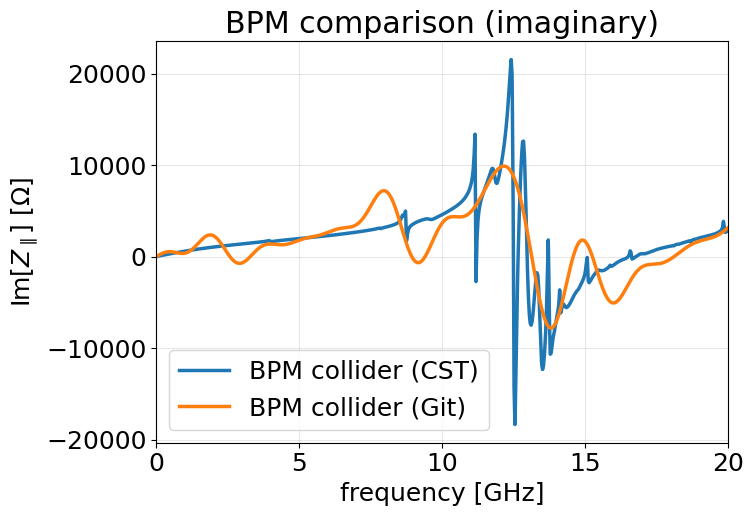

At 20 GHz:
Collider BPM (raw) = (2779.3243125+2838.866875j)
Collider BPM (smooth) = (880.4083+3165.64j)


In [67]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"
bpm_dir = os.path.join(repo_data, "bpm")

heb_file = os.path.join(bpm_dir, "Z_bpm_long_collider.txt")
collider_file = os.path.join(bpm_dir, "Z_bpm_long0.txt")

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000

# ---------------------------------------------------------
# Helper: read impedance file
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# Read files
# ---------------------------------------------------------
freq_heb, Z_heb = read_impedance_file_ghz(heb_file)
freq_col, Z_col = read_impedance_file_ghz(collider_file)

# ---------------------------------------------------------
# IMPORTANT: scale HEB only
# ---------------------------------------------------------
Z_heb = 10000 * Z_heb

# ---------------------------------------------------------
# Common frequency grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Z_heb_i = interp_complex(freq_heb, Z_heb, f_common)
Z_col_i = interp_complex(freq_col, Z_col, f_common)

# ---------------------------------------------------------
# Real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.real, linewidth=2.5,
         label='BPM collider (CST)')
plt.plot(f_common/1e9, Z_col_i.real, linewidth=2.5,
         label='BPM collider (Git)')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (real)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.imag, linewidth=2.5,
         label='BPM collider (CST)')
plt.plot(f_common/1e9, Z_col_i.imag, linewidth=2.5,
         label='BPM collider (Git)')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (imaginary)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Optional summary at 20 GHz
# ---------------------------------------------------------
print("At 20 GHz:")
print(f"Collider BPM (raw) = {Z_heb_i[-1]}")
print(f"Collider BPM (smooth) = {Z_col_i[-1]}")

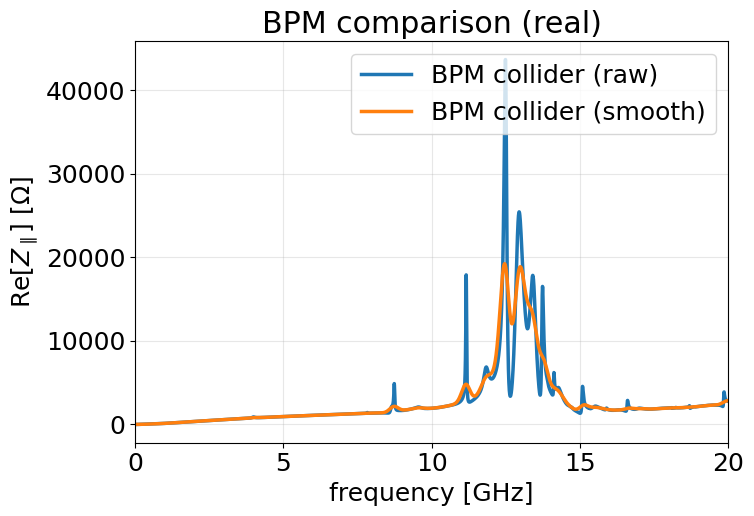

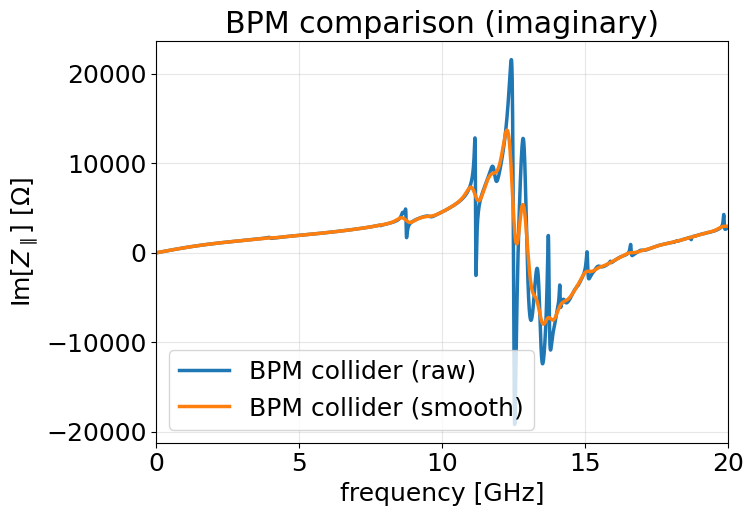

At 20 GHz:
Collider BPM (raw) = (2773.409864864865+2837.557189189189j)
Collider BPM (smooth) = (2866.140837837838+2984.555972972973j)


In [51]:
#test #2

import os
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# File paths
# ---------------------------------------------------------
repo_data = "/home/kim/pywit/pywit/fcc_ee_booster_pywit_model/fcc_ee_booster_pywit_model/data"
bpm_dir = os.path.join(repo_data, "bpm")

heb_file = os.path.join(bpm_dir, "Z_bpm_long_raw_collider.txt")
collider_file = os.path.join(bpm_dir, "Z_bpm_long_smooth_collider.txt")

# ---------------------------------------------------------
# Plot range
# ---------------------------------------------------------
f_plot_max = 20e9   # 20 GHz
n_interp = 4000

# ---------------------------------------------------------
# Helper: read impedance file
# ---------------------------------------------------------
def read_impedance_file_ghz(filepath):
    data = np.loadtxt(filepath, comments="#")
    f_hz = data[:, 0] * 1e9
    Z = data[:, 1] + 1j * data[:, 2]
    return f_hz, Z

# ---------------------------------------------------------
# Helper: interpolate complex impedance
# ---------------------------------------------------------
def interp_complex(f_src, Z_src, f_dst):
    re_part = np.interp(f_dst, f_src, Z_src.real, left=0.0, right=0.0)
    im_part = np.interp(f_dst, f_src, Z_src.imag, left=0.0, right=0.0)
    return re_part + 1j * im_part

# ---------------------------------------------------------
# Read files
# ---------------------------------------------------------
freq_heb, Z_heb = read_impedance_file_ghz(heb_file)
freq_col, Z_col = read_impedance_file_ghz(collider_file)

# ---------------------------------------------------------
# IMPORTANT: scale HEB only
# ---------------------------------------------------------
Z_heb = 10000 * Z_heb
Z_col = 10000 * Z_col

# ---------------------------------------------------------
# Common frequency grid
# ---------------------------------------------------------
f_common = np.linspace(0.0, f_plot_max, n_interp)

Z_heb_i = interp_complex(freq_heb, Z_heb, f_common)
Z_col_i = interp_complex(freq_col, Z_col, f_common)

# ---------------------------------------------------------
# Real part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.real, linewidth=2.5,
         label='BPM collider (raw)')
plt.plot(f_common/1e9, Z_col_i.real, linewidth=2.5,
         label='BPM collider (smooth)')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Re[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (real)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Imaginary part
# ---------------------------------------------------------
plt.figure(figsize=(8, 5.5))
plt.plot(f_common/1e9, Z_heb_i.imag, linewidth=2.5,
         label='BPM collider (raw)')
plt.plot(f_common/1e9, Z_col_i.imag, linewidth=2.5,
         label='BPM collider (smooth)')

plt.xlabel('frequency [GHz]')
plt.ylabel(r'Im[$Z_\parallel$] [$\Omega$]')
plt.title('BPM comparison (imaginary)')
plt.xlim(0, 20)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Optional summary at 20 GHz
# ---------------------------------------------------------
print("At 20 GHz:")
print(f"Collider BPM (raw) = {Z_heb_i[-1]}")
print(f"Collider BPM (smooth) = {Z_col_i[-1]}")

### Tests for different NEG thicknesses

Building models...
IW2D elements: ['pipe_section_1']
The computation of 'pipe_section_1' has already been performed with the exact given parameters. These results will be used to generate the element.
IW2D elements: ['pipe_section_1']
The computation of 'pipe_section_1' has already been performed with the exact given parameters. These results will be used to generate the element.
IW2D elements: ['pipe_section_1']
The computation of 'pipe_section_1' has already been performed with the exact given parameters. These results will be used to generate the element.

Lattice average beta:
  100 nm: <beta_x>=48.63565814525053, <beta_y>=49.56505593731157
  150 nm: <beta_x>=48.63565814525053, <beta_y>=49.56505593731157
  200 nm: <beta_x>=48.63565814525053, <beta_y>=49.56505593731157

Computing impedances...


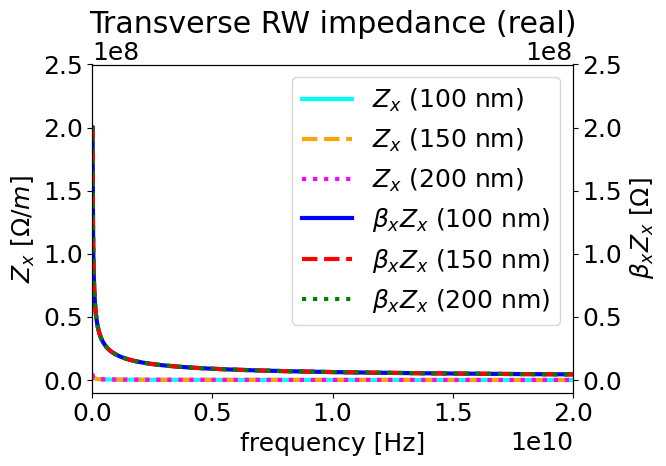

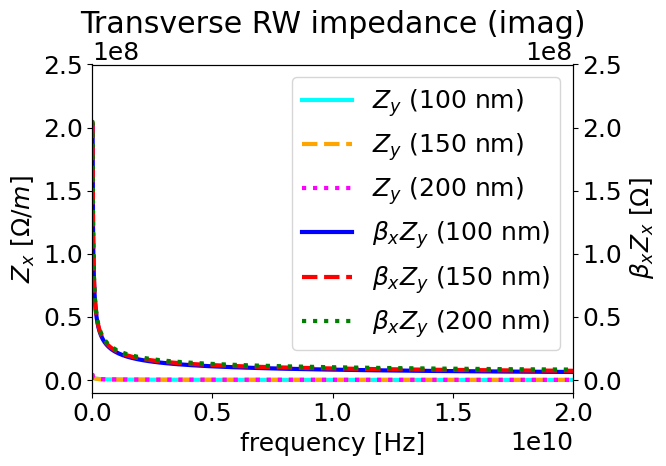

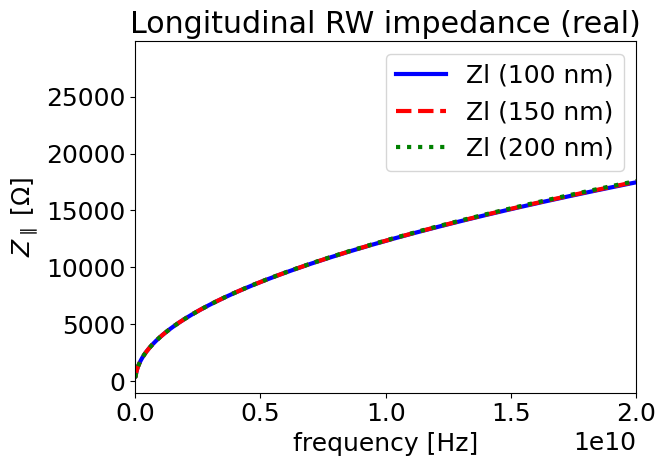

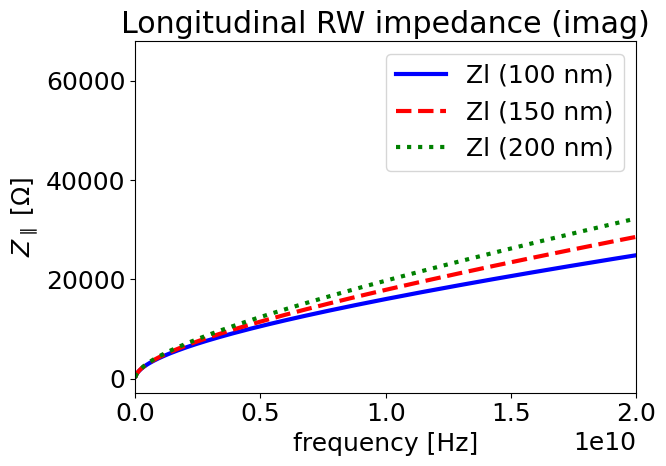

In [22]:
#%matplotlib ipympl

def compute_impedance(model):

    fmin, fmax = 1e-1, 1e13
    n_points = 10**3

    freq = None

    Zx_C = None
    Zy_C = None
    Zz_C = None

    Zx_beta = None
    Zy_beta = None

    for elem in model.elements:

        comp_x = elem.get_component('x1000')
        f, Zx_elem = comp_x.impedance_to_array(
            n_points, fmin, fmax, precision_factor=0.1
        )

        comp_y = elem.get_component('y0100')
        _, Zy_elem = comp_y.impedance_to_array(
            n_points, fmin, fmax, precision_factor=0.1
        )

        comp_z = elem.get_component('z0000')
        _, Zz_elem = comp_z.impedance_to_array(
            n_points, fmin, fmax, precision_factor=0.1
        )

        # Initialize arrays once
        if Zx_C is None:
            Zx_C = np.zeros_like(Zx_elem)
            Zy_C = np.zeros_like(Zy_elem)
            Zz_C = np.zeros_like(Zz_elem)

            Zx_beta = np.zeros_like(Zx_elem)
            Zy_beta = np.zeros_like(Zy_elem)

            freq = f

        # Local element length
        L_elem = getattr(elem, "length", 1.0)

        # Length-weighted impedance
        Zx_C += L * Zx_elem
        Zy_C += L * Zy_elem
        Zz_C += L * Zz_elem

        # Beta-weighted impedance (lattice optics)
        Zx_beta += elem.beta_x * L * Zx_elem
        Zy_beta += elem.beta_y * L * Zy_elem

    return freq, Zx_C, Zy_C, Zz_C, Zx_beta, Zy_beta


# yaml files (3 cases)
yaml_100 = Path.home() / "pywit/config/iw2d_inputs_neg100nm.yaml"
yaml_150 = Path.home() / "pywit/config/iw2d_inputs_neg150nm.yaml"
yaml_200 = Path.home() / "pywit/config/iw2d_inputs_neg200nm.yaml"

# Build models
print("Building models...")

model_100 = HEBModel(
    energy=45.6e9,
    optics_filename="heb_ring_z",
    yaml_file=yaml_100
)

model_150 = HEBModel(
    energy=45.6e9,
    optics_filename="heb_ring_z",
    yaml_file=yaml_150
)

model_200 = HEBModel(
    energy=45.6e9,
    optics_filename="heb_ring_z",
    yaml_file=yaml_200
)

# Print beta info
print("\nLattice average beta:")
print(f"  100 nm: <beta_x>={model_100.beta_x_avg}, <beta_y>={model_100.beta_y_avg}")
print(f"  150 nm: <beta_x>={model_150.beta_x_avg}, <beta_y>={model_150.beta_y_avg}")
print(f"  200 nm: <beta_x>={model_200.beta_x_avg}, <beta_y>={model_200.beta_y_avg}")

# Compute impedances
print("\nComputing impedances...")

freq_100, Zx100_C, Zy100_C, Zz100_C, Zx100_beta, Zy100_beta = compute_impedance(model_100)
freq_150, Zx150_C, Zy150_C, Zz150_C, Zx150_beta, Zy150_beta = compute_impedance(model_150)
freq_200, Zx200_C, Zy200_C, Zz200_C, Zx200_beta, Zy200_beta = compute_impedance(model_200)


# Plot settings
plt.close('all')

fntsz = 18
mpl.rcParams.update({
    'font.size': fntsz,
    'xtick.labelsize': fntsz,
    'ytick.labelsize': fntsz
})

# Transverse (real)
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(freq_100, Zx100_C.real, '-', color='cyan', linewidth=3, label=r'$Z_x$ (100 nm)')
ax1.plot(freq_150, Zx150_C.real, '--', color='orange', linewidth=3, label=r'$Z_x$ (150 nm)')
ax1.plot(freq_200, Zx200_C.real, ':', color='magenta', linewidth=3, label=r'$Z_x$ (200 nm)')
ax1.set_xlabel('frequency [Hz]')
ax1.set_ylabel(r'$Z_x$ [$\Omega/m$]')
ax1.set_xlim(0, 2e10)
ax1.set_ylim(-0.1e8, 2.5e8)
ax2 = ax1.twinx()
ax2.plot(freq_100, Zx100_beta.real, '-', color='blue', linewidth=3, label=r'$\beta_x Z_x$ (100 nm)')
ax2.plot(freq_150, Zx150_beta.real, '--', color='red', linewidth=3, label=r'$\beta_x Z_x$ (150 nm)')
ax2.plot(freq_200, Zx200_beta.real, ':', color='green', linewidth=3, label=r'$\beta_x Z_x$ (200 nm)')
ax2.set_ylim(-0.1e8, 2.5e8)
ax2.set_ylabel(r'$\beta_x Z_x$ [$\Omega$]')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
plt.title("Transverse RW impedance (real)")
plt.tight_layout()
plt.show()

# Transverse (imag)
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(freq_100, Zx100_C.imag, '-', color='cyan', linewidth=3, label=r'$Z_y$ (100 nm)')
ax1.plot(freq_150, Zx150_C.imag, '--', color='orange', linewidth=3, label=r'$Z_y$ (150 nm)')
ax1.plot(freq_200, Zx200_C.imag, ':', color='magenta', linewidth=3, label=r'$Z_y$ (200 nm)')
ax1.set_xlabel('frequency [Hz]')
ax1.set_ylabel(r'$Z_x$ [$\Omega/m$]')
ax1.set_xlim(0, 2e10)
ax1.set_ylim(-0.1e8, 2.5e8)
ax2 = ax1.twinx()
ax2.plot(freq_100, Zx100_beta.imag, '-', color='blue', linewidth=3, label=r'$\beta_x Z_y$ (100 nm)')
ax2.plot(freq_150, Zx150_beta.imag, '--', color='red', linewidth=3, label=r'$\beta_x Z_y$ (150 nm)')
ax2.plot(freq_200, Zx200_beta.imag, ':', color='green', linewidth=3, label=r'$\beta_x Z_y$ (200 nm)')
ax2.set_ylim(-0.1e8, 2.5e8)
ax2.set_ylabel(r'$\beta_x Z_x$ [$\Omega$]')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)
plt.title("Transverse RW impedance (imag)")
plt.tight_layout()
plt.show()

# Longitudinal (real)
plt.figure(figsize=(7,5))
plt.plot(freq_100, Zz100_C.real, '-', color='blue', linewidth=3, label='Zl (100 nm)')
plt.plot(freq_150, Zz150_C.real, '--', color='red', linewidth=3, label='Zl (150 nm)')
plt.plot(freq_200, Zz200_C.real, ':', color='green', linewidth=3, label='Zl (200 nm)')
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$Z_\parallel$ [$\Omega$]')
plt.title("Longitudinal RW impedance (real)")
plt.legend()
plt.xlim(0, 2e10)
plt.tight_layout()
plt.show()

# Longitudinal (imag)
plt.figure(figsize=(7,5))
plt.plot(freq_100, Zz100_C.imag, '-', color='blue', linewidth=3, label='Zl (100 nm)')
plt.plot(freq_150, Zz150_C.imag, '--', color='red', linewidth=3, label='Zl (150 nm)')
plt.plot(freq_200, Zz200_C.imag, ':', color='green', linewidth=3, label='Zl (200 nm)')
plt.xlabel('frequency [Hz]')
plt.ylabel(r'$Z_\parallel$ [$\Omega$]')
plt.title("Longitudinal RW impedance (imag)")
plt.legend()
plt.xlim(0, 2e10)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import json

base_json_file = data_folder / "elliptic_elements" / "FCC_ee_vz_elliptic_elements_settings_neg_150nm.json"

neg_thicknesses = [1.5e-7, 3e-7, 5e-7]  # NEG thickness in meters
results = []

# Folder to save plots
folder_path = os.path.join(os.getcwd(), 'Plots')
os.makedirs(folder_path, exist_ok=True)

# -------------------------------
# Loop over NEG thicknesses
# -------------------------------
for t in neg_thicknesses:
    print(f"\n Running FCCEEModel with NEG thickness = {t*1e9:.1f} nm")

    # Load base JSON
    with open(base_json_file, "r") as f:
        elliptic_settings = json.load(f)

    # Modify NEG thickness
    elliptic_settings["pipe_section_1"]["layers"][0]["thickness"] = t

    # Save temporary JSON
    tmp_json_file = data_folder / f"elliptic_elements/tmp_neg_{int(t*1e9)}nm.json"
    with open(tmp_json_file, "w") as f:
        json.dump(elliptic_settings, f, indent=2)

    # -------------------------------
    # Call FCCEEModel
    # -------------------------------
    model = HEBModel(
        energy=45.6e9,
        optics_filename=optics_settings_filename,
        elliptic_elements_settings_filename=tmp_json_file,
        f_params_dict=f_params_dict,
        z_params_dict=z_params_dict,
        additional_f_params=additional_f_params,
        compute_wake=False,
        beta_smooth_elements=['pipe_section_1']
    )

    total_model = model.elements[0]  # beam pipe

    # discretize and cast points to int
    disc_xdip = total_model.get_component('x1000').discretize(int(1e3), 1, 1e-1, 1e13, freq_precision_factor=0.1)[0]
    disc_ydip = total_model.get_component('y0100').discretize(int(1e3), 1, 1e-1, 1e13, freq_precision_factor=0.1)[0]
    disc_zlong = total_model.get_component('z0000').discretize(int(1e3), 1, 1e-1, 1e13, freq_precision_factor=0.1)[0]

    # Store results for plotting
    results.append({
        "neg_thickness_m": t,
        "freq": disc_xdip[0],   # same for all
        "Zx": disc_xdip[1],
        "Zy": disc_ydip[1],
        "Zlong": disc_zlong[1]
    })



In [ ]:
# -------------------------------
# Plotting
# -------------------------------
plt.figure(figsize=(7,5))
for res in results:
    t_nm = res['neg_thickness_m']*1e9
    plt.loglog(res['freq'], np.real(res['Zx']), label=f'Zx, {t_nm:.0f} nm')
    plt.loglog(res['freq'], np.real(res['Zy']), '--', label=f'Zy, {t_nm:.0f} nm')

plt.xlabel('Frequency [Hz]')
plt.ylabel('Dipolar impedance [Ohm/m]')
plt.title('Impedance vs NEG thickness')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))
for res in results:
    t_nm = res['neg_thickness_m']*1e9
    plt.loglog(res['freq'], np.imag(res['Zx']), label=f'Zx, {t_nm:.0f} nm')
    plt.loglog(res['freq'], np.imag(res['Zy']), '--', label=f'Zy, {t_nm:.0f} nm')

plt.xlabel('Frequency [Hz]')
plt.ylabel('Dipolar impedance [Ohm/m]')
plt.title('Impedance vs NEG thickness')
plt.legend()
plt.grid(True, which='both', ls='--')
plt.tight_layout()
plt.show()